# EV2 - Proyecto de Mineria de Datos

*Integrantes* :<b>Flavio Henriquez / Bastian Bianchi / Martin Pero</b> <br>
*Docente* : <b>Italo Bonnet</b>  <br>
*Asignatura* : <b>Mineria de datos BIY7121-005D</b><br>
*Grupo* : <b>4</b>

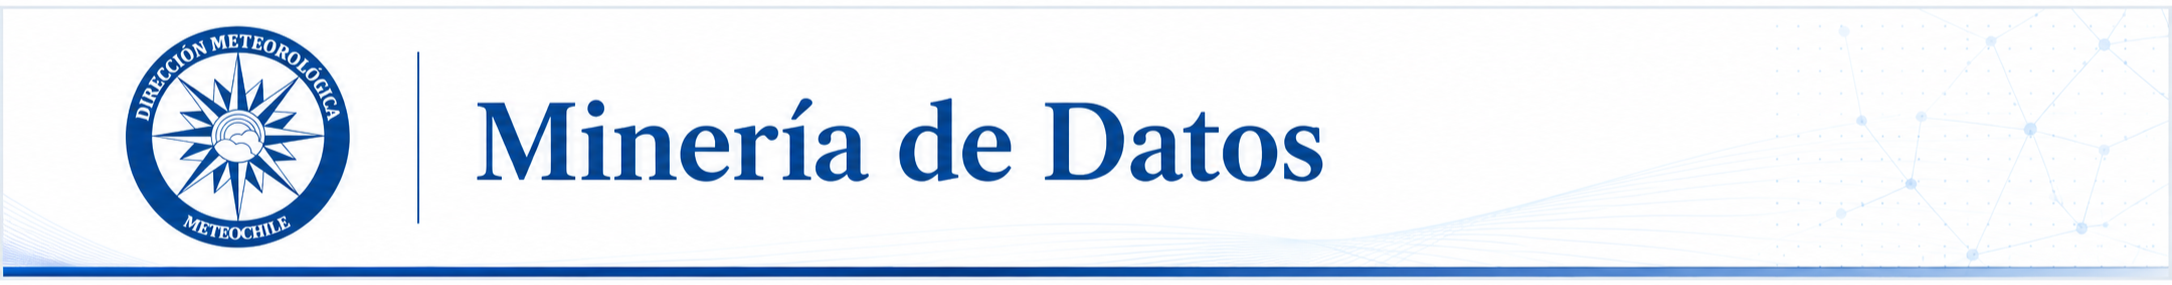

## Analisis de precipitaciones, temperaturas y estaciones meteorologicas en Chile

**Asignatura:** BIY7121 - Mineria de Datos  
**Metodologia:** CRISP-DM  
**Dataset base:** precipitaciones, temperaturas y estaciones meteorologicas de Chile  
**Periodo de analisis:** 2021-2025

Este notebook desarrolla un proyecto de mineria de datos aplicado a informacion meteorologica nacional. El objetivo es analizar el comportamiento de las precipitaciones y temperaturas registradas por estaciones meteorologicas, detectar patrones climaticos relevantes y construir modelos predictivos y descriptivos que apoyen la toma de decisiones.

## Estructura del notebook

La estructura del trabajo sigue la pauta entregada en `estructura.txt` y se mantiene alineada con CRISP-DM:

1. **Entendimiento del Negocio**: contexto, datos relevantes, hipotesis, KPIs y problema de negocio.
2. **Entendimiento de Datos**: tipos de variables, nulos, outliers, transformaciones exploratorias, estadisticos, correlaciones y patrones.
3. **Transformacion / Preparacion de Datos**: preparacion final para modelos, imputacion, encoding, escalamiento y dataset para cluster.
4. **Modelamiento**: regresion, clasificacion y cluster, separando seleccion de variables, parametros, aplicacion y metricas.
5. **Evaluacion**: se desarrollara despues de cerrar modelamiento.
6. **Deploy / Despliegue**: se desarrollara al final, despues de evaluar resultados.

En esta version se conserva completo el avance hasta la Fase 3 y se reinicia la Fase 4 para construirla paso a paso.


### Dependencias del entorno

El proyecto usa librerias estandar de ciencia de datos (numpy, pandas, matplotlib, scikit-learn, seaborn). Solo `kneed` (deteccion automatica del codo en K-Means) puede no estar preinstalada en entornos como Google Colab, por lo que se asegura a continuacion. En un entorno que ya la tenga, la linea no produce cambios.

In [1]:
# Asegura la unica dependencia no estandar (kneed). Silencioso; si ya esta instalada, no hace nada.
%pip install -q kneed

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import csv
import json
import re
import subprocess
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import LinearSVR, LinearSVC, SVR, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score, classification_report,
)

try:
    from kneed import KneeLocator
    KNEED_DISPONIBLE = True
except ImportError:
    KNEED_DISPONIBLE = False

try:
    import seaborn as sns
    SEABORN_DISPONIBLE = True
except ImportError:
    SEABORN_DISPONIBLE = False


In [3]:
# Toda la carga de datos se hace en memoria desde las raw URLs de GitHub.
# No se descarga ningun archivo a disco: cada lectura pide el dato directamente al repositorio.
RAW_BASE = 'https://raw.githubusercontent.com/4mnesia/DataMining_Datos/refs/heads/main'

def descargar_texto(url, encoding='utf-8', errores='strict'):
    with urllib.request.urlopen(url) as respuesta:
        return respuesta.read().decode(encoding, errors=errores)

def descargar_bytes(url):
    with urllib.request.urlopen(url) as respuesta:
        return respuesta.read()

**Analisis de la fuente de datos:**

Los datos se consumen directamente desde GitHub mediante raw URLs, en memoria y sin copia local. El proyecto combina **dos datasets**:

1. **Dataset meteorologico de estaciones de Chile (DMC)**: precipitacion y temperatura diaria por estacion. Es la fuente principal (target de clasificacion de lluvia y de regresion de temperatura).
2. **Dataset atmosferico de reanalisis de la NASA (NASA POWER)**: humedad, viento, radiacion, nubosidad y presion por estacion y dia. Aporta el **estado atmosferico** que mejora la regresion.

El dataset atmosferico se obtuvo del proyecto **NASA POWER** (Prediction Of Worldwide Energy Resources, NASA Langley Research Center):

- Portal oficial: https://power.larc.nasa.gov/
- API usada (datos diarios por punto): https://power.larc.nasa.gov/api/temporal/daily/point

Se consulto por coordenadas de cada estacion (latitud/longitud) para el periodo 2021-2025, y el resultado se consolido en `atmosfera_diario.csv`. Se complementan con metadata de estaciones, el raster Koppen-Geiger y el mapa de Chile. Todo es reproducible en cualquier equipo con conexion.

In [4]:
PRECIP_TEMP_CSV = f'{RAW_BASE}/dataset_precipitaciones_temperaturas_chile.csv'
PRECIP_CSV = f'{RAW_BASE}/dataset_precipitaciones_diarias_chile_COMPLETO.csv'
STATIONS_JSON = f'{RAW_BASE}/getEstacionesRedEma.json'
CHILE_GEOJSON = f'{RAW_BASE}/chile_country.geojson'
KOPPEN_TIF = 'https://raw.githubusercontent.com/4mnesia/DataMining_Datos/main/koppen_geiger_1991_2020_1km.tif'
KOPPEN_LEGEND = f'{RAW_BASE}/legend.txt'
ATMOSFERA_CSV = f'{RAW_BASE}/atmosfera_diario.csv'  # reanalisis NASA POWER

fuentes = pd.DataFrame([
    {'fuente': 'Dataset meteorologico: precipitaciones + temperaturas', 'origen': 'Estaciones DMC (Chile)', 'url': PRECIP_TEMP_CSV},
    {'fuente': 'Dataset atmosferico diario', 'origen': 'NASA POWER (reanalisis)', 'url': ATMOSFERA_CSV},
    {'fuente': 'Precipitaciones diarias (respaldo)', 'origen': 'Estaciones DMC (Chile)', 'url': PRECIP_CSV},
    {'fuente': 'Metadata de estaciones', 'origen': 'Red EMA / DMC', 'url': STATIONS_JSON},
    {'fuente': 'Zonas climaticas Koppen-Geiger 1km', 'origen': 'Raster climatico 1991-2020', 'url': KOPPEN_TIF},
    {'fuente': 'Mapa de Chile (GeoJSON)', 'origen': 'Limites geograficos', 'url': CHILE_GEOJSON},
])
display(fuentes)

,fuente,origen,url
0,Dataset meteorologico: precipitaciones + tempe...,Estaciones DMC (Chile),https://raw.githubusercontent.com/4mnesia/Data...
1,Dataset atmosferico diario,NASA POWER (reanalisis),https://raw.githubusercontent.com/4mnesia/Data...
2,Precipitaciones diarias (respaldo),Estaciones DMC (Chile),https://raw.githubusercontent.com/4mnesia/Data...
3,Metadata de estaciones,Red EMA / DMC,https://raw.githubusercontent.com/4mnesia/Data...
4,Zonas climaticas Koppen-Geiger 1km,Raster climatico 1991-2020,https://raw.githubusercontent.com/4mnesia/Data...
5,Mapa de Chile (GeoJSON),Limites geograficos,https://raw.githubusercontent.com/4mnesia/Data...


**Analisis de disponibilidad de las fuentes:**

Todas las fuentes se consumen **en memoria** desde las raw URLs de GitHub: el notebook **no descarga archivos al disco ni clona** ningun repositorio (ya no se usa la carpeta `.data`). Asi queda reproducible en cualquier equipo con conexion -incluido Google Colab- sin pasos previos de preparacion de datos.

# 1. Entendimiento del Negocio

La fase de entendimiento del negocio define el contexto del problema, los datos disponibles, las hipotesis iniciales, los indicadores clave y el problema de mineria de datos que se abordara. Esta fase es fundamental en CRISP-DM, porque orienta las decisiones posteriores de limpieza, transformacion, modelamiento y evaluacion.

## 1.1 Contexto

Chile presenta una geografia extensa y diversa, con diferencias climaticas importantes entre el norte, centro, sur, zonas costeras, valles, precordillera y cordillera. Esta diversidad hace que el comportamiento de las precipitaciones y temperaturas varie de forma significativa segun ubicacion, altura, estacion del anio y zona geografica.

El analisis de datos meteorologicos permite transformar registros historicos en conocimiento util para la toma de decisiones. En particular, la informacion de precipitaciones, temperaturas y estaciones puede apoyar procesos relacionados con monitoreo climatico, gestion territorial, planificacion agricola, prevencion de riesgos, gestion hidrica y deteccion de eventos extremos.

Desde la perspectiva de mineria de datos, el problema no consiste solo en describir registros climaticos, sino en descubrir patrones, relaciones y comportamientos que no son evidentes al observar los datos de forma aislada. Por ello, el proyecto se abordara mediante una combinacion de analisis exploratorio, limpieza de datos, transformacion de variables, modelos predictivos y modelos descriptivos.

## 1.2 Datos relevantes

Los datos se leen **en memoria** desde las **raw URLs** del repositorio publico `4mnesia/DataMining_Datos` en GitHub. **No se descarga ni se clona nada** al disco (no existe carpeta `.data`): cada lectura pide el archivo directamente a su URL, lo que mantiene el proyecto reproducible en cualquier equipo con conexion. Se combinan dos datasets principales mas recursos de apoyo:

| Fuente | Contenido | Uso en el proyecto |
|---|---|---|
| Dataset DMC: precipitaciones + temperaturas | Precipitacion, temperatura (max/min/media), fecha, estacion y variables geograficas | Fuente principal: target de regresion (`temp_media`) y de clasificacion (lluvia) |
| Dataset atmosferico (reanalisis NASA POWER) `atmosfera_diario.csv` | Humedad, viento, radiacion, nubosidad, presion por estacion y dia | Predictores atmosfericos del dia, que mejoran la regresion |
| Metadata de estaciones `getEstacionesRedEma.json` | Codigo, nombre, region, zona, coordenadas, altura | Descripcion de las estaciones meteorologicas |
| Raster Koppen-Geiger `koppen_geiger_1991_2020_1km.tif` | Zona climatica oficial por coordenada | Contexto climatico y apoyo al clustering |
| Mapa de Chile `chile_country.geojson` | Poligono del pais | Visualizaciones geograficas |

> El dataset atmosferico proviene de **NASA POWER** (NASA Langley Research Center): portal https://power.larc.nasa.gov/ , API de datos diarios por punto https://power.larc.nasa.gov/api/temporal/daily/point

Resumen verificado del dataset principal:

| Caracteristica | Valor |
|---|---:|
| Registros | 187.876 |
| Periodo | 2021-01-01 a 2025-12-31 |
| Estaciones presentes | 109 |
| Regiones | 16 |
| Zonas geograficas | Cordillera, Litoral, PreCordillera, Secano Costero, Secano Interior, Valle |
| Filas con formato especial a corregir | 74.112 |
| Nulos en `agua_caida` | 9,08% |
| Nulos en temperatura (`temp_*`) | 11-12% |

Variables principales:

| Grupo | Variables | Descripcion |
|---|---|---|
| Temporales | `fecha`, `anio`, `mes`, `dia` | Estacionalidad y comportamiento por periodo. |
| Geograficas | `region`, `nombre_region`, `latitud`, `longitud`, `altura`, `zona_geografica` | Relacionan el clima con la ubicacion. |
| Estacion | `codigo_estacion`, `nombre_estacion` | Identifican el origen de cada registro. |
| Precipitacion | `agua_caida` | Lluvia diaria (objetivo de clasificacion). |
| Temperatura | `temp_max`, `temp_min`, `temp_media` | Comportamiento termico (`temp_media` es el objetivo de regresion). |
| Atmosfericas (reanalisis) | `humedad`, `viento`, `radiacion`, `nubosidad`, `presion` | Estado atmosferico del dia, predictoras de la regresion. |

El dataset principal presenta filas completas encerradas entre comillas, por lo que requiere una **carga controlada** antes del analisis (se resuelve en la Fase 2).

**Analisis de los datos relevantes:**

El dataset principal combina volumen temporal (5 anios), cobertura territorial (109 estaciones, 16 regiones) y variables climaticas y atmosfericas, lo que sostiene un objetivo predictivo y no solo descriptivo. La presencia de nulos moderados y de filas mal formateadas anticipa el trabajo de limpieza de la Fase 2.

## 1.3 Hipotesis y tesis consideradas

### Tesis general del proyecto

El comportamiento de las precipitaciones y temperaturas en Chile puede explicarse parcialmente mediante variables temporales, geograficas, termicas y atmosfericas. A partir de ellas es posible detectar patrones climaticos y construir modelos predictivos y descriptivos utiles.

### Hipotesis de trabajo

Se plantean **cuatro** hipotesis centradas en **patrones de los datos**, contrastables en la Fase 2 (Entendimiento de Datos). No se formulan como metricas de modelos: el rendimiento de la Fase 4 es un resultado, no una hipotesis.

| Hipotesis | Descripcion | Variables | Como se contrasta (Fase 2) |
|---|---|---|---|
| H1 | La precipitacion varia significativamente entre regiones y zonas geograficas. | `agua_caida`, `region`, `zona_geografica` | Boxplots y mapas por grupo. |
| H2 | La lluvia tiene un patron estacional marcado (mes / estacion del anio). | `agua_caida`, `mes` | Heatmap mes x macrozona y series por anio. |
| H3 | La temperatura media depende de la latitud, la altura y la zona geografica. | `temp_media`, `latitud`, `altura`, `zona_geografica` | Matriz de correlacion y mapas tematicos. |
| H4 | Las estaciones forman grupos climaticos diferenciables. | `agua_caida`, `temp_media`, `altura`, `latitud`, `longitud` | Exploracion de perfiles climaticos (base del clustering). |

Estas hipotesis guian la seleccion de variables y la construccion de nuevas caracteristicas en las fases siguientes.

## 1.4 KPIs relevantes

Los KPI traducen las variables disponibles en **indicadores medibles** que conectan el clima con decisiones de negocio (gestion hidrica, agricola y de riesgos) y dan una base objetiva para justificar los modelos.

| KPI | Formula o criterio | Utilidad |
|---|---|---|
| **Precipitacion acumulada** | Suma de `agua_caida` por estacion, region, zona o periodo | Identificar territorios con mayor volumen de lluvia. |
| **Precipitacion promedio diaria** | Promedio de `agua_caida` | Comparar el comportamiento normal entre estaciones o regiones. |
| **Porcentaje de dias con lluvia** | Dias con `agua_caida > 0` / total de dias | Medir la frecuencia de lluvia de forma comparable. |
| **Eventos de lluvia intensa** | Registros sobre umbral (p. ej. percentil 90 de dias con lluvia) | Detectar eventos relevantes para riesgo climatico. |
| **Temperatura media y rango termico** | `temp_media`, `temp_max - temp_min` | Caracterizar el regimen termico (objetivo de la regresion). |
| **Porcentaje de nulos** | `isna()` por variable | Vigilar la calidad de los datos. |

**Analisis de KPI:**

Los KPI conectan las variables disponibles con decisiones de negocio (precipitacion acumulada, lluvia intensa, temperatura, cobertura territorial) y dan una base medible para justificar los modelos posteriores.

## 1.5 Problema de negocio (Prediccion)

El problema de negocio es anticipar y comprender el comportamiento de precipitaciones y temperaturas en Chile usando informacion historica, geografica, temporal y atmosferica. Cada tecnica se aplica a la variable que mejor predice:

### Problema predictivo de regresion

Estimar la **temperatura media diaria** (`temp_media`) de cada estacion a partir de su ubicacion, la epoca del anio, el estado atmosferico del dia (segundo dataset de reanalisis) y la persistencia (temperatura del dia anterior). Se elige la temperatura como objetivo de regresion porque es una variable continua y predecible a escala diaria; la precipitacion diaria, en cambio, es caotica (su parte predecible es baja) y se aborda como clasificacion.

**Variable objetivo:** `temp_media` (grados C por dia y estacion).

### Problema predictivo de clasificacion

Clasificar a nivel diario si hay lluvia (`llueve`) o lluvia intensa (`lluvia_intensa`).

### Problema descriptivo de clustering

Segmentar estaciones por perfil climatico.

### Criterios de exito

- **Regresion (temperatura diaria):** `R2` alto (objetivo >= 0.7) y `RMSE` bajo en grados C.
- **Clasificacion (lluvia):** `F1` por encima del azar, priorizando `recall` en eventos intensos.
- **Cluster:** `silhouette` con grupos cohesivos.

## Cierre de Fase 1

La Fase 1 establece el marco formal del proyecto. Se definio el contexto, se verificaron las fuentes de datos disponibles, se formularon hipotesis, se establecieron KPI relevantes y se delimito el problema de negocio como un proyecto mixto de prediccion y descripcion climatica.

La siguiente fase corresponde al **Entendimiento de Datos**, donde se cargara el dataset, se corregira el formato especial de algunas filas, se identificaran tipos de variables, nulos, outliers, estadisticos basicos, correlaciones y primeros patrones observados.

# 2. Entendimiento de Datos

En esta fase se estudia la estructura real del dataset antes de tomar decisiones de limpieza profunda o modelamiento. El objetivo es conocer la calidad de los datos, identificar tipos de variables, nulos, outliers, distribuciones, correlaciones y primeros patrones climaticos.

La decision principal de esta fase es trabajar con el archivo `dataset_precipitaciones_temperaturas_chile.csv`, porque integra precipitaciones, temperaturas, estaciones y variables geograficas. El archivo de precipitaciones diarias se usara como respaldo si se requiere contrastar la variable `agua_caida`.


## 2.0 Carga controlada del dataset principal

Antes de analizar los datos se debe resolver un problema de formato detectado en el CSV principal: una parte de las filas viene encerrada completamente entre comillas. Si se carga el archivo directamente, esas filas quedan interpretadas como un solo campo y se distorsionan los tipos de datos, los nulos y los conteos de estaciones.

Por esta razon se construye una carga controlada. Esta carga no cambia los valores originales del dataset; solo corrige la lectura de filas completas entre comillas para que cada columna quede en su posicion correcta.


In [5]:
COLUMNAS_CLIMA = [
    'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
    'anio', 'mes', 'dia', 'agua_caida', 'fecha', 'nombre_estacion',
    'nombre_region', 'zona_geografica', 'temp_max', 'temp_min', 'temp_media'
]


In [6]:
def leer_filas_clima(url_csv):
    texto = descargar_texto(url_csv, encoding='utf-8-sig')
    lineas = texto.splitlines()

    filas = []
    filas_entre_comillas = 0
    filas_con_error = []

    for numero_linea, fila in enumerate(lineas[1:], start=2):  # se omite el encabezado
        if len(fila) >= 2 and fila[0] == '"' and fila[-1] == '"':
            filas_entre_comillas += 1
            fila = fila[1:-1].replace('""', '"')

        valores = next(csv.reader([fila]))
        if len(valores) == len(COLUMNAS_CLIMA):
            filas.append(valores)
        else:
            filas_con_error.append((numero_linea, len(valores)))

    return filas, filas_entre_comillas, filas_con_error

In [7]:
def corregir_texto_mojibake(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor)
    try:
        return valor.encode('latin1').decode('utf-8')
    except UnicodeError:
        return valor


def convertir_tipos_clima(filas):
    datos = pd.DataFrame(filas, columns=COLUMNAS_CLIMA)

    columnas_numericas = [
        'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
        'anio', 'mes', 'dia', 'agua_caida', 'temp_max', 'temp_min', 'temp_media'
    ]
    for columna in columnas_numericas:
        datos[columna] = pd.to_numeric(datos[columna], errors='coerce')

    datos['fecha'] = pd.to_datetime(datos['fecha'], errors='coerce')

    for columna in ['nombre_estacion', 'nombre_region', 'zona_geografica']:
        datos[columna] = datos[columna].apply(corregir_texto_mojibake).astype('string').str.strip()

    return datos


In [8]:
def cargar_dataset_clima(ruta_csv):
    filas, filas_entre_comillas, filas_con_error = leer_filas_clima(ruta_csv)
    datos = convertir_tipos_clima(filas)

    resumen = {
        'filas_cargadas': len(datos),
        'columnas_cargadas': datos.shape[1],
        'filas_entre_comillas_corregidas': filas_entre_comillas,
        'filas_con_error': len(filas_con_error),
    }

    return datos, resumen, filas_con_error


In [9]:
df, resumen_carga, filas_con_error = cargar_dataset_clima(PRECIP_TEMP_CSV)

display(pd.DataFrame([resumen_carga]))
display(df.head(3))


,filas_cargadas,columnas_cargadas,filas_entre_comillas_corregidas,filas_con_error
0,187876,16,74112,0


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica,temp_max,temp_min,temp_media
0,170001,15,4084,-17.595,-69.4775,2023,1,1,NaN,2023-01-01,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
1,170001,15,4084,-17.595,-69.4775,2023,1,2,NaN,2023-01-02,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
2,170001,15,4084,-17.595,-69.4775,2023,1,3,NaN,2023-01-03,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN


**Analisis de carga:**

La carga controlada permite trabajar con el dataset principal sin perder columnas ni registros. El punto mas importante es que las filas completas entre comillas no se eliminan: se corrige su lectura para conservar la informacion disponible. Esto es coherente con buenas practicas de preparacion de datos, porque primero se corrige el problema de estructura antes de evaluar nulos, outliers o patrones.


## 2.1 Identificar Tipos de variables/atributos

En mineria de datos es necesario distinguir entre variables numericas, categoricas, temporales e identificadores. Esta clasificacion define que analisis se puede hacer y que transformaciones seran necesarias antes del modelamiento.


In [10]:
# Tipos de cada variable y nulos, leidos en duro desde el df
tipos_variables = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2)
})
display(tipos_variables)

,tipo,nulos,pct_nulos
codigo_estacion,int64,0,0.00
region,int64,0,0.00
altura,int64,0,0.00
latitud,float64,0,0.00
longitud,float64,0,0.00
anio,int64,0,0.00
mes,int64,0,0.00
dia,int64,0,0.00
agua_caida,float64,17063,9.08
fecha,datetime64[us],0,0.00


**Analisis de tipos:**

El dataset combina variables climaticas, geograficas, temporales y categoricas. Para analisis estadistico y modelamiento, las variables numericas pueden usarse directamente despues de tratar nulos y outliers. Las variables categoricas como `nombre_region` y `zona_geografica` requeriran encoding en fases posteriores. La variable `codigo_estacion` identifica observaciones, pero no debe interpretarse como magnitud numerica.


### Cobertura temporal y territorial

Antes de analizar nulos o modelos, se revisa si los datos cubren adecuadamente el periodo y las regiones disponibles. Esta revision permite detectar concentraciones o vacios importantes en la captura de datos.


In [11]:
# Resumen general leido en duro desde el df
print('Registros:', len(df), '| Columnas:', df.shape[1])
print('Periodo:', df['fecha'].min().date(), 'a', df['fecha'].max().date())
print('Estaciones:', df['codigo_estacion'].nunique(), '| Regiones:', df['region'].nunique(), '| Zonas geograficas:', df['zona_geografica'].nunique())
print('Filas duplicadas:', int(df.duplicated().sum()))

Registros: 187876 | Columnas: 16
Periodo: 2021-01-01 a 2025-12-31
Estaciones: 109 | Regiones: 16 | Zonas geograficas: 6
Filas duplicadas: 0


**Analisis de cobertura:**

El dataset tiene una cobertura amplia en registros, anos, estaciones y regiones. Esta base es adecuada para comparar patrones territoriales y temporales, aunque los desbalances por region deben considerarse al interpretar modelos y graficos.

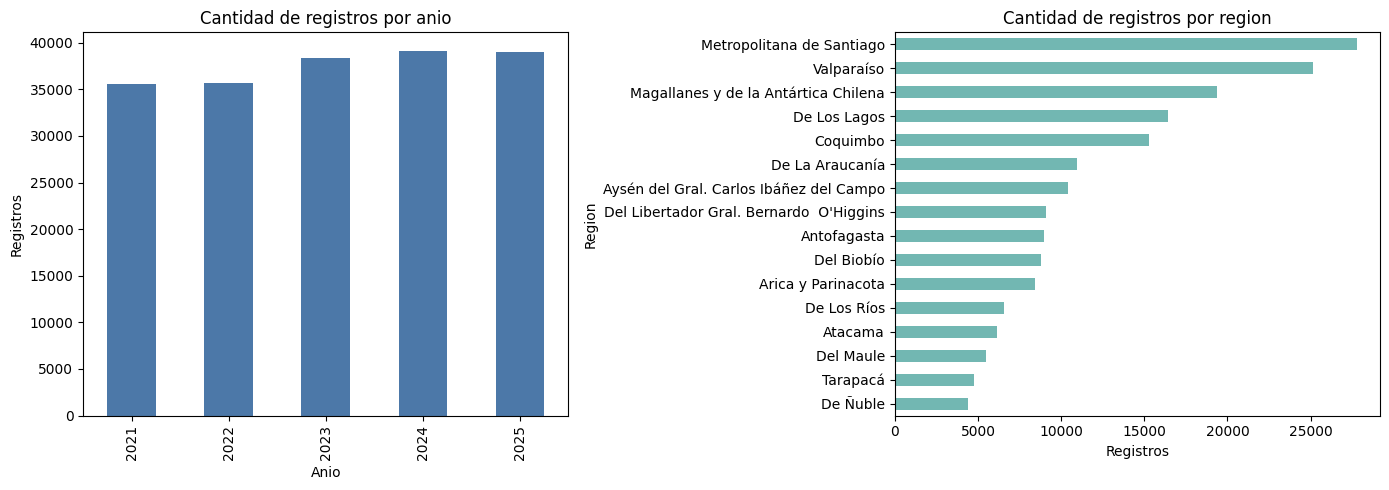

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['anio'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Cantidad de registros por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Registros')

registros_region = df.groupby('nombre_region')['codigo_estacion'].size().sort_values()
registros_region.plot(kind='barh', ax=axes[1], color='#72b7b2')
axes[1].set_title('Cantidad de registros por region')
axes[1].set_xlabel('Registros')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis de cobertura:**

El dataset cubre varios anios y todas las regiones del pais, lo que permite comparar comportamientos territoriales y temporales. Sin embargo, la cantidad de registros no es igual para todas las regiones ni estaciones, por lo que en analisis posteriores conviene usar promedios, porcentajes o tasas cuando se comparen territorios con distinta cantidad de observaciones.


## 2.2 Identificar Nulos

La deteccion de nulos es clave porque un nulo puede ser **ausencia de medicion, falla de estacion o dia sin dato**. **Principio del proyecto:** un nulo en precipitacion NO se asume como 0 (eso inventaria dias secos y sesgaria el analisis).

Los nulos se concentran en `agua_caida` (~9%) y en las temperaturas (`temp_max`, `temp_min`, `temp_media`, ~11-12%); las variables territoriales quedan completas tras la carga controlada. Aqui se **cuantifican**; su **tratamiento** se define en 2.4.2 (imputacion por mediana de la estacion) y, para el target de regresion, excluyendo filas sin medicion.

In [13]:
nulos = df.isna().sum().to_frame('nulos')
nulos['porcentaje'] = (nulos['nulos'] / len(df) * 100).round(2)
nulos = nulos.sort_values('porcentaje', ascending=False)

display(nulos)


,nulos,porcentaje
temp_media,22713,12.09
temp_min,21965,11.69
temp_max,21047,11.20
agua_caida,17063,9.08
codigo_estacion,0,0.00
region,0,0.00
altura,0,0.00
latitud,0,0.00
dia,0,0.00
mes,0,0.00


**Analisis de nulos por variable:**

Los nulos se concentran en variables climaticas, especialmente temperaturas y precipitacion. Por eso el tratamiento posterior debe conservar trazabilidad y evitar imputaciones automaticas sin criterio territorial o estadistico.

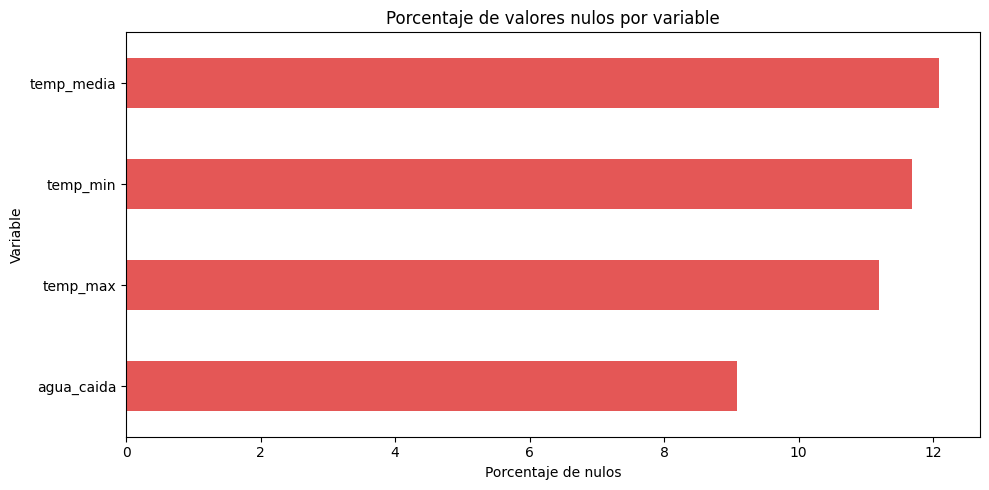

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
nulos[nulos['porcentaje'] > 0]['porcentaje'].sort_values().plot(kind='barh', ax=ax, color='#e45756')
ax.set_title('Porcentaje de valores nulos por variable')
ax.set_xlabel('Porcentaje de nulos')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()


**Analisis del grafico de nulos:**

El grafico permite priorizar las variables con mayor ausencia de datos. Al mostrar porcentajes, no solo cantidades absolutas, se facilita comparar columnas con el mismo universo de registros.

In [15]:
columnas_revision_nulos = ['agua_caida', 'temp_max', 'temp_min', 'temp_media']

nulos_climaticos_anio = df.groupby('anio')[columnas_revision_nulos].apply(
    lambda datos: datos.isna().mean() * 100
).T
nulos_climaticos_anio.columns = nulos_climaticos_anio.columns.astype(int)

display(nulos_climaticos_anio.round(2))


anio,2021,2022,2023,2024,2025
agua_caida,11.84,9.55,12.52,7.54,4.31
temp_max,14.95,13.11,14.36,8.98,5.17
temp_min,16.01,14.28,14.95,8.81,5.08
temp_media,16.56,15.05,15.30,9.00,5.26


**Analisis de nulos climaticos por anio:**

La tabla permite ver que la ausencia de datos no es uniforme en el tiempo. Esta revision justifica complementar el porcentaje general de nulos con una lectura temporal antes de decidir tratamientos.

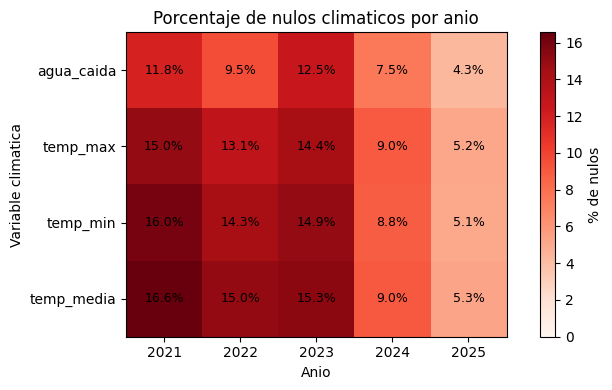

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(nulos_climaticos_anio, cmap='Reds', vmin=0)

ax.set_title('Porcentaje de nulos climaticos por anio')
ax.set_xlabel('Anio')
ax.set_ylabel('Variable climatica')
ax.set_xticks(range(len(nulos_climaticos_anio.columns)))
ax.set_xticklabels(nulos_climaticos_anio.columns)
ax.set_yticks(range(len(nulos_climaticos_anio.index)))
ax.set_yticklabels(nulos_climaticos_anio.index)

for fila in range(len(nulos_climaticos_anio.index)):
    for columna in range(len(nulos_climaticos_anio.columns)):
        valor = nulos_climaticos_anio.iloc[fila, columna]
        color_texto = 'white' if valor >= 20 else 'black'
        ax.text(columna, fila, f'{valor:.1f}%', ha='center', va='center', color=color_texto, fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% de nulos')
plt.tight_layout()
plt.show()


**Analisis de nulos:**

Los nulos se concentran principalmente en variables climaticas: `agua_caida`, `temp_max`, `temp_min` y `temp_media`. El heatmap por anio permite revisar si la ausencia de datos se concentra en periodos especificos o si se mantiene relativamente estable. Esto confirma que el tratamiento de nulos debe ser diferenciado por variable. Para la fase de entendimiento se mantienen los nulos visibles; para modelamiento se evaluara imputacion o eliminacion controlada segun el objetivo del modelo.


## 2.3 Identificar Outliers

Los outliers se detectan con el metodo **IQR**: se marcan los valores fuera del rango `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`, apoyado en percentiles y boxplots. En datos meteorologicos un extremo puede ser un **evento real** (lluvia intensa del sur) o un **error de medicion** (p. ej. 3574 mm en un solo dia).

Por eso **no se eliminan automaticamente**: primero se detectan, se marcan con banderas y se contextualizan; su tratamiento se decide en 2.4.3.

In [17]:
variables_outliers = ['agua_caida', 'temp_max', 'temp_min', 'temp_media', 'altura']

def calcular_resumen_iqr(datos, columna):
    serie = datos[columna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()

    return {
        'variable': columna,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inf,
        'limite_superior': limite_sup,
        'outliers_iqr': outliers,
        'porcentaje_outliers': round(outliers / len(serie) * 100, 2)
    }


In [18]:
resumen_outliers = pd.DataFrame([
    calcular_resumen_iqr(df, columna)
    for columna in variables_outliers
])

display(resumen_outliers)


,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers_iqr,porcentaje_outliers
0,agua_caida,0.0,0.100000,0.100000,-0.150000,0.250000,32994,19.32
1,temp_max,14.0,24.100000,10.100000,-1.150001,39.250001,740,0.44
2,temp_min,4.1,11.400000,7.300000,-6.850000,22.349999,1370,0.83
3,temp_media,9.2,16.700001,7.500001,-2.050002,27.950002,1373,0.83
4,altura,53.0,474.000000,421.000000,-578.500000,1105.500000,15523,8.26


**Analisis de tabla de outliers:**

El resumen cuantifica outliers por variable y permite separar el comportamiento de precipitacion del de temperatura. Esta diferencia es clave porque lluvia requiere un tratamiento especifico por su asimetria.

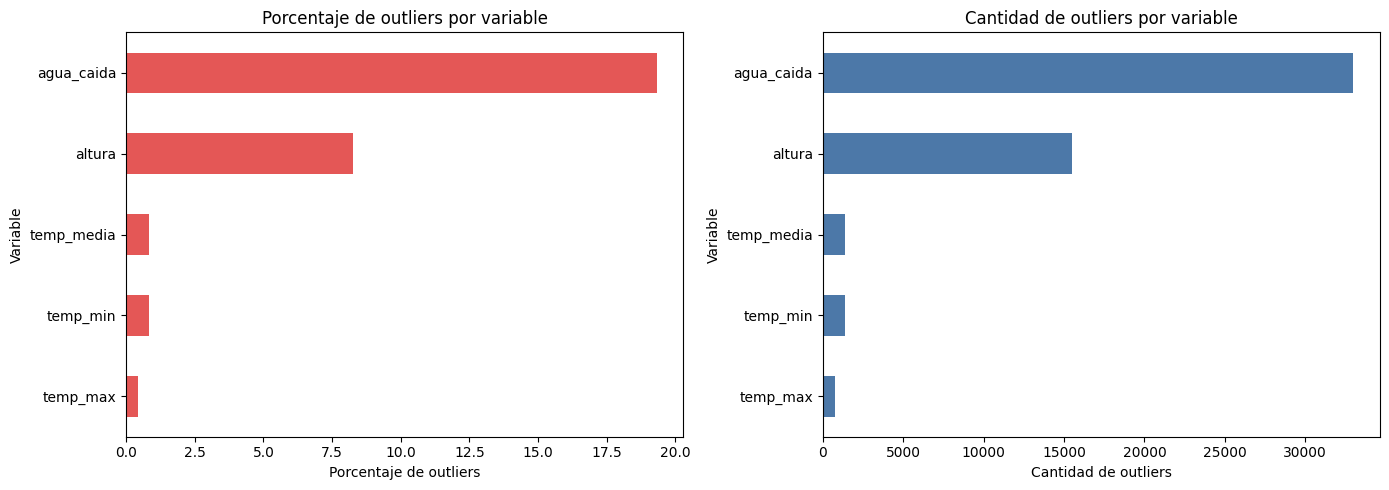

In [19]:
resumen_outliers_ordenado = resumen_outliers.sort_values('porcentaje_outliers')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='porcentaje_outliers',
    ax=axes[0], color='#e45756', legend=False
)
axes[0].set_title('Porcentaje de outliers por variable')
axes[0].set_xlabel('Porcentaje de outliers')
axes[0].set_ylabel('Variable')

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='outliers_iqr',
    ax=axes[1], color='#4c78a8', legend=False
)
axes[1].set_title('Cantidad de outliers por variable')
axes[1].set_xlabel('Cantidad de outliers')
axes[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()


**Analisis general de outliers:**

La precipitacion concentra la mayor cantidad de valores extremos, lo que es esperable por su distribucion asimetrica. Esto justifica tratar lluvia con percentil 99 y no con la misma regla usada para temperaturas.

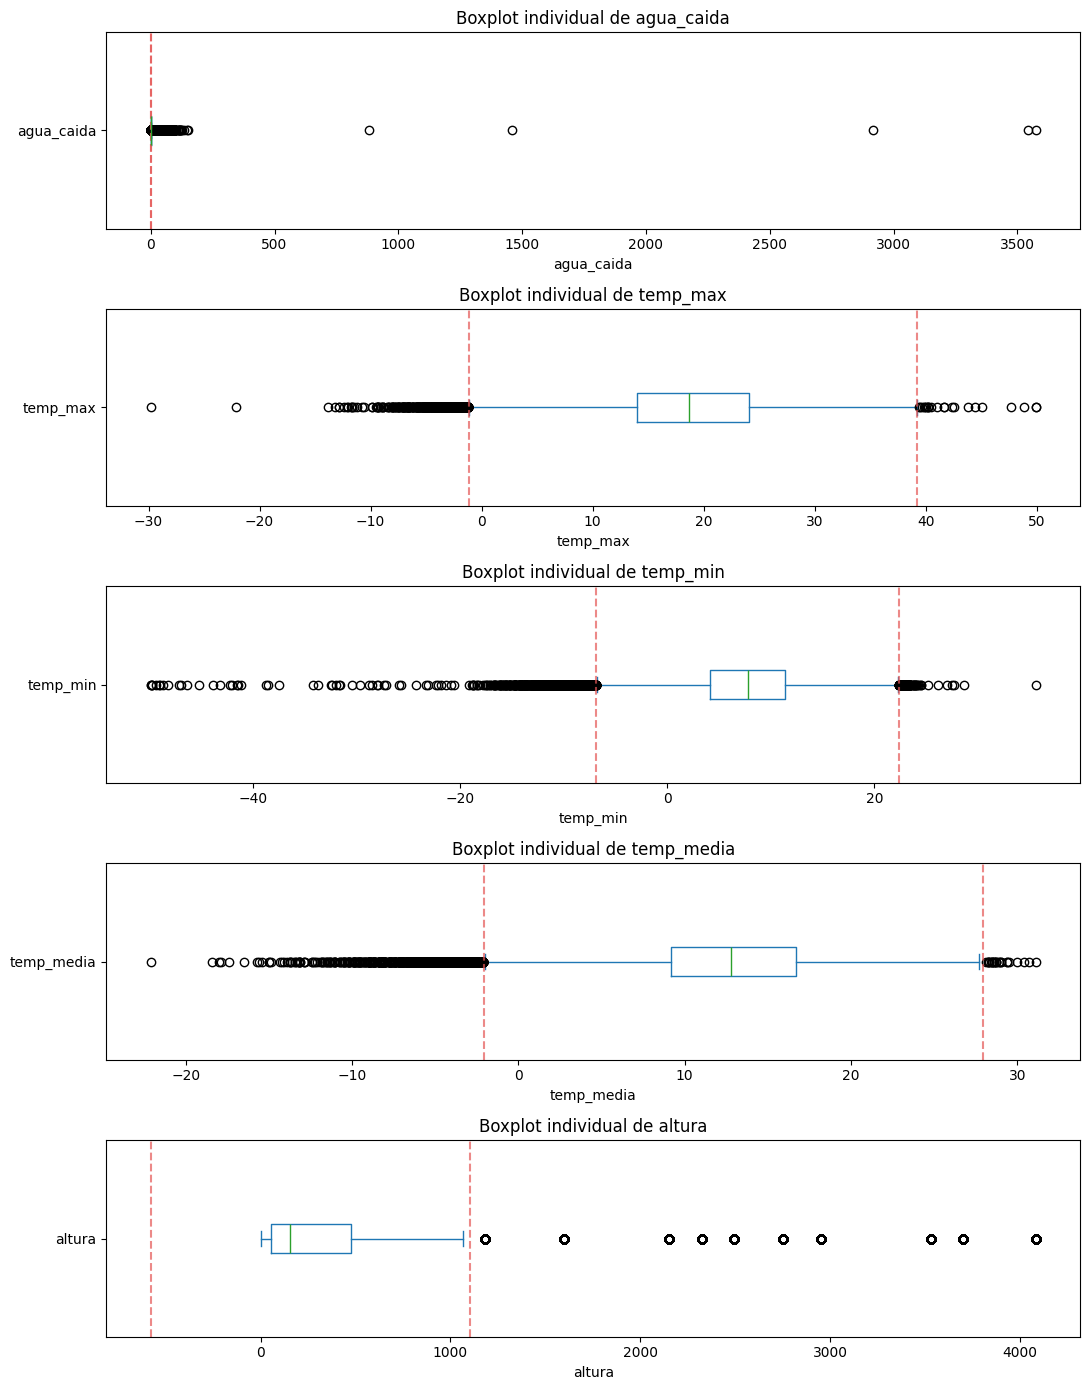

In [20]:
fig, axes = plt.subplots(len(variables_outliers), 1, figsize=(11, 14))

for ax, columna in zip(axes, variables_outliers):
    df[columna].dropna().plot(kind='box', vert=False, ax=ax)
    limites = resumen_outliers.set_index('variable').loc[columna]
    ax.axvline(limites['limite_inferior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.axvline(limites['limite_superior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.set_title(f'Boxplot individual de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis grafico de outliers:**

El grafico general permite comparar rapidamente que variables concentran mas outliers bajo el criterio IQR. Los boxplots individuales complementan esa lectura, porque muestran la forma de la distribucion y la distancia de los valores extremos respecto del rango central. En particular, `agua_caida` requiere cautela: el metodo IQR detecta muchos valores porque la serie tiene muchos ceros y una cola derecha larga. Por eso, para tratamiento se usara un criterio mas conservador basado en extremos altos, no todos los puntos IQR.


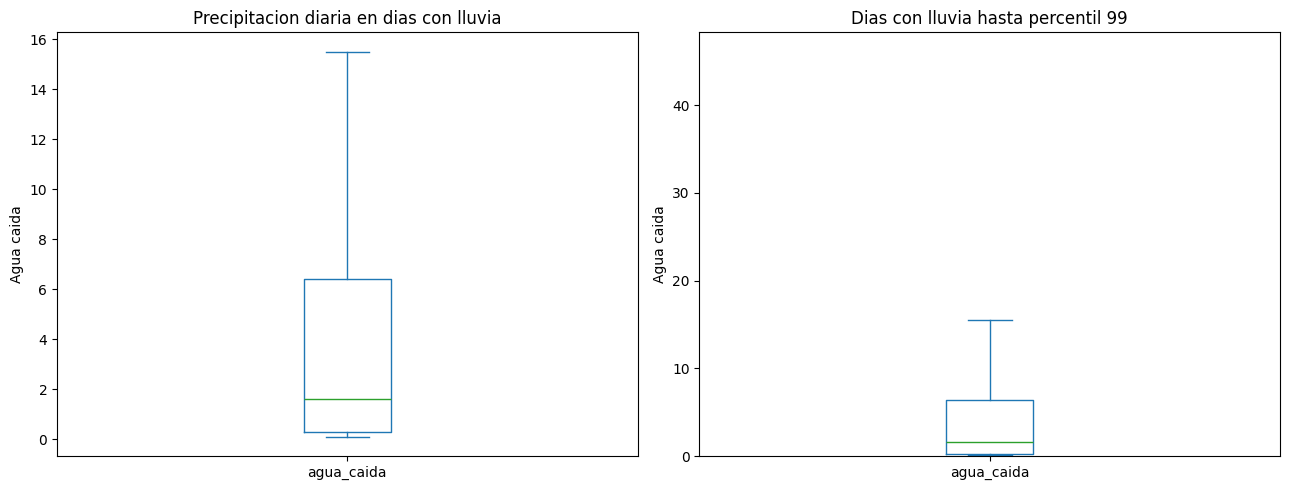

In [21]:
serie_agua = df['agua_caida'].dropna()
serie_agua_lluvia = serie_agua[serie_agua > 0]
limite_visual_agua = serie_agua_lluvia.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

serie_agua_lluvia.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_title('Precipitacion diaria en dias con lluvia')
axes[0].set_ylabel('Agua caida')

serie_agua_lluvia.plot(kind='box', ax=axes[1], showfliers=False)
axes[1].set_title('Dias con lluvia hasta percentil 99')
axes[1].set_ylabel('Agua caida')
axes[1].set_ylim(0, limite_visual_agua)

plt.tight_layout()
plt.show()


**Analisis de precipitacion en dias con lluvia:**

Al excluir dias con 0 mm, el boxplot muestra mejor la dispersion real de los eventos de lluvia. La vista acotada al percentil 99 mantiene escala normal y evita que pocos extremos oculten el comportamiento central.

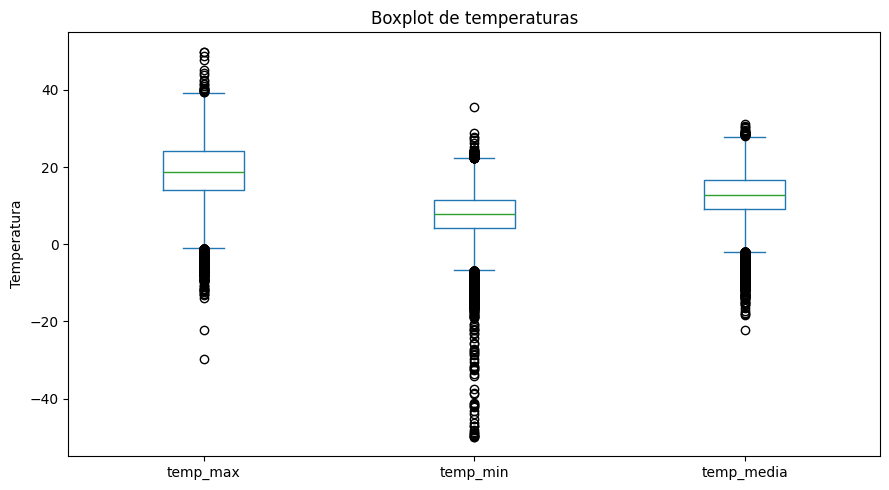

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
df[['temp_max', 'temp_min', 'temp_media']].plot(kind='box', ax=ax)
ax.set_title('Boxplot de temperaturas')
ax.set_ylabel('Temperatura')
plt.tight_layout()
plt.show()


**Analisis de temperaturas:**

Los boxplots de temperatura muestran dispersion mas estable que la precipitacion, aunque existen valores extremos. Estos extremos deben revisarse con cuidado porque pueden representar condiciones reales o errores de registro.

In [23]:
top_precipitaciones = df.sort_values('agua_caida', ascending=False).head(10)[[
    'fecha', 'codigo_estacion', 'nombre_estacion', 'nombre_region',
    'zona_geografica', 'agua_caida', 'temp_media', 'altura'
]]

display(top_precipitaciones)


,fecha,codigo_estacion,nombre_estacion,nombre_region,zona_geografica,agua_caida,temp_media,altura
75680,2025-12-08,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,3574.300049,21.400000,876
133239,2025-12-07,380082,Isla Mocha Ad.,Del Biobío,Litoral,3541.500000,16.500000,6
75679,2025-12-07,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,2917.399902,19.000000,876
133240,2025-12-09,380082,Isla Mocha Ad.,Del Biobío,Litoral,1459.900024,16.400000,6
75681,2025-12-09,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,880.099976,21.299999,876
97400,2023-08-21,340031,"General Freire, Curicó Ad.",Del Maule,Valle,150.199997,13.400000,229
74780,2023-06-22,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,145.199997,11.000000,876
123155,2022-04-28,380018,Lonquimay,De La Araucanía,PreCordillera,136.399994,NaN,912
138886,2021-05-31,390043,Corral ESSAL,De Los Ríos,Litoral,126.800003,13.900000,24
102878,2023-08-21,340066,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Secano Interior,121.300003,NaN,81


**Analisis de outliers:**

La variable `agua_caida` es altamente asimetrica: muchos dias tienen precipitacion cero o baja, mientras que pocos registros concentran valores muy altos. Por eso se revisa la distribucion en escala normal con una vista completa y una vista acotada al percentil 99. Los valores mas altos deben ser tratados con especial cuidado, ya que pueden representar eventos climaticos excepcionales o posibles errores de registro.


## 2.4 Transformaciones

En esta fase se realizan transformaciones iniciales orientadas al entendimiento de datos. No se aplicara aun escalamiento ni preparacion definitiva para modelos, porque eso corresponde a la Fase 3. Aqui se verifica la limpieza inicial de textos, se preparan codificaciones simples para analisis y se definen criterios de tratamiento para nulos y outliers.


### 2.4.1 Codificacion inicial a numericos

Las variables **categoricas** no entran directamente en modelos matematicos, por lo que se **codifican a numero**. En esta etapa exploratoria se crean codigos para `region`, `zona_geografica` y `macrozona` (con `.cat.codes`), utiles para la matriz de correlacion.

La **macrozona** agrupa las regiones en grandes areas climaticas (Norte Grande, Norte Chico, Zona Central, Zona Sur, Zona Austral), mas interpretable que la region individual. **Nota:** el encoding definitivo para modelar es **one-hot** (Fase 3.4), que evita imponer un orden artificial entre categorias.

In [24]:
df_eda = df.copy()

macrozonas_orden = ['Norte Grande', 'Norte Chico', 'Zona Central', 'Zona Sur', 'Zona Austral']

def asignar_macrozona(region):
    if region in [15, 1, 2]:
        return 'Norte Grande'
    if region in [3, 4]:
        return 'Norte Chico'
    if region in [5, 13, 6, 7, 16, 8]:
        return 'Zona Central'
    if region in [9, 14, 10]:
        return 'Zona Sur'
    if region in [11, 12]:
        return 'Zona Austral'
    return 'Sin clasificar'

df_eda['macrozona'] = df_eda['region'].apply(asignar_macrozona)
df_eda['macrozona'] = pd.Categorical(df_eda['macrozona'], categories=macrozonas_orden, ordered=True)


In [25]:
df_eda['region_cod'] = df_eda['nombre_region'].astype('category').cat.codes
df_eda['zona_geografica_cod'] = df_eda['zona_geografica'].astype('category').cat.codes
df_eda['macrozona_cod'] = df_eda['macrozona'].cat.codes

columnas_codificacion = [
    'region', 'nombre_region', 'macrozona', 'region_cod',
    'zona_geografica', 'zona_geografica_cod', 'macrozona_cod'
]
codificacion = df_eda[columnas_codificacion].drop_duplicates()

display(codificacion.sort_values(['macrozona', 'region', 'zona_geografica']).head(15))


,region,nombre_region,macrozona,region_cod,zona_geografica,zona_geografica_cod,macrozona_cod
8400,1,Tarapacá,Norte Grande,14,Cordillera,0,0
9496,1,Tarapacá,Norte Grande,14,Litoral,1,0
16796,2,Antofagasta,Norte Grande,0,Cordillera,0,0
14974,2,Antofagasta,Norte Grande,0,Litoral,1,0
13148,2,Antofagasta,Norte Grande,0,PreCordillera,2,0
0,15,Arica y Parinacota,Norte Grande,1,Cordillera,0,0
1096,15,Arica y Parinacota,Norte Grande,1,Litoral,1,0
2922,15,Arica y Parinacota,Norte Grande,1,PreCordillera,2,0
25053,3,Atacama,Norte Chico,2,Secano Costero,3,1
22131,3,Atacama,Norte Chico,2,Valle,5,1


**Analisis de codificacion categorica:**

La codificacion transforma regiones, zonas y macrozonas en variables numericas sin perder la categoria original. Esto permite usar las variables territoriales en correlaciones y modelos posteriores.

### 2.4.2 Tratamiento de Nulos

El tratamiento definitivo de nulos se aplica segun el objetivo del modelo. Estrategia por variable:

| Variable | Estrategia |
|---|---|
| `agua_caida` | Si falta la medicion del dia, la fila se excluye del set supervisado (no se inventa el target con 0). |
| `temp_max`, `temp_min`, `temp_media` | Imputacion con la mediana de la propia estacion; respaldo con la mediana global. |
| Categoricas | Moda solo si aparecen nulos; las territoriales quedan completas tras corregir la carga. |

In [26]:
# Imputacion de temperatura por mediana de cada estacion (respeta el regimen climatico local)
columnas_temp = ['temp_max', 'temp_min', 'temp_media']
for col in columnas_temp:
    df_eda[col] = df_eda.groupby('codigo_estacion')[col].transform(lambda s: s.fillna(s.median()))
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

print('Nulos restantes tras imputar temperatura:')
print(df_eda[columnas_temp].isna().sum())

Nulos restantes tras imputar temperatura:
temp_max      0
temp_min      0
temp_media    0
dtype: int64


**Analisis de estrategia de nulos:**

La estrategia separa variables climaticas, territoriales y temporales. Esta distincion es importante porque no todos los nulos tienen el mismo significado ni deben recibir el mismo tratamiento.

### 2.4.3 Tratamiento de Outliers

Se aplican **dos niveles**:

1. **Banderas IQR** para variables climaticas: marcan los extremos **sin eliminarlos**, conservando trazabilidad.
2. **Umbral fisico para `agua_caida`**: lluvias diarias sobre **150 mm** se consideran errores de medicion (valores como 3574 mm son imposibles) y se reemplazan por la **mediana de los dias con lluvia** -no por la mediana global, que es 0 y borraria el evento-, generando `agua_caida_tratada`.

La variable **original se conserva** para auditoria. A diferencia de un recorte por percentil, el umbral fisico **preserva los eventos intensos reales** (50-150 mm) del sur de Chile.

In [27]:
def marcar_outliers_iqr(datos, columna):
    serie = datos[columna]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)


In [28]:
df_eda['outlier_agua_caida_iqr'] = marcar_outliers_iqr(df_eda, 'agua_caida')
df_eda['outlier_temp_media_iqr'] = marcar_outliers_iqr(df_eda, 'temp_media')

resumen_banderas_outliers = df_eda[
    ['outlier_agua_caida_iqr', 'outlier_temp_media_iqr']
].sum().to_frame('cantidad')
resumen_banderas_outliers['porcentaje'] = (
    resumen_banderas_outliers['cantidad'] / len(df_eda) * 100
).round(2)

display(resumen_banderas_outliers)


,cantidad,porcentaje
outlier_agua_caida_iqr,32994,17.56
outlier_temp_media_iqr,1993,1.06


**Analisis de banderas de outliers:**

Las banderas permiten marcar registros extremos sin eliminarlos. Esta estrategia conserva trazabilidad y facilita comparar el dato original con variables tratadas.

In [29]:
# Umbral fisico: lluvias diarias sobre 150mm en este dataset corresponden a errores de medicion
# (valores como 3574mm son imposibles). Solo afecta a 6 registros.
umbral_extremo_lluvia = 150
mediana_lluvia_no_extrema = df_eda.loc[df_eda['agua_caida'] > 0, 'agua_caida'].median()

In [30]:
df_eda['outlier_extremo_agua_caida'] = df_eda['agua_caida'] > umbral_extremo_lluvia

# Se imputa el extremo por la mediana de los dias con lluvia (no por la mediana global,
# que es 0 y convertiria una lluvia en un dia seco). Conserva la variable original para auditoria.
df_eda['agua_caida_tratada'] = df_eda['agua_caida'].where(
    df_eda['agua_caida'] <= umbral_extremo_lluvia,
    mediana_lluvia_no_extrema
)

**Analisis del tratamiento de extremos de lluvia:**

El resumen documenta el umbral usado, el valor de reemplazo y cuantas observaciones fueron tratadas. Esto hace auditable la creacion de `agua_caida_tratada` y evita modificar la variable original.

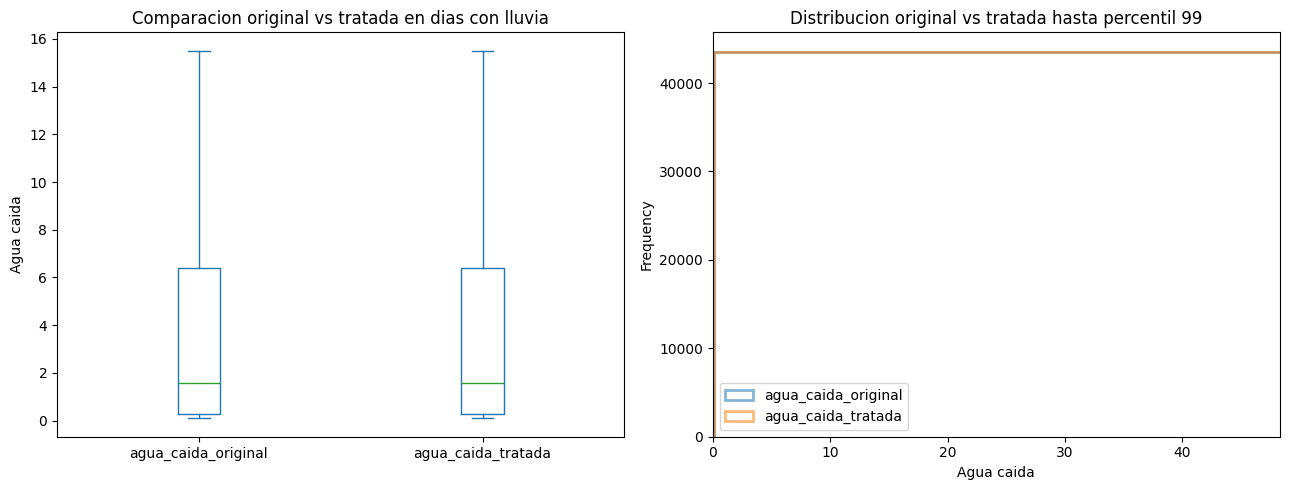

In [31]:
comparacion_lluvia = pd.DataFrame({
    'agua_caida_original': df_eda['agua_caida'],
    'agua_caida_tratada': df_eda['agua_caida_tratada']
})

comparacion_lluvia_positiva = comparacion_lluvia[comparacion_lluvia['agua_caida_original'] > 0]
limite_visual_comparacion = comparacion_lluvia_positiva.quantile(0.99).max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparacion_lluvia_positiva.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_title('Comparacion original vs tratada en dias con lluvia')
axes[0].set_ylabel('Agua caida')

comparacion_lluvia_positiva.plot(kind='hist', bins=50, alpha=0.55, histtype='step', linewidth=2, ax=axes[1])
axes[1].set_title('Distribucion original vs tratada hasta percentil 99')
axes[1].set_xlabel('Agua caida')
axes[1].set_xlim(0, limite_visual_comparacion)

plt.tight_layout()
plt.show()


**Analisis del tratamiento de lluvia:**

El tratamiento reemplaza unicamente los valores superiores a 150mm de `agua_caida` (solo 6 registros, con valores como 3574mm que son errores de medicion), usando la mediana de los dias con lluvia. Se conserva la variable original `agua_caida` para auditoria. No se usa la mediana general porque en lluvia diaria suele ser 0, lo que convertiria un evento de lluvia en un dia seco. A diferencia de un recorte por percentil, este umbral fisico preserva los eventos de lluvia intensa reales (50-150mm) del sur de Chile.

**Analisis de transformaciones iniciales:**

Las transformaciones realizadas permiten continuar el analisis sin perder trazabilidad. La correccion de texto mejora la interpretacion de regiones y estaciones en graficos, y la macrozona permite resumir regiones en grupos territoriales mas interpretables. Los codigos numericos permiten estudiar correlaciones exploratorias, pero no reemplazan una preparacion formal para modelamiento. Los outliers quedan marcados y, para lluvia extrema, se crea una variable tratada que reduce distorsion sin perder el registro original.


## 2.5 Analisis estadisticos basicos

Se calculan estadisticos descriptivos para comprender rangos, dispersion y comportamiento general de las variables numericas. Desde esta seccion, los resumenes de precipitacion usan `agua_caida_tratada` para evitar que pocos extremos altos dominen las medidas. Luego se agregan resultados por region, macrozona y zona geografica para obtener una lectura territorial en distintos niveles de detalle.


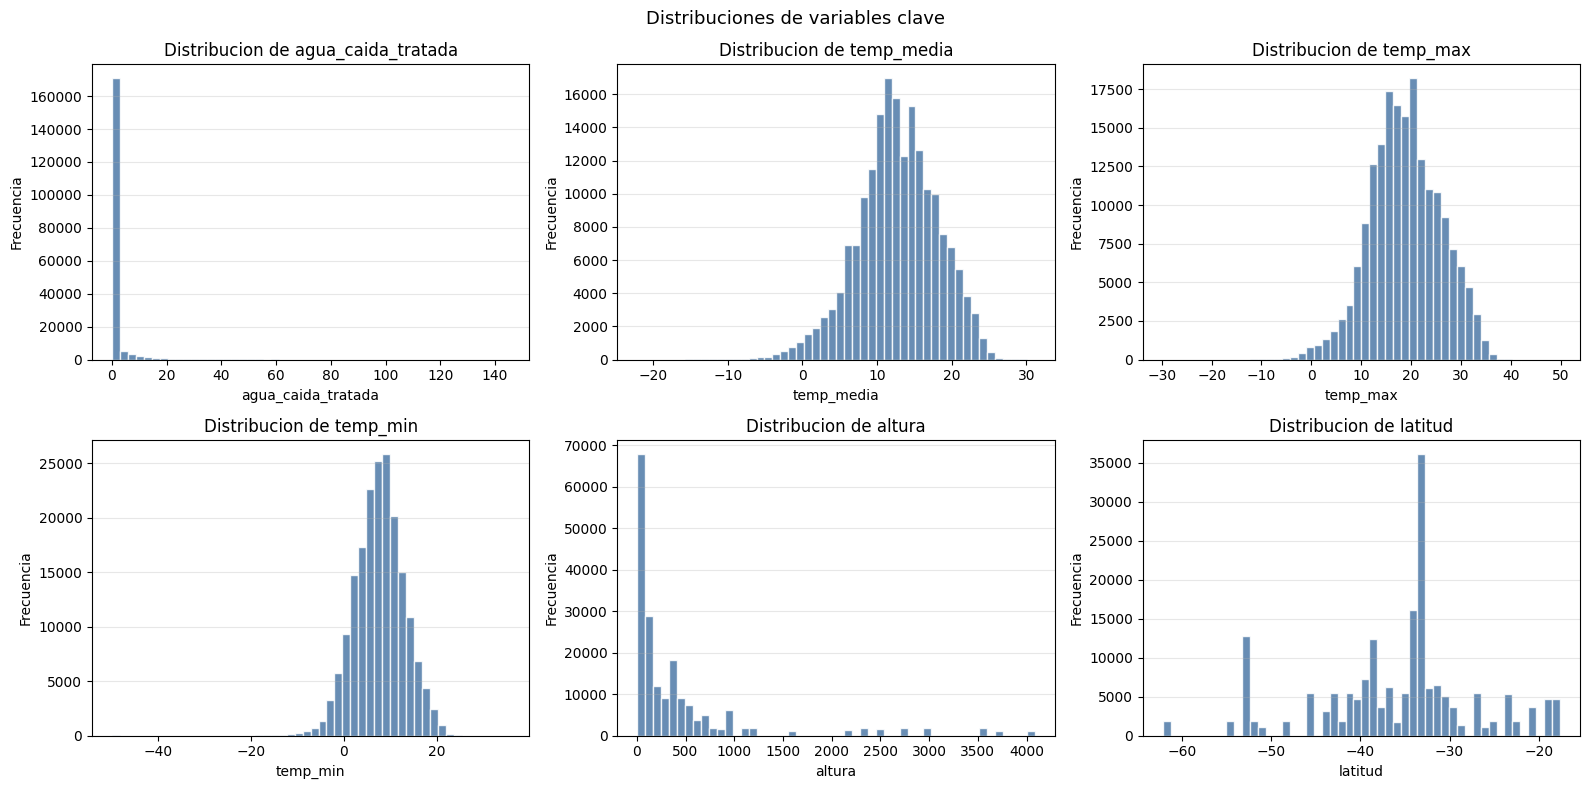

In [32]:
variables_dist = ['agua_caida_tratada', 'temp_media', 'temp_max', 'temp_min', 'altura', 'latitud']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, var in zip(axes.ravel(), variables_dist):
    datos = df_eda[var].dropna()
    ax.hist(datos, bins=50, color='#4e79a7', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribucion de {var}')
    ax.set_xlabel(var); ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Distribuciones de variables clave', fontsize=13)
plt.tight_layout()
plt.show()

**Analisis de distribuciones:**

La precipitacion tratada es fuertemente asimetrica con masa en cero (mayoria de dias secos), lo que justifica tratarla aparte de las temperaturas, que son aproximadamente simetricas. La isoterma cero y la altura muestran distribuciones multimodales que reflejan la diversidad geografica de las estaciones.

In [33]:
variables_numericas_base = ['altura', 'latitud', 'longitud', 'agua_caida', 'agua_caida_tratada', 'temp_max', 'temp_min', 'temp_media']
estadisticos_base = df_eda[variables_numericas_base].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

display(estadisticos_base)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
altura,187876.0,441.945948,741.219754,5.000000,6.00000,11.00000,53.00000,156.000000,474.000000,2326.000000,3700.000000,4084.000000
latitud,187876.0,-35.850940,8.856507,-62.191940,-54.93167,-53.13000,-40.08361,-33.728330,-32.222500,-19.276940,-18.200000,-17.595000
longitud,187876.0,-71.691117,4.176134,-109.432500,-78.83305,-73.73528,-72.34389,-71.186670,-70.682780,-69.294720,-67.615560,-58.979720
agua_caida,170813.0,1.494435,15.673269,0.000000,0.00000,0.00000,0.00000,0.000000,0.100000,8.600000,27.799999,3574.300049
agua_caida_tratada,187876.0,1.437416,5.281025,0.000000,0.00000,0.00000,0.00000,0.000000,0.400000,7.800000,26.600000,145.199997
temp_max,187876.0,18.862424,7.045586,-29.799999,1.10000,7.40000,14.20000,18.799999,23.799999,30.700001,33.799999,49.900002
temp_min,187876.0,7.645924,5.308648,-49.900002,-5.40000,-1.10000,4.30000,7.800000,11.100000,16.400000,19.500000,35.599998
temp_media,187876.0,12.711392,5.364868,-22.100000,-1.30000,3.50000,9.40000,12.700000,16.400000,21.400000,23.700001,31.100000


**Analisis estadistico base:**

Los estadisticos muestran que la precipitacion tiene alta dispersion y muchos valores bajos, mientras que las temperaturas presentan un comportamiento mas continuo. Esto anticipa que los modelos de lluvia seran mas dificiles que los de temperatura.

In [34]:
estadisticos_region = df_eda.groupby('nombre_region').agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).sort_values('agua_promedio', ascending=False).round(3)

display(estadisticos_region)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
nombre_region,,,,,
De Los Ríos,6569,4,3.766,24739.2,11.302
Aysén del Gral. Carlos Ibáñez del Campo,10437,6,3.462,36135.1,8.881
De Los Lagos,16434,9,3.386,55650.0,10.555
De La Araucanía,10956,6,2.374,26004.2,11.260
Del Biobío,8764,5,2.341,20515.3,12.854
De Ñuble,4383,3,2.235,9796.0,13.013
Del Maule,5456,3,1.521,8300.6,14.216
Magallanes y de la Antártica Chilena,19347,11,1.228,23749.1,5.793
Valparaíso,25116,15,0.958,24060.0,13.842


**Analisis por region:**

El resumen regional evidencia diferencias climaticas importantes entre territorios. Estas diferencias respaldan el uso de variables geograficas como predictoras y la necesidad de analizar resultados por zona.

In [35]:
estadisticos_zona = df_eda.groupby('zona_geografica').agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).sort_values('agua_promedio', ascending=False).round(3)

display(estadisticos_zona)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
zona_geografica,,,,,
Litoral,64838,36,1.768,114639.4,12.228
Valle,86617,51,1.486,128715.9,12.944
Secano Interior,2557,2,1.116,2853.2,12.979
PreCordillera,19060,11,0.939,17899.7,14.084
Cordillera,7527,5,0.493,3712.2,9.370
Secano Costero,7277,4,0.307,2235.5,14.017


**Analisis por zona geografica:**

La agrupacion por zona reduce ruido respecto de la region individual y permite observar patrones climaticos mas interpretables. Esto ayuda a conectar el analisis con decisiones territoriales.

In [36]:
estadisticos_macrozona = df_eda.groupby('macrozona', observed=True).agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).round(3)

display(estadisticos_macrozona)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
macrozona,,,,,
Norte Grande,22131,13,0.221,4901.4,16.185
Norte Chico,21410,13,0.340,7284.9,15.468
Zona Central,80592,47,1.136,91592.0,13.934
Zona Sur,33959,19,3.133,106393.4,10.927
Zona Austral,29784,17,2.011,59884.2,6.875


**Analisis por macrozona:**

La macrozona resume el comportamiento territorial en categorias amplias. Esta variable es util para graficos, correlaciones, modelos y para explicar resultados de forma clara frente a la rubrica.

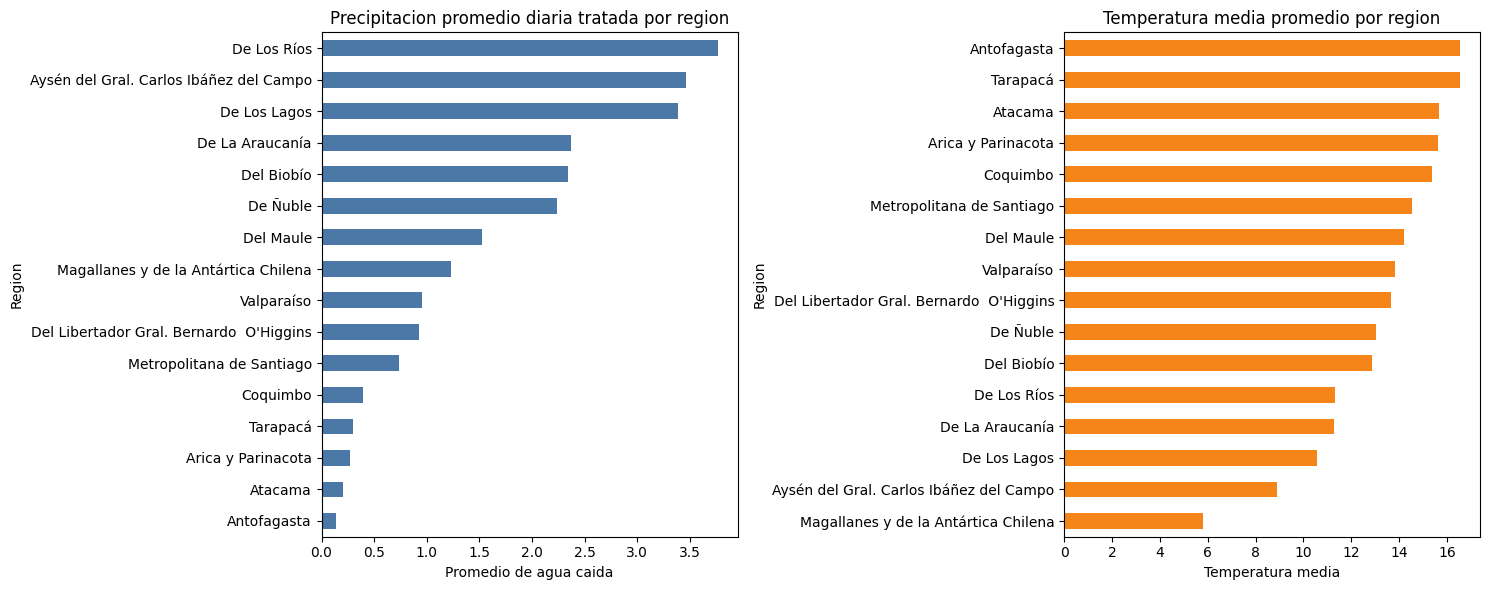

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

estadisticos_region['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por region')
axes[0].set_xlabel('Promedio de agua caida')
axes[0].set_ylabel('Region')

estadisticos_region['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por region')
axes[1].set_xlabel('Temperatura media')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis grafico por region:**

La comparacion visual confirma que precipitacion y temperatura no se distribuyen igual entre regiones. Esto indica que la ubicacion geografica tiene valor explicativo para el modelamiento.

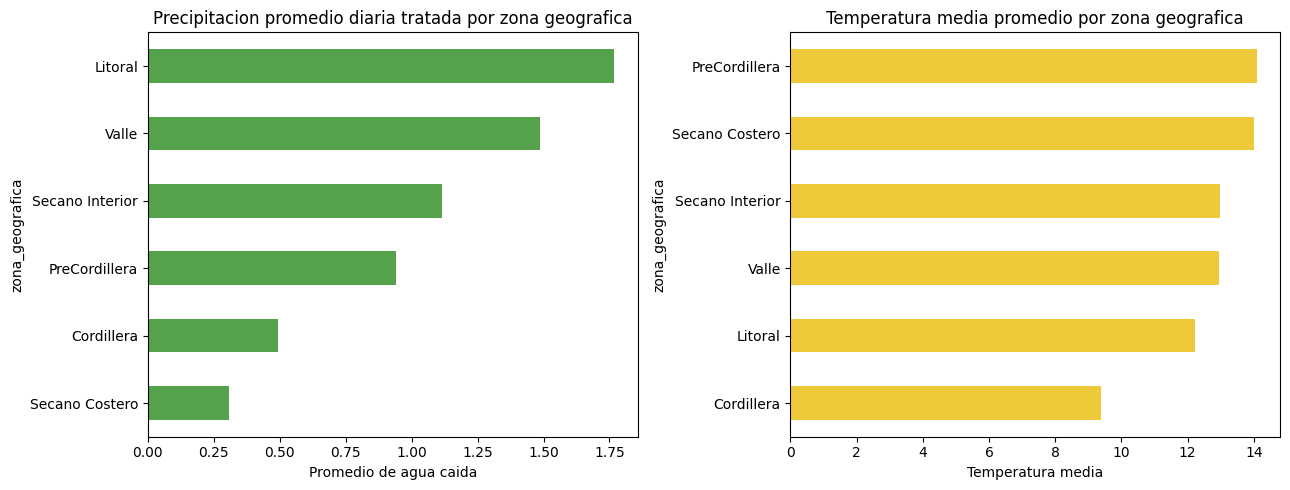

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_zona['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#54a24b')
axes[0].set_title('Precipitacion promedio diaria tratada por zona geografica')
axes[0].set_xlabel('Promedio de agua caida')

estadisticos_zona['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#eeca3b')
axes[1].set_title('Temperatura media promedio por zona geografica')
axes[1].set_xlabel('Temperatura media')

plt.tight_layout()
plt.show()


**Analisis grafico por zona:**

Las zonas permiten distinguir gradientes climaticos sin saturar el grafico con demasiadas categorias. Esta lectura territorial fortalece las hipotesis sobre macrozonas y estacionalidad.

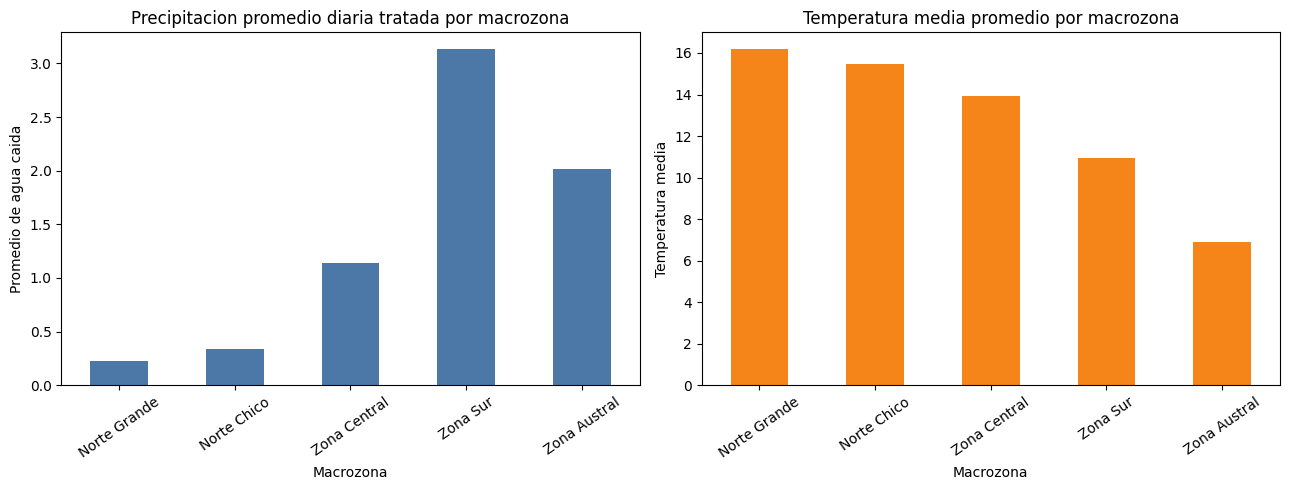

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_macrozona['agua_promedio'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por macrozona')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Promedio de agua caida')
axes[0].tick_params(axis='x', rotation=35)

estadisticos_macrozona['temp_media_promedio'].plot(kind='bar', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Analisis grafico por macrozona:**

La macrozona muestra diferencias claras en precipitacion y temperatura promedio. Esta evidencia justifica incluir `macrozona_cod` en los modelos como variable predictora codificada.

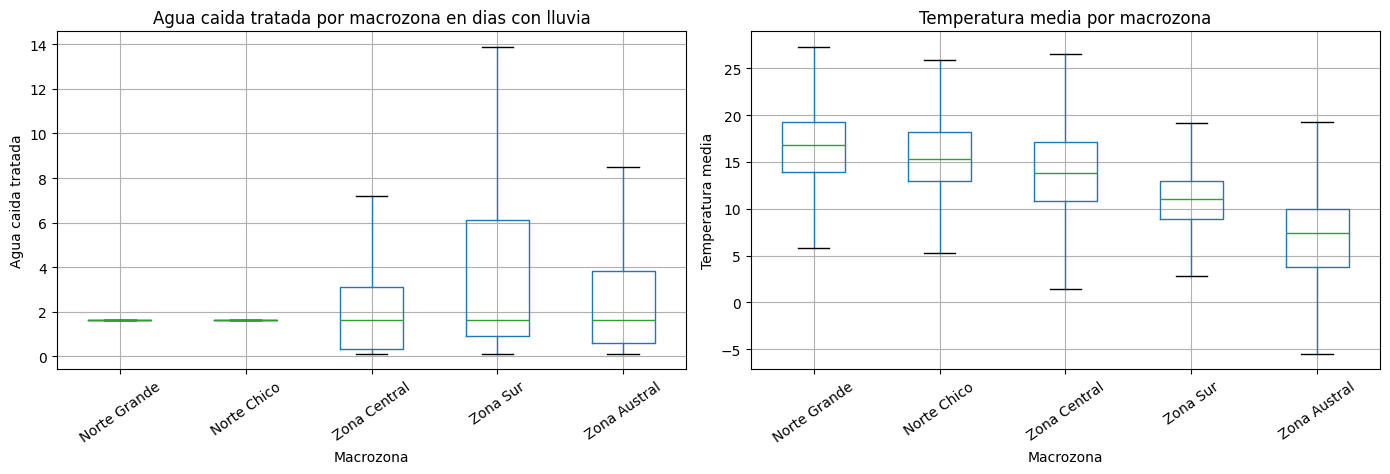

In [40]:
macrozona_lluvia = df_eda[df_eda['agua_caida_tratada'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

macrozona_lluvia.boxplot(column='agua_caida_tratada', by='macrozona', ax=axes[0], rot=35, showfliers=False)
axes[0].set_title('Agua caida tratada por macrozona en dias con lluvia')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Agua caida tratada')

df_eda.boxplot(column='temp_media', by='macrozona', ax=axes[1], rot=35, showfliers=False)
axes[1].set_title('Temperatura media por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por macrozona:**

La macrozona permite leer los datos de manera mas clara que una comparacion con muchas regiones. Esta agrupacion ayuda a distinguir patrones climaticos amplios entre norte, centro, sur y extremo austral, manteniendo una interpretacion territorial comprensible para el analisis de negocio.


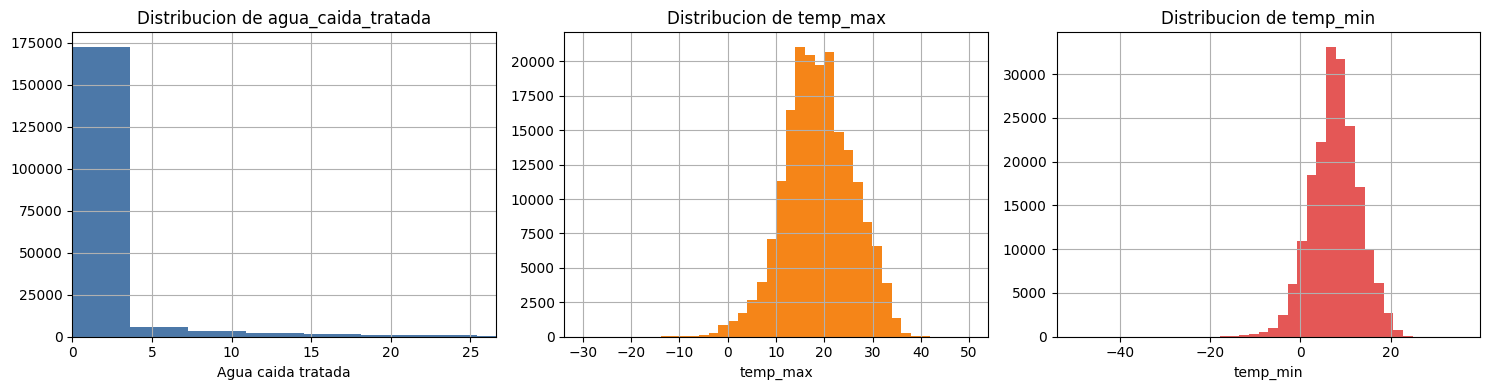

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

serie_lluvia_tratada = df_eda['agua_caida_tratada'].dropna()
serie_lluvia_tratada.hist(bins=40, ax=axes[0], color='#4c78a8')
axes[0].set_title('Distribucion de agua_caida_tratada')
axes[0].set_xlabel('Agua caida tratada')
axes[0].set_xlim(0, serie_lluvia_tratada.quantile(0.99))

for columna, ax, color in zip(['temp_max', 'temp_min'], axes[1:], ['#f58518', '#e45756']):
    df_eda[columna].dropna().hist(bins=40, ax=ax, color=color)
    ax.set_title(f'Distribucion de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis estadistico:**

Los estadisticos y graficos muestran que la precipitacion, incluso tratada, no se distribuye de forma normal: predominan valores bajos y pocos eventos concentran montos altos. Las temperaturas presentan una distribucion mas continua y son mas adecuadas para analisis de correlacion directa. Las comparaciones por region, macrozona y zona permiten comenzar a validar hipotesis territoriales en distintos niveles de detalle.


## 2.6 Matriz de Correlacion

La matriz de correlacion permite analizar relaciones lineales entre variables numericas. No implica causalidad, pero ayuda a identificar variables que podrian aportar informacion en modelos predictivos.


In [42]:
def graficar_matriz_correlacion(correlacion, titulo, figsize=(8, 6), rotacion=45):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)

    ax.set_xticks(range(len(correlacion.columns)))
    ax.set_yticks(range(len(correlacion.index)))
    ax.set_xticklabels(correlacion.columns, rotation=rotacion, ha='right')
    ax.set_yticklabels(correlacion.index)
    ax.set_title(titulo)

    for fila in range(len(correlacion.index)):
        for columna in range(len(correlacion.columns)):
            valor = correlacion.iloc[fila, columna]
            color_texto = 'white' if abs(valor) >= 0.60 else 'black'
            ax.text(columna, fila, f'{valor:.2f}', ha='center', va='center', fontsize=8, color=color_texto)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


In [43]:
columnas_correlacion_inicial = [
    'altura', 'latitud', 'longitud', 'mes', 'agua_caida_tratada',
    'temp_max', 'temp_min', 'temp_media'
]

corr_inicial = df_eda[columnas_correlacion_inicial].corr(numeric_only=True)
display(corr_inicial.round(3))


,altura,latitud,longitud,mes,agua_caida_tratada,temp_max,temp_min,temp_media
altura,1.000,0.393,0.182,-0.002,-0.070,0.073,-0.178,-0.040
latitud,0.393,1.000,-0.062,-0.002,-0.121,0.524,0.480,0.562
longitud,0.182,-0.062,1.000,-0.001,-0.071,-0.081,-0.226,-0.171
mes,-0.002,-0.002,-0.001,1.000,0.003,-0.124,-0.133,-0.140
agua_caida_tratada,-0.070,-0.121,-0.071,0.003,1.000,-0.198,-0.028,-0.132
temp_max,0.073,0.524,-0.081,-0.124,-0.198,1.000,0.569,0.895
temp_min,-0.178,0.480,-0.226,-0.133,-0.028,0.569,1.000,0.856
temp_media,-0.040,0.562,-0.171,-0.140,-0.132,0.895,0.856,1.000


**Analisis de matriz inicial:**

La matriz inicial muestra relaciones entre variables base antes de incorporar nuevas variables derivadas. Esta comparacion sirve como linea base para evaluar si las transformaciones agregan informacion.

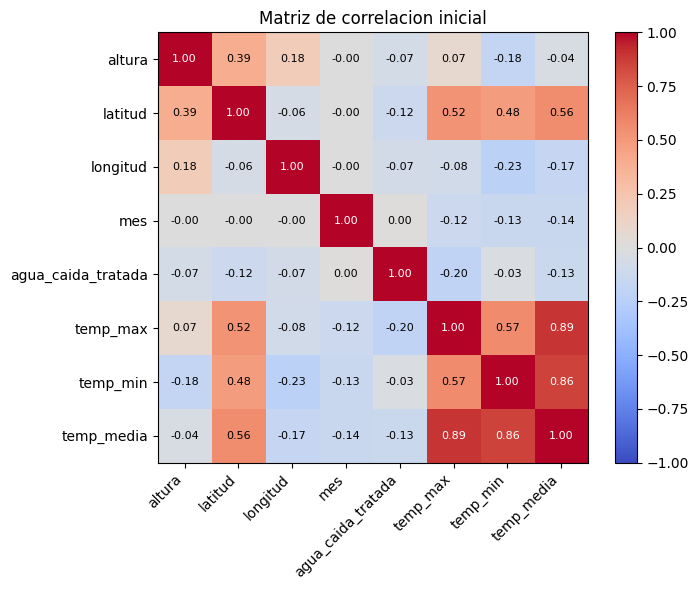

In [44]:
graficar_matriz_correlacion(
    corr_inicial,
    'Matriz de correlacion inicial',
    figsize=(8, 6),
    rotacion=45
)


**Analisis de correlacion inicial:**

Se espera observar una relacion fuerte entre las variables de temperatura, especialmente entre `temp_media`, `temp_max` y `temp_min`. Las variables geograficas como `latitud` y `altura` pueden mostrar relacion con temperatura, lo que es consistente con el comportamiento climatico esperado. La variable `agua_caida_tratada` puede presentar correlaciones mas debiles porque la lluvia diaria suele depender de patrones no lineales y eventos puntuales.


## 2.7 Patrones/comportamientos detectados

En esta seccion se revisan patrones temporales, geograficos y climaticos mediante graficos. Cada grafico responde a una pregunta concreta: como cambia la lluvia por mes, como cambia la temperatura, que zonas concentran mas precipitacion y como se relacionan ubicacion y clima.


In [45]:
mensual = df_eda.assign(
    periodo=df_eda['fecha'].dt.to_period('M').dt.to_timestamp()
).groupby(['anio', 'mes', 'periodo']).agg(
    agua_total=('agua_caida_tratada', 'sum'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    temp_media=('temp_media', 'mean')
).reset_index()

anios_disponibles = sorted(mensual['anio'].unique())
meses = range(1, 13)

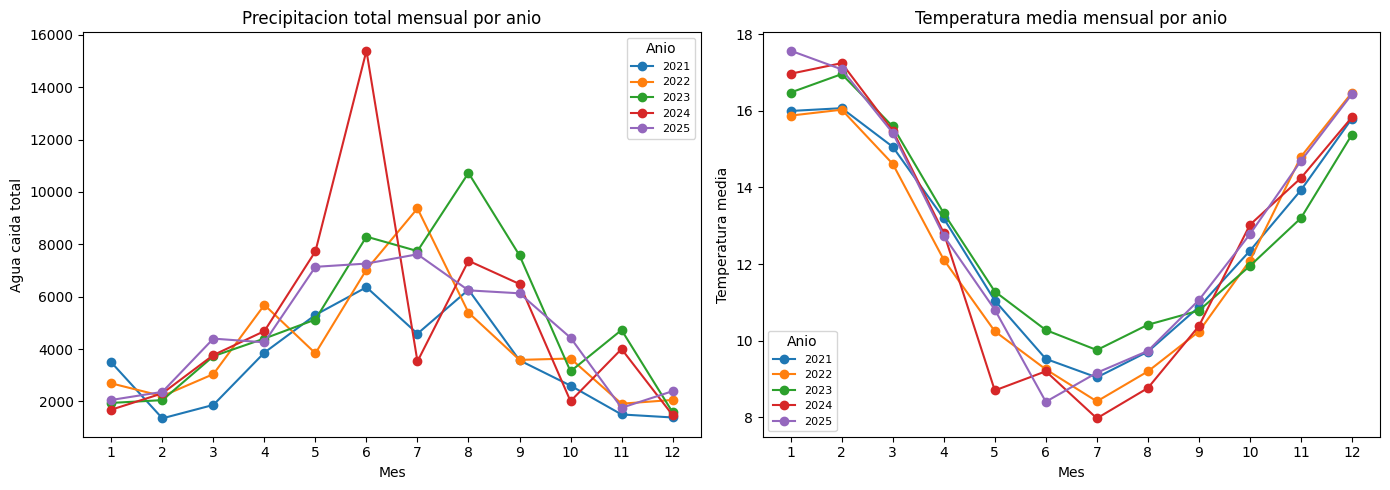

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for anio in anios_disponibles:
    datos_anio = mensual[mensual['anio'] == anio]
    axes[0].plot(datos_anio['mes'], datos_anio['agua_total'], marker='o', label=str(anio))
    axes[1].plot(datos_anio['mes'], datos_anio['temp_media'], marker='o', label=str(anio))

axes[0].set_title('Precipitacion total mensual por anio')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Agua caida total')

axes[1].set_title('Temperatura media mensual por anio')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Temperatura media')

for ax in axes:
    ax.set_xticks(meses)
    ax.legend(title='Anio', fontsize=8)

plt.tight_layout()
plt.show()

**Analisis mensual por anio:**

Separar las lineas por anio permite comparar si la estacionalidad se repite o cambia entre 2021, 2022, 2023, 2024 y 2025. Esta vista es mas trazable que un promedio general por mes, porque muestra diferencias interanuales y evita ocultar anios con comportamientos particulares.

In [47]:
por_anio_mes = mensual[[
    'anio', 'mes', 'agua_promedio', 'agua_total', 'temp_media'
]].copy()

display(por_anio_mes.head(12))

,anio,mes,agua_promedio,agua_total,temp_media
0,2021,1,1.136755,3488.700008,15.997605
1,2021,2,0.487807,1352.200013,16.070437
2,2021,3,0.607690,1865.000009,15.061290
3,2021,4,1.305815,3862.600017,13.189892
4,2021,5,1.745359,5302.400018,11.045425
5,2021,6,2.163299,6360.100009,9.521667
6,2021,7,1.508986,4584.300021,9.038381
7,2021,8,2.061949,6264.200012,9.709875
8,2021,9,1.213673,3568.200012,10.879048
9,2021,10,0.868938,2601.600013,12.344840


**Analisis de tabla anio-mes:**

La tabla deja trazable la agregacion usada para los graficos siguientes. Al conservar `anio` y `mes` por separado, se evita mezclar todos los a?os en un promedio unico y se puede comparar la estacionalidad de cada periodo.

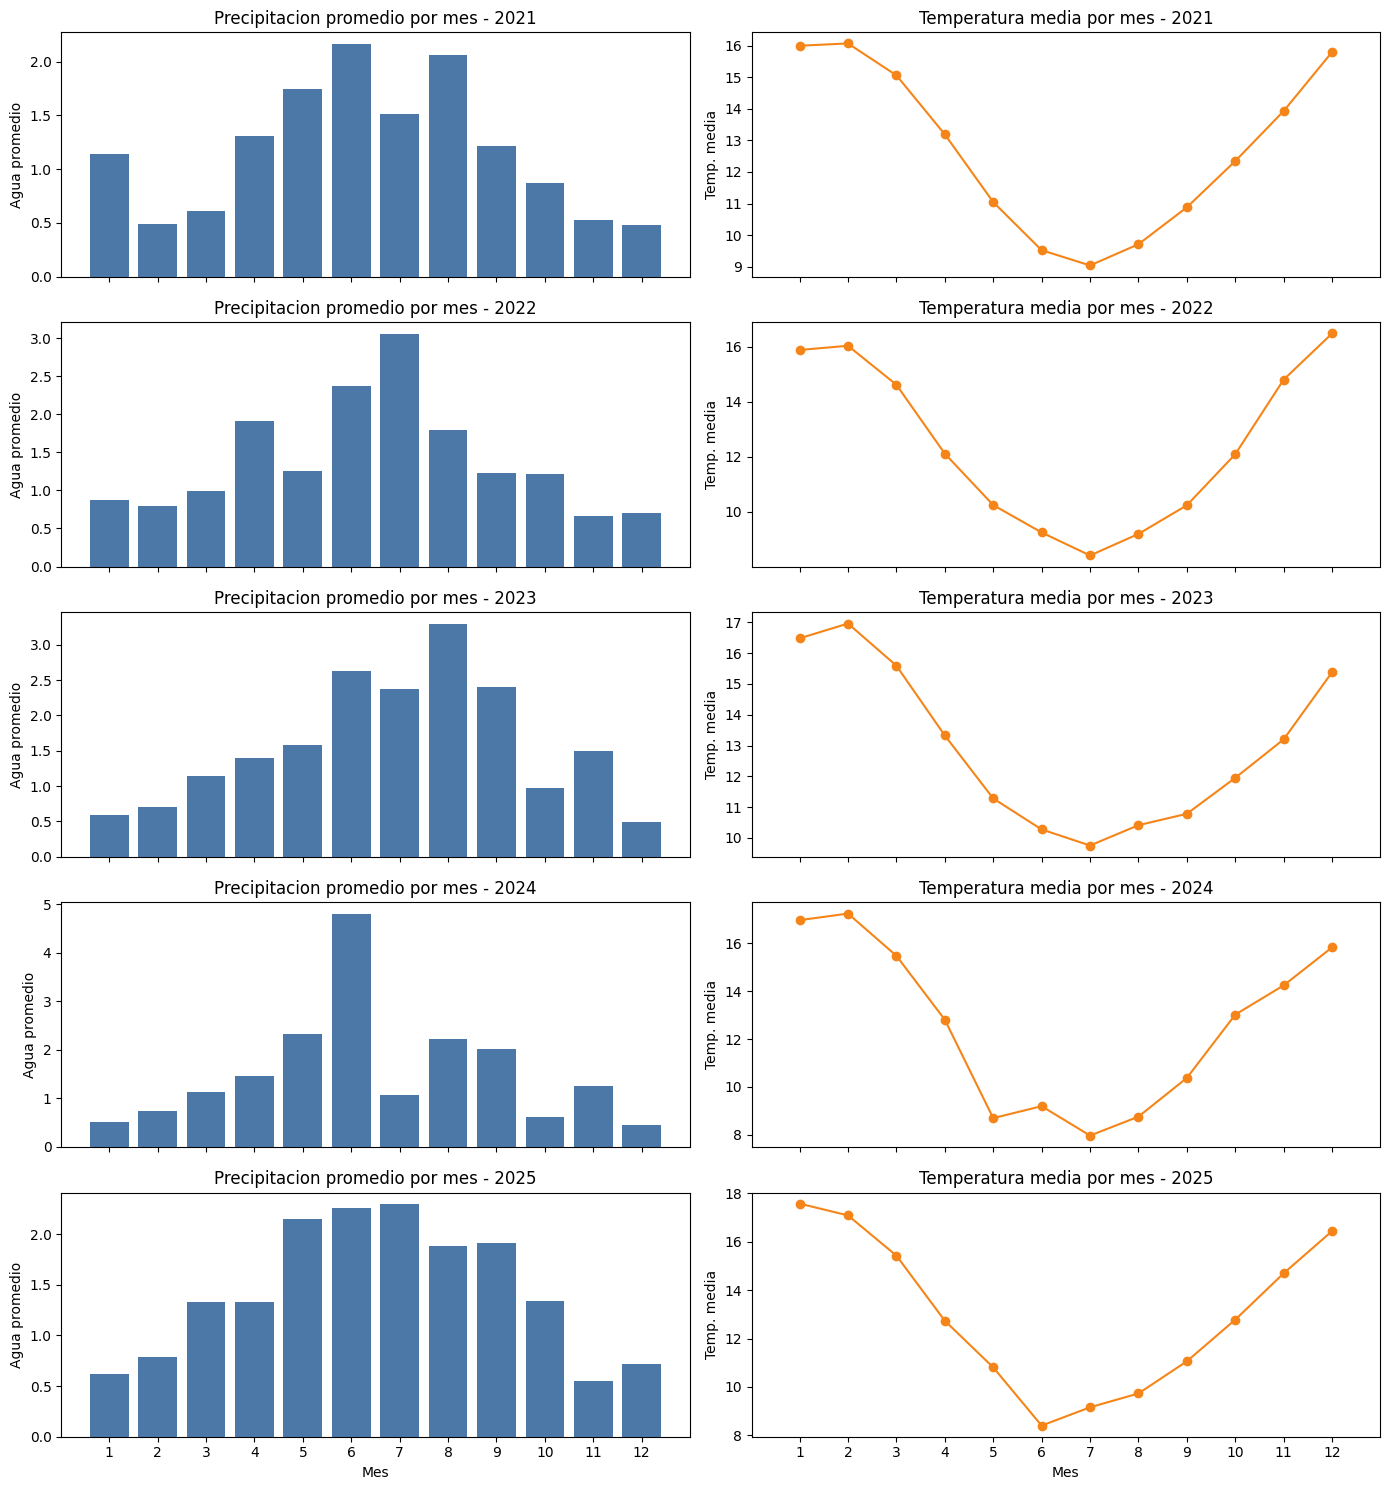

In [48]:
fig, axes = plt.subplots(len(anios_disponibles), 2, figsize=(14, 3 * len(anios_disponibles)), sharex=True)

for fila, anio in enumerate(anios_disponibles):
    datos_anio = por_anio_mes[por_anio_mes['anio'] == anio]
    axes[fila, 0].bar(datos_anio['mes'], datos_anio['agua_promedio'], color='#4c78a8')
    axes[fila, 0].set_title(f'Precipitacion promedio por mes - {anio}')
    axes[fila, 0].set_ylabel('Agua promedio')

    axes[fila, 1].plot(datos_anio['mes'], datos_anio['temp_media'], marker='o', color='#f58518')
    axes[fila, 1].set_title(f'Temperatura media por mes - {anio}')
    axes[fila, 1].set_ylabel('Temp. media')

for ax in axes[-1, :]:
    ax.set_xlabel('Mes')
for ax in axes.ravel():
    ax.set_xticks(meses)

plt.tight_layout()
plt.show()

**Analisis por mes y anio:**

Los paneles muestran la estacionalidad mensual dentro de cada anio. Esto permite observar si los meses lluviosos y los meses mas calidos se mantienen consistentes entre anios o si existen variaciones relevantes que puedan influir en los modelos predictivos.

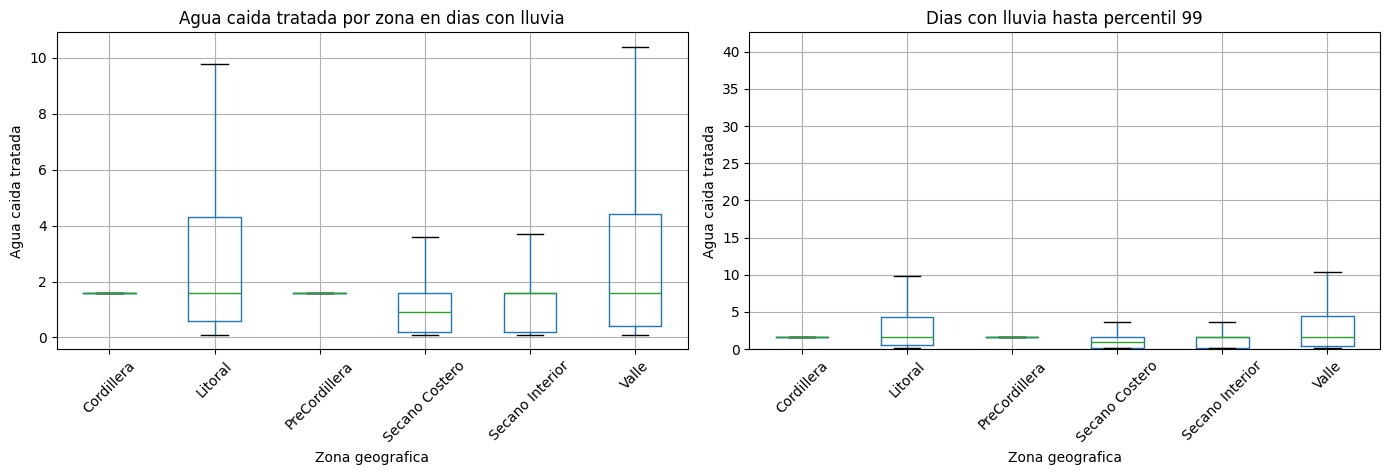

In [49]:
df_zona_lluvia = df_eda[df_eda['agua_caida_tratada'] > 0]
limite_visual_zona = df_zona_lluvia['agua_caida_tratada'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_zona_lluvia.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[0], rot=45, showfliers=False)
axes[0].set_title('Agua caida tratada por zona en dias con lluvia')
axes[0].set_xlabel('Zona geografica')
axes[0].set_ylabel('Agua caida tratada')

df_zona_lluvia.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[1], rot=45, showfliers=False)
axes[1].set_title('Dias con lluvia hasta percentil 99')
axes[1].set_xlabel('Zona geografica')
axes[1].set_ylabel('Agua caida tratada')
axes[1].set_ylim(0, limite_visual_zona)

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por zona en dias con lluvia:**

Al graficar solo dias con lluvia, la dispersion entre zonas se vuelve mas interpretable. La vista al percentil 99 mantiene escala normal y evita depender de transformaciones de escala.

In [50]:
columnas_scatter = ['latitud', 'altura', 'temp_media', 'agua_caida_tratada']
muestra_scatter = df_eda[columnas_scatter].dropna().sample(
    n=min(6000, df_eda[columnas_scatter].dropna().shape[0]),
    random_state=42
)


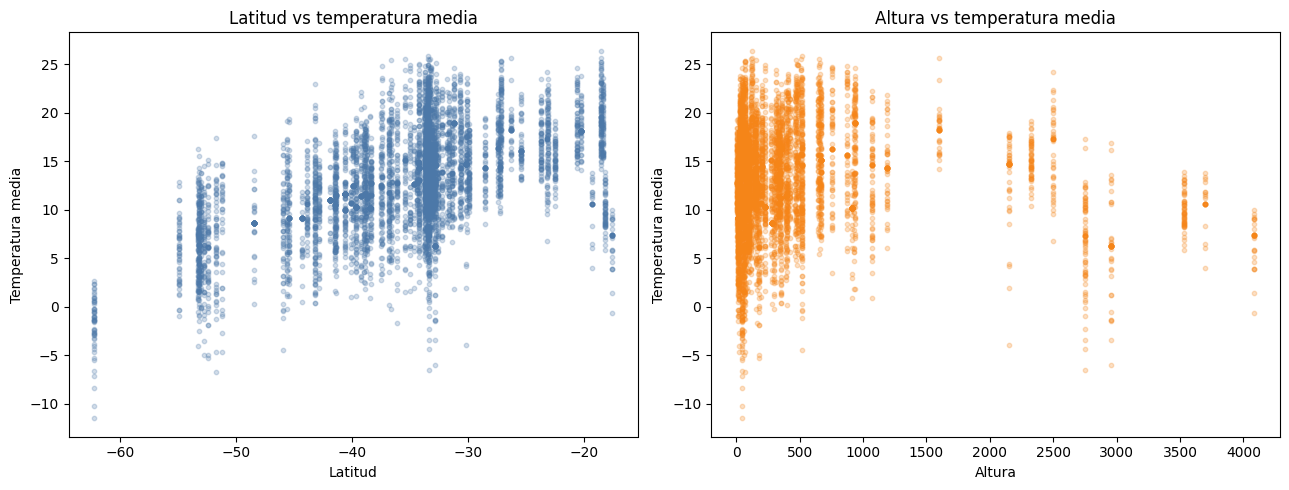

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(muestra_scatter['latitud'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#4c78a8')
axes[0].set_title('Latitud vs temperatura media')
axes[0].set_xlabel('Latitud')
axes[0].set_ylabel('Temperatura media')

axes[1].scatter(muestra_scatter['altura'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#f58518')
axes[1].set_title('Altura vs temperatura media')
axes[1].set_xlabel('Altura')
axes[1].set_ylabel('Temperatura media')

plt.tight_layout()
plt.show()


**Analisis geografico y temperatura:**

Los scatter plots muestran relacion entre ubicacion, altura y temperatura media. Estos patrones apoyan el uso de variables geograficas en modelos predictivos.

In [52]:
estaciones_geo = df_eda.groupby(['codigo_estacion', 'nombre_estacion']).agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media=('temp_media', 'mean')
).reset_index()


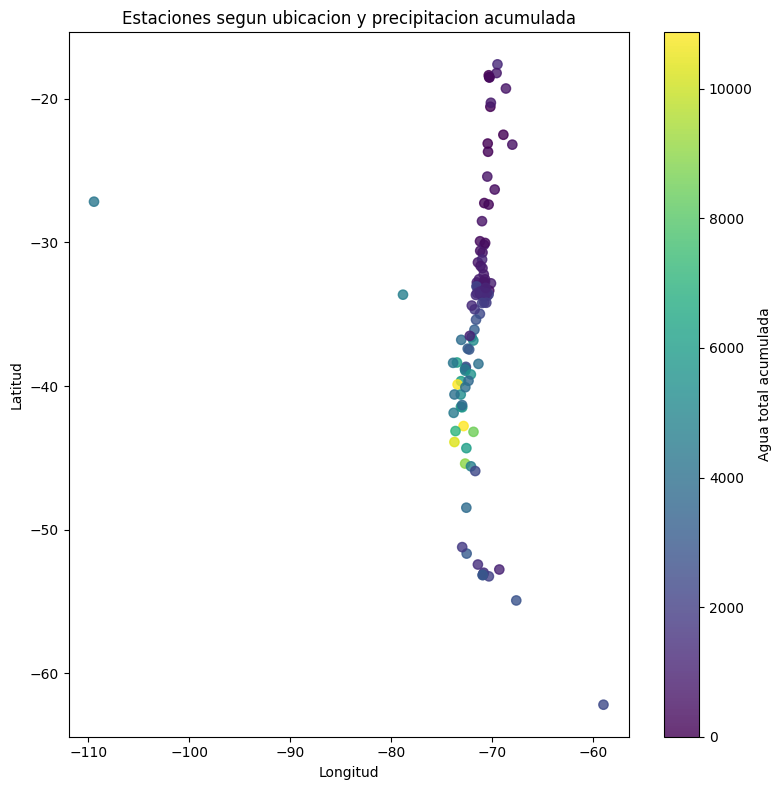

In [53]:
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    estaciones_geo['longitud'],
    estaciones_geo['latitud'],
    c=estaciones_geo['agua_total'],
    s=45,
    cmap='viridis',
    alpha=0.8
)
ax.set_title('Estaciones segun ubicacion y precipitacion acumulada')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.colorbar(scatter, ax=ax, label='Agua total acumulada')
plt.tight_layout()
plt.show()


**Analisis de estaciones:**

El grafico geografico permite ubicar estaciones y observar donde se acumula mayor precipitacion. Esta vista ayuda a interpretar diferencias territoriales y posibles sesgos de cobertura.

**Patrones detectados inicialmente:**

Los graficos temporales permiten observar estacionalidad: las precipitaciones y temperaturas cambian segun el mes. Los boxplots por zona muestran diferencias territoriales y tambien confirman la presencia de eventos extremos en precipitacion. Los graficos de latitud y altura ayudan a evaluar la hipotesis de que la ubicacion geografica influye en la temperatura. El grafico geografico de estaciones permite visualizar si la lluvia acumulada se concentra en ciertas areas del pais.


## 2.8 Nuevas variables a partir de analisis

A partir del entendimiento inicial se crean variables que facilitan el analisis y el futuro modelamiento. Estas variables traducen informacion climatica y temporal a formatos mas utiles para regresion, clasificacion y clustering.

| Nueva variable | Descripcion | Uso esperado |
|---|---|---|
| `llueve` | 1 si `agua_caida_tratada > 0`, 0 si no | Clasificacion binaria |
| `lluvia_intensa` | 1 si `agua_caida_tratada` supera el percentil 90 de los dias con lluvia | Deteccion/clasificacion de lluvia alta no extrema |
| `rango_termico` | `temp_max - temp_min` | Analisis de variabilidad termica |
| `estacion_anio` | Verano, otono, invierno, primavera | Analisis estacional |
| `mes_sin`, `mes_cos` | Representacion ciclica del mes | Modelos con comportamiento anual |


In [54]:
umbral_lluvia_intensa = df_eda.loc[df_eda['agua_caida_tratada'] > 0, 'agua_caida_tratada'].quantile(0.90)

def obtener_estacion_anio(mes):
    if mes in [12, 1, 2]:
        return 'Verano'
    if mes in [3, 4, 5]:
        return 'Otono'
    if mes in [6, 7, 8]:
        return 'Invierno'
    return 'Primavera'


In [55]:
df_eda['rango_termico'] = df_eda['temp_max'] - df_eda['temp_min']
df_eda['estacion_anio'] = df_eda['mes'].apply(obtener_estacion_anio)
df_eda['mes_sin'] = np.sin(2 * np.pi * df_eda['mes'] / 12)
df_eda['mes_cos'] = np.cos(2 * np.pi * df_eda['mes'] / 12)

# Isoterma cero: altura del nivel de congelamiento (0C) usando gradiente termico estandar 6.5C/km.
# Variable fisica que correlaciona mejor con la lluvia que cualquier variable termica individual.
df_eda['isoterma_cero'] = df_eda['altura'] + (df_eda['temp_media'] / 6.5) * 1000

# Lags temporales de lluvia: capturan la memoria del fenomeno (si llovio ayer, hoy es mas probable).
# Se ordena por estacion y fecha; solo usan dias PASADOS (shift), por lo que no generan fuga.
df_eda = df_eda.sort_values(['codigo_estacion', 'fecha']).reset_index(drop=True)
serie_lluvia = df_eda.groupby('codigo_estacion')['agua_caida_tratada']
df_eda['lluvia_ayer'] = serie_lluvia.shift(1)
df_eda['lluvia_prom_7d'] = serie_lluvia.shift(1).rolling(7, min_periods=1).mean().reset_index(0, drop=True)
df_eda['lluvia_acum_3d'] = serie_lluvia.shift(1).rolling(3, min_periods=1).sum().reset_index(0, drop=True)

df_eda['llueve'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    (df_eda['agua_caida_tratada'] > 0).astype(int)
)
df_eda['lluvia_intensa'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    (df_eda['agua_caida_tratada'] >= umbral_lluvia_intensa).astype(int)
)

**Analisis de nuevas variables:**

Ademas de `llueve`, `lluvia_intensa` y `rango_termico`, se crean dos grupos de variables de alto valor predictivo: `isoterma_cero` (altura del nivel de congelamiento, estimada con el gradiente termico 6.5C/km) y los lags de lluvia (`lluvia_ayer`, `lluvia_prom_7d`, `lluvia_acum_3d`), que capturan la memoria temporal del fenomeno. Al inicio de la serie de cada estacion no existe dia previo, por lo que esos lags se imputan con `0` ("sin lluvia previa conocida") en lugar de la mediana global: imputar con mediana inyectaria lluvia donde no hay informacion y degradaria la regresion. `mes_cos` representa la estacionalidad; `mes_sin` se calcula pero se excluye del modelado por su correlacion casi nula con la lluvia.

**Incorporacion de un segundo dataset (variables atmosfericas):**

Ademas de las variables derivadas, se incorpora un **segundo dataset de reanalisis (NASA POWER)** con el estado atmosferico diario por estacion: humedad relativa, velocidad y direccion del viento (codificada de forma ciclica en seno/coseno por ser angular), radiacion solar y presion. Estas variables -que la red EMA de la DMC mide pero solo publica en tiempo real, no en su historico- gobiernan si un dia concreto llueve y cuanto, por lo que son candidatas de alto valor para la regresion diaria. La lluvia objetivo sigue siendo la **medida** por la DMC; el reanalisis solo aporta predictores. Por tratarse de un producto con control de calidad, no presenta los errores groseros del CSV principal y no requiere tratamiento de outliers: solo se revisan nulos. A continuacion se ven sus estadisticos, nulos y su correlacion con la precipitacion (su finalidad eficaz).

In [56]:
# Segundo dataset atmosferico (reanalisis NASA POWER): carga y union a df_eda por estacion y fecha.
# Raw del dataset atmosferico en el repo de datos:
ATMOS_URL = 'https://raw.githubusercontent.com/4mnesia/DataMining_Datos/refs/heads/main/atmosfera_diario.csv'
df_atmosfera = pd.read_csv(ATMOS_URL, parse_dates=['fecha'])
df_atmosfera['codigo_estacion'] = df_atmosfera['codigo_estacion'].astype(int)

# Variables atmosfericas del dia. 'nasa_precip' (precipitacion modelada del reanalisis) se trata
# aparte como predictor de apoyo (es una estimacion independiente, no la lluvia medida que es el target).
columnas_atmosfericas = ['humedad', 'viento_vel', 'viento_dir_sin', 'viento_dir_cos', 'radiacion',
                         'radiacion_lw', 'indice_claridad', 'presion', 'nubosidad', 'rocio', 'hum_especifica']
columnas_atmos_union = columnas_atmosfericas + ['nasa_precip', 'nasa_temp']

df_eda['codigo_estacion'] = df_eda['codigo_estacion'].astype(int)
df_eda = df_eda.merge(
    df_atmosfera[['codigo_estacion', 'fecha'] + columnas_atmos_union],
    on=['codigo_estacion', 'fecha'], how='left'
).sort_values(['codigo_estacion', 'fecha']).reset_index(drop=True)

# Lags atmosfericos: estado del dia anterior por estacion (solo pasado, sin fuga)
for _c in ['humedad', 'nubosidad', 'presion', 'radiacion']:
    df_eda[_c + '_ayer'] = df_eda.groupby('codigo_estacion')[_c].shift(1)
columnas_atmosfericas_lag = ['humedad_ayer', 'nubosidad_ayer', 'presion_ayer', 'radiacion_ayer']

# Estadisticos y nulos
resumen_atmosfera = df_eda[columnas_atmosfericas].describe().T[['mean', 'std', 'min', 'max']].round(2)
resumen_atmosfera['nulos'] = df_eda[columnas_atmosfericas].isna().sum().values
display(resumen_atmosfera)

# Finalidad eficaz: correlacion absoluta de cada variable atmosferica con la lluvia diaria
correlacion_atmosfera = (
    df_eda[columnas_atmosfericas + ['nasa_precip', 'agua_caida_tratada']].corr()['agua_caida_tratada']
    .drop('agua_caida_tratada').abs().sort_values(ascending=False)
    .to_frame('correlacion_abs_con_lluvia').round(3)
)
display(correlacion_atmosfera)

,mean,std,min,max,nulos
humedad,62.51,23.17,1.52,100.00,0
viento_vel,3.57,2.05,0.45,20.43,0
viento_dir_sin,-0.45,0.56,-1.00,1.00,0
viento_dir_cos,-0.12,0.69,-1.00,1.00,0
radiacion,17.84,9.43,0.22,36.68,0
radiacion_lw,26.36,3.19,14.80,36.61,0
indice_claridad,0.58,0.18,0.05,0.87,106
presion,93.32,8.75,60.78,103.52,0
nubosidad,54.71,30.16,0.07,100.00,106
rocio,3.41,7.24,-33.22,22.85,0


,correlacion_abs_con_lluvia
nasa_precip,0.438
indice_claridad,0.382
viento_dir_cos,0.280
nubosidad,0.276
radiacion,0.274
humedad,0.245
viento_vel,0.105
radiacion_lw,0.089
rocio,0.088
presion,0.078


**Analisis del dataset atmosferico:**

Las variables atmosfericas quedan unidas a cada registro diario por estacion y fecha. La tabla muestra su asociacion con la lluvia (util para la **clasificacion** de `llueve`/`lluvia_intensa`): `nasa_precip`, `indice_claridad`, `nubosidad`, `radiacion` y `humedad` son las mas correlacionadas. Estas mismas variables -mas la temperatura del reanalisis (`nasa_temp`)- alimentan la **regresion de temperatura diaria** (Fase 4.1), que junto con la ubicacion y la estacionalidad permite estimar la temperatura con `R2` alto. La lluvia se mantiene en el proyecto como problema de clasificacion.

## 2.9 Matriz de Correlacion

Luego de crear nuevas variables, se calcula una segunda matriz de correlacion. El objetivo es revisar si las variables derivadas entregan senales adicionales para explicar precipitacion, temperatura o eventos de lluvia.


In [57]:
columnas_correlacion_nuevas = [
    'altura', 'latitud', 'longitud', 'mes', 'mes_sin', 'mes_cos',
    'agua_caida_tratada', 'temp_max', 'temp_min', 'temp_media',
    'rango_termico', 'llueve', 'lluvia_intensa', 'region_cod',
    'zona_geografica_cod', 'macrozona_cod',
    'humedad', 'nubosidad', 'indice_claridad', 'radiacion', 'viento_dir_cos', 'nasa_precip'
]
corr_nuevas = df_eda[columnas_correlacion_nuevas].corr(numeric_only=True)
display(corr_nuevas.round(3))

,altura,latitud,longitud,mes,mes_sin,mes_cos,agua_caida_tratada,temp_max,temp_min,temp_media,...,lluvia_intensa,region_cod,zona_geografica_cod,macrozona_cod,humedad,nubosidad,indice_claridad,radiacion,viento_dir_cos,nasa_precip
altura,1.000,0.393,0.182,-0.002,0.002,-0.001,-0.070,0.073,-0.178,-0.040,...,-0.059,-0.089,-0.184,-0.374,-0.475,-0.226,0.252,0.199,0.129,-0.073
latitud,0.393,1.000,-0.062,-0.002,0.001,-0.001,-0.121,0.524,0.480,0.562,...,-0.079,-0.216,-0.073,-0.947,-0.454,-0.271,0.374,0.356,-0.279,-0.166
longitud,0.182,-0.062,1.000,-0.001,0.001,-0.001,-0.071,-0.081,-0.226,-0.171,...,-0.054,-0.092,0.031,-0.080,-0.162,-0.041,0.033,0.011,-0.007,-0.028
mes,-0.002,-0.002,-0.001,1.000,-0.762,0.205,0.003,-0.124,-0.133,-0.140,...,0.005,0.001,0.000,0.001,0.025,0.099,-0.047,0.045,0.035,-0.009
mes_sin,0.002,0.001,0.001,-0.762,1.000,-0.001,-0.041,0.256,0.250,0.286,...,-0.035,-0.001,-0.002,-0.000,-0.092,-0.172,0.135,0.141,-0.089,-0.021
mes_cos,-0.001,-0.001,-0.001,0.205,-0.001,1.000,-0.117,0.408,0.338,0.439,...,-0.098,0.001,-0.001,0.001,-0.172,-0.237,0.321,0.775,-0.185,-0.110
agua_caida_tratada,-0.070,-0.121,-0.071,0.003,-0.041,-0.117,1.000,-0.198,-0.028,-0.132,...,0.815,-0.037,-0.002,0.145,0.245,0.276,-0.382,-0.274,0.280,0.438
temp_max,0.073,0.524,-0.081,-0.124,0.256,0.408,-0.198,1.000,0.569,0.895,...,-0.148,-0.010,0.250,-0.482,-0.608,-0.514,0.577,0.683,-0.307,-0.205
temp_min,-0.178,0.480,-0.226,-0.133,0.250,0.338,-0.028,0.569,1.000,0.856,...,-0.010,-0.120,-0.119,-0.455,-0.095,-0.036,0.137,0.386,-0.234,-0.047
temp_media,-0.040,0.562,-0.171,-0.140,0.286,0.439,-0.132,0.895,0.856,1.000,...,-0.092,-0.067,0.079,-0.525,-0.417,-0.339,0.426,0.630,-0.306,-0.146


**Analisis de segunda matriz de correlacion:**

La segunda matriz permite revisar el efecto de variables nuevas como `llueve`, `lluvia_intensa`, `rango_termico` y codificaciones territoriales. Esto conecta la exploracion con el modelamiento posterior.

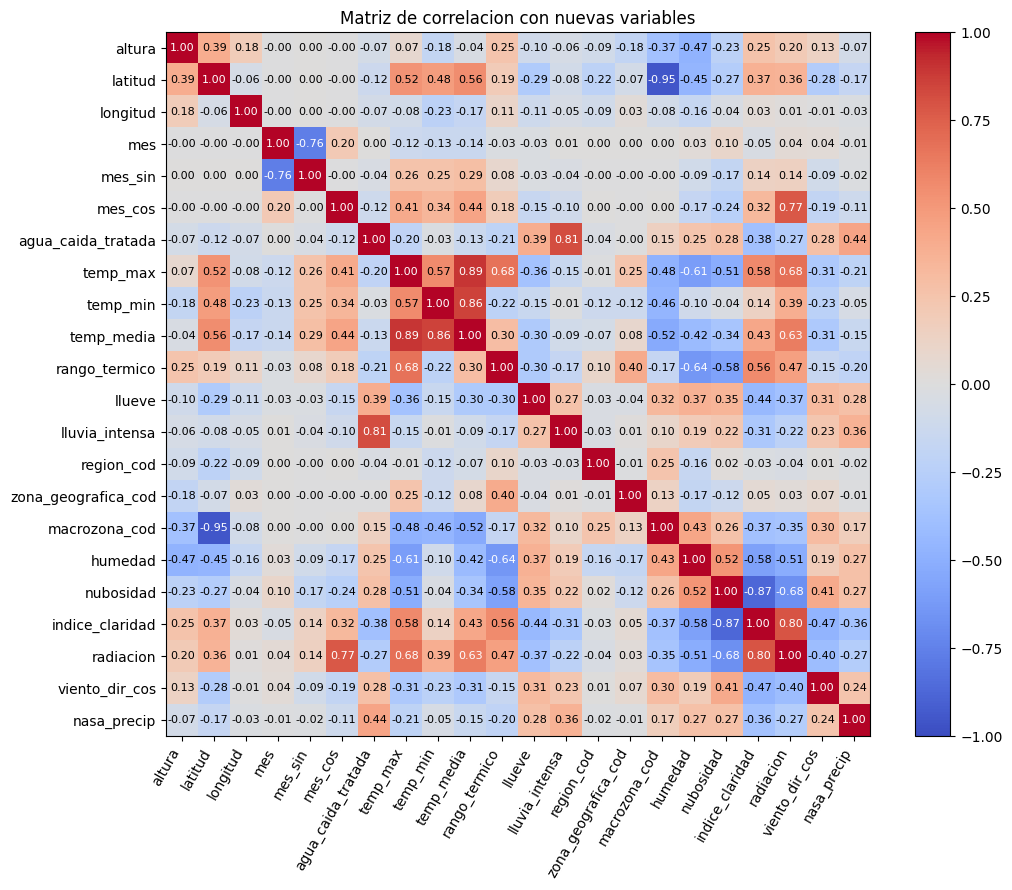

In [58]:
graficar_matriz_correlacion(
    corr_nuevas,
    'Matriz de correlacion con nuevas variables',
    figsize=(12, 9),
    rotacion=60
)


**Analisis de correlacion con nuevas variables:**

La segunda matriz integra variables originales, derivadas y atmosfericas. Las atmosfericas del segundo dataset (`nasa_precip`, `indice_claridad`, `nubosidad`, `radiacion`, `humedad`) se asocian con la lluvia, lo que es util para la **clasificacion** de dias lluviosos; y junto con la temperatura del reanalisis (`nasa_temp`) y la ubicacion alimentan la **regresion de temperatura** (Fase 4.1). Las correlaciones lineales individuales son moderadas, pero combinadas en modelos no lineales explican bien el comportamiento climatico.

## 2.10 Patrones/comportamientos detectados con nuevas variables

Con las nuevas variables se analizan patrones mas cercanos al futuro modelamiento: dias con lluvia, lluvia intensa, estacionalidad y relaciones entre variables climaticas. Tambien se incluye una visualizacion tipo pairplot para observar relaciones combinadas entre variables.


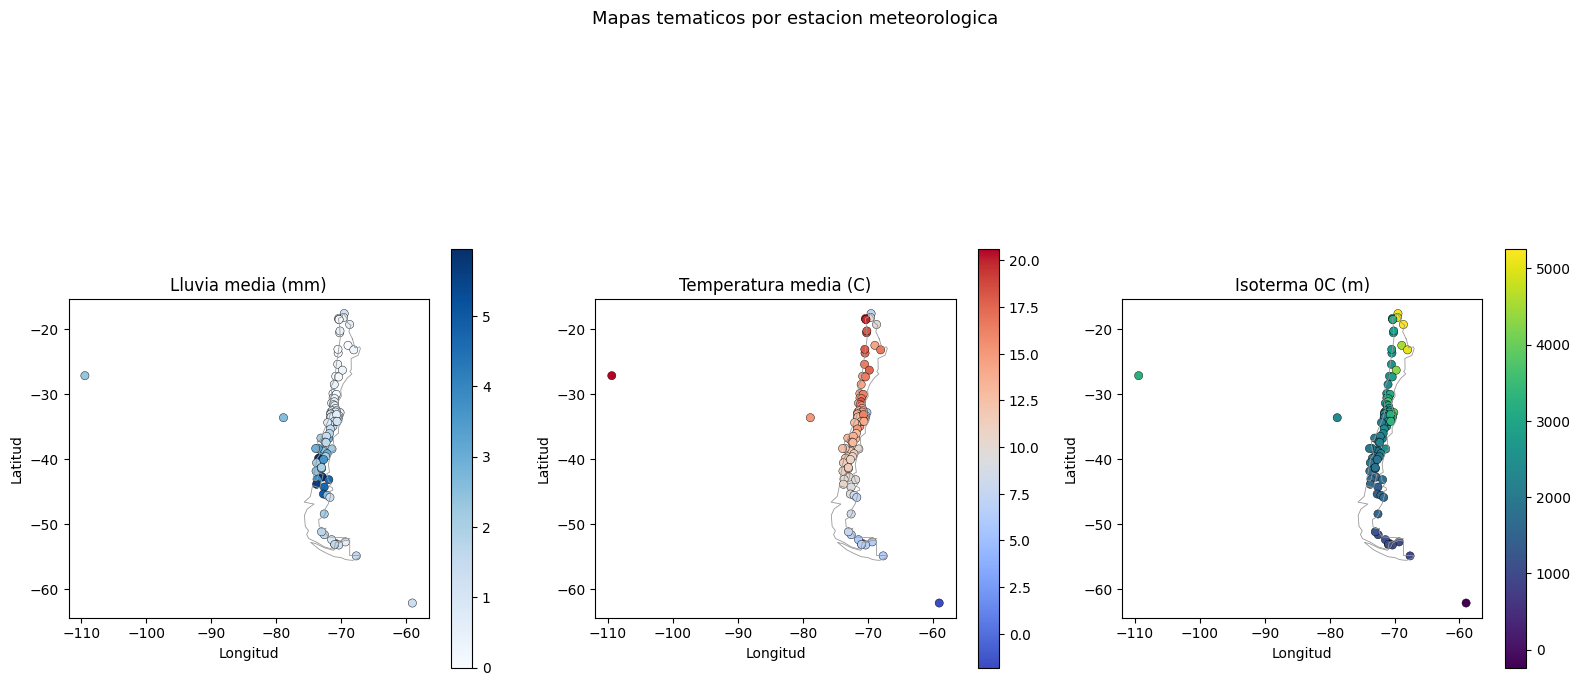

In [59]:
estaciones_mapa = df_eda.groupby('codigo_estacion').agg(
    latitud=('latitud', 'mean'), longitud=('longitud', 'mean'),
    agua=('agua_caida_tratada', 'mean'), temp=('temp_media', 'mean'),
    isoterma=('isoterma_cero', 'mean')
).dropna()
_geo_mapa = json.loads(descargar_texto(CHILE_GEOJSON))["features"][0]["geometry"]
poligonos_mapa = [_geo_mapa["coordinates"]] if _geo_mapa["type"] == "Polygon" else _geo_mapa["coordinates"]

fig, axes = plt.subplots(1, 3, figsize=(16, 9))
capas = [('agua', 'Lluvia media (mm)', 'Blues'), ('temp', 'Temperatura media (C)', 'coolwarm'), ('isoterma', 'Isoterma 0C (m)', 'viridis')]
for ax, (columna, titulo, cmap) in zip(axes, capas):
    for poligono in poligonos_mapa:
        for anillo in poligono:
            coords = np.array(anillo)
            ax.plot(coords[:, 0], coords[:, 1], color='0.6', linewidth=0.6)
    puntos = ax.scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'],
                        c=estaciones_mapa[columna], cmap=cmap, s=35, edgecolor='black', linewidth=0.3)
    ax.set_title(titulo); ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.set_aspect('equal', adjustable='box')
    plt.colorbar(puntos, ax=ax, shrink=0.5)
fig.suptitle('Mapas tematicos por estacion meteorologica', fontsize=13)
plt.tight_layout()
plt.show()

**Analisis de los mapas tematicos:**

Los mapas muestran el gradiente norte-sur de Chile: la lluvia media aumenta hacia el sur, la temperatura disminuye, y la isoterma cero baja con la latitud. La coherencia espacial de las tres variables confirma que la ubicacion geografica y el estado termico son predictores legitimos de la precipitacion.

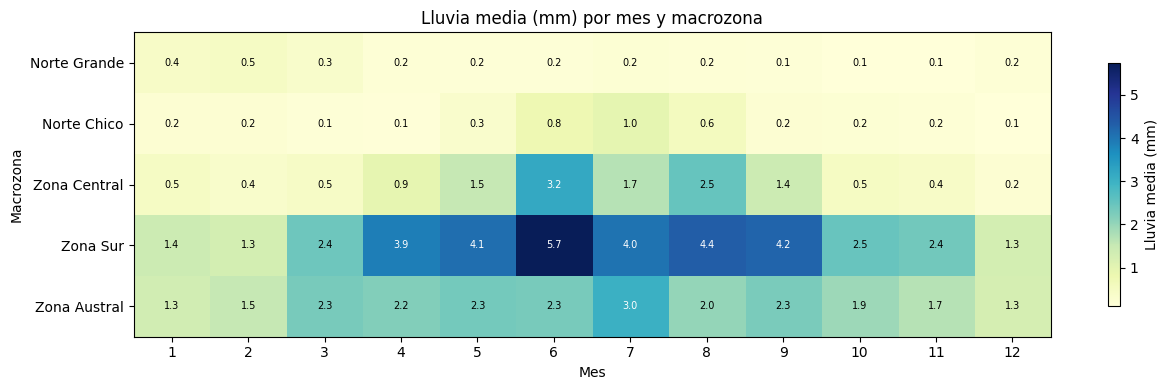

In [60]:
pivote_mes_macro = df_eda.pivot_table(
    values='agua_caida_tratada', index='macrozona', columns='mes', aggfunc='mean', observed=True
)
fig, ax = plt.subplots(figsize=(13, 4))
imagen = ax.imshow(pivote_mes_macro.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels(range(1, 13))
ax.set_yticks(range(len(pivote_mes_macro.index))); ax.set_yticklabels(list(pivote_mes_macro.index))
for (fila, columna), valor in np.ndenumerate(pivote_mes_macro.values):
    ax.text(columna, fila, f'{valor:.1f}', ha='center', va='center', fontsize=7,
            color='black' if valor < np.nanmax(pivote_mes_macro.values)/2 else 'white')
ax.set_title('Lluvia media (mm) por mes y macrozona')
ax.set_xlabel('Mes'); ax.set_ylabel('Macrozona')
plt.colorbar(imagen, ax=ax, shrink=0.8, label='Lluvia media (mm)')
plt.tight_layout()
plt.show()

**Analisis de estacionalidad por macrozona:**

El heatmap confirma el patron climatico de Chile: la Zona Sur y Austral concentran lluvia durante todo el ano con maximos invernales (meses 5-8), la Zona Central tiene un regimen marcadamente invernal, y el Norte Grande/Chico se mantiene seco casi todo el ano. Esto respalda las hipotesis H1 (variacion territorial) y H2 (estacionalidad).

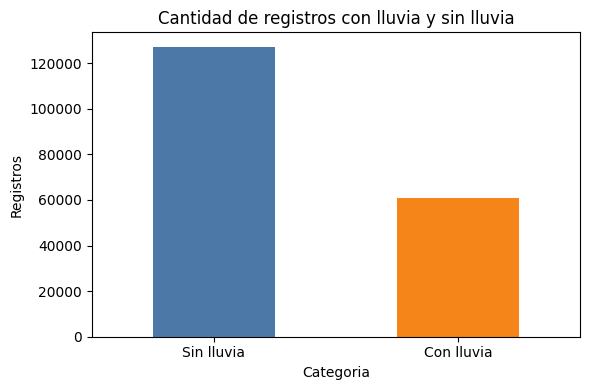

In [61]:
conteo_lluvia = df_eda['llueve'].map({0: 'Sin lluvia', 1: 'Con lluvia'}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
conteo_lluvia.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518'])
ax.set_title('Cantidad de registros con lluvia y sin lluvia')
ax.set_xlabel('Categoria')
ax.set_ylabel('Registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Analisis de balance de lluvia (cero-inflacion y predictibilidad):**

La clase `Sin lluvia` es mayoritaria (~2/3 de los registros). Consecuencias:

- **Clasificacion:** la accuracy engaña por el desbalance; se usan precision, recall y F1.
- **Regresion:** estimar el milimetraje diario es dificil con solo ubicacion y temperatura porque depende del **estado atmosferico del dia** (humedad, viento, presion, radiacion), que el dataset original de la DMC no trae en su historico. Por eso se incorpora un **segundo dataset atmosferico** (reanalisis NASA POWER, Fase 3) con esas variables por estacion y dia. Esto aproximadamente duplica el `R2` diario (ver Fase 5), confirmando que buena parte del "ruido" diario era senal atmosferica faltante.

In [62]:
lluvia_intensa_region = df_eda[df_eda['lluvia_intensa'] == 1].groupby('nombre_region').size().sort_values()
lluvia_intensa_zona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('zona_geografica').size().sort_values()
lluvia_intensa_macrozona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('macrozona', observed=True).size()


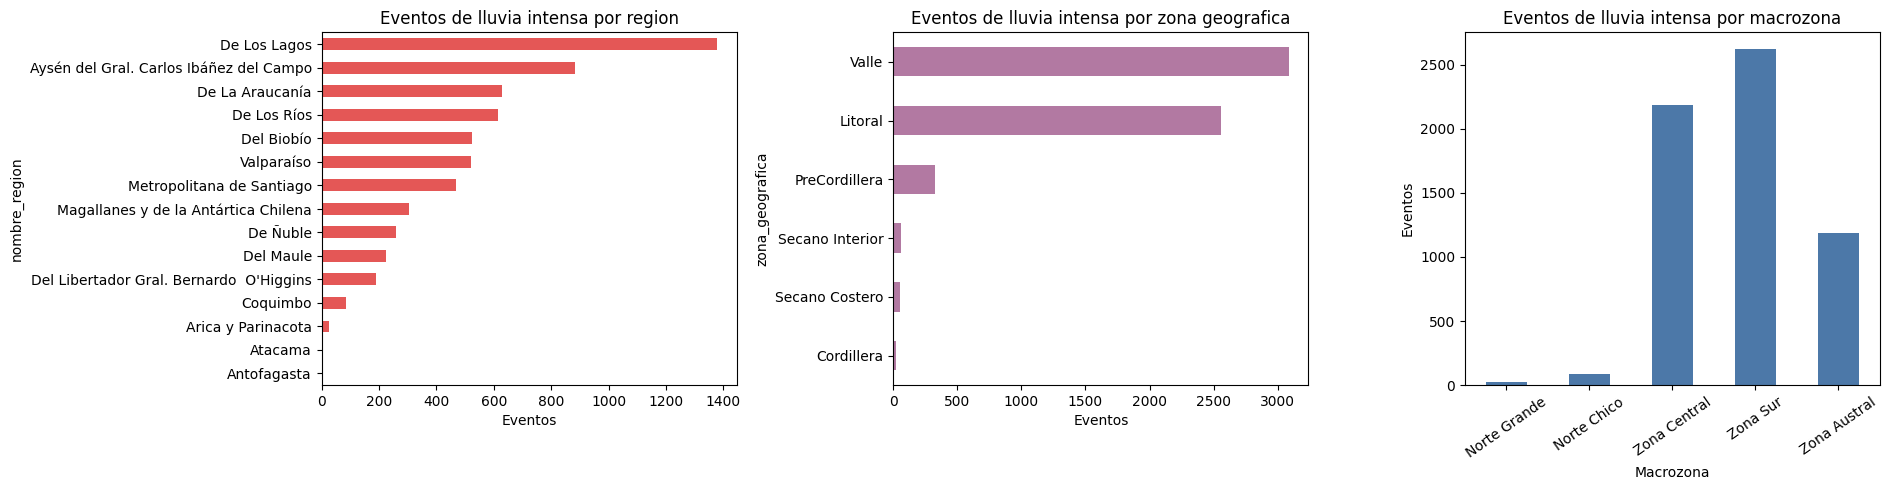

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

lluvia_intensa_region.plot(kind='barh', ax=axes[0], color='#e45756')
axes[0].set_title('Eventos de lluvia intensa por region')
axes[0].set_xlabel('Eventos')

lluvia_intensa_zona.plot(kind='barh', ax=axes[1], color='#b279a2')
axes[1].set_title('Eventos de lluvia intensa por zona geografica')
axes[1].set_xlabel('Eventos')

lluvia_intensa_macrozona.plot(kind='bar', ax=axes[2], color='#4c78a8')
axes[2].set_title('Eventos de lluvia intensa por macrozona')
axes[2].set_xlabel('Macrozona')
axes[2].set_ylabel('Eventos')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Analisis de lluvia intensa:**

Los eventos intensos son menos frecuentes y se concentran territorialmente. Esto anticipa un problema de clasificacion desbalanceado, donde recall y F1 son mas informativos que accuracy sola.

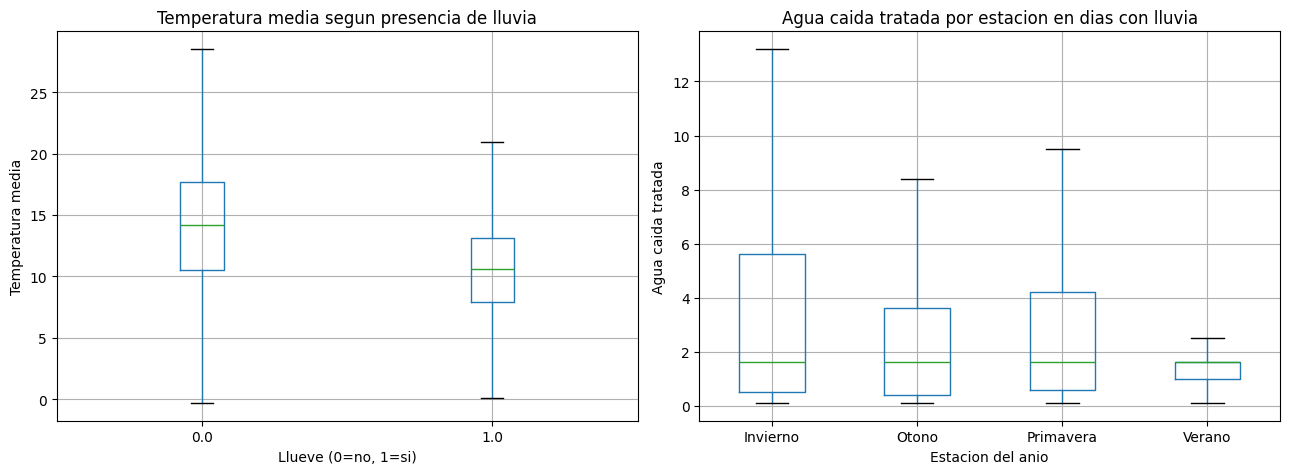

In [64]:
df_lluvia_positiva = df_eda[df_eda['agua_caida_tratada'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_eda.boxplot(column='temp_media', by='llueve', ax=axes[0], showfliers=False)
axes[0].set_title('Temperatura media segun presencia de lluvia')
axes[0].set_xlabel('Llueve (0=no, 1=si)')
axes[0].set_ylabel('Temperatura media')

df_lluvia_positiva.boxplot(column='agua_caida_tratada', by='estacion_anio', ax=axes[1], showfliers=False)
axes[1].set_title('Agua caida tratada por estacion en dias con lluvia')
axes[1].set_xlabel('Estacion del anio')
axes[1].set_ylabel('Agua caida tratada')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis comparativo de clases:**

La lluvia se asocia a diferencias de temperatura y estacionalidad. Estos patrones justifican usar variables climaticas y temporales para clasificar presencia de lluvia o lluvia intensa.

In [65]:
variables_pairplot = ['isoterma_cero', 'lluvia_prom_7d', 'temp_max', 'latitud', 'rango_termico']
muestra_pairplot = df_eda[variables_pairplot + ['llueve']].dropna().sample(
    n=min(3000, df_eda[variables_pairplot + ['llueve']].dropna().shape[0]),
    random_state=42
).copy()
muestra_pairplot['llueve'] = muestra_pairplot['llueve'].map({0: 'No llueve', 1: 'Llueve'})

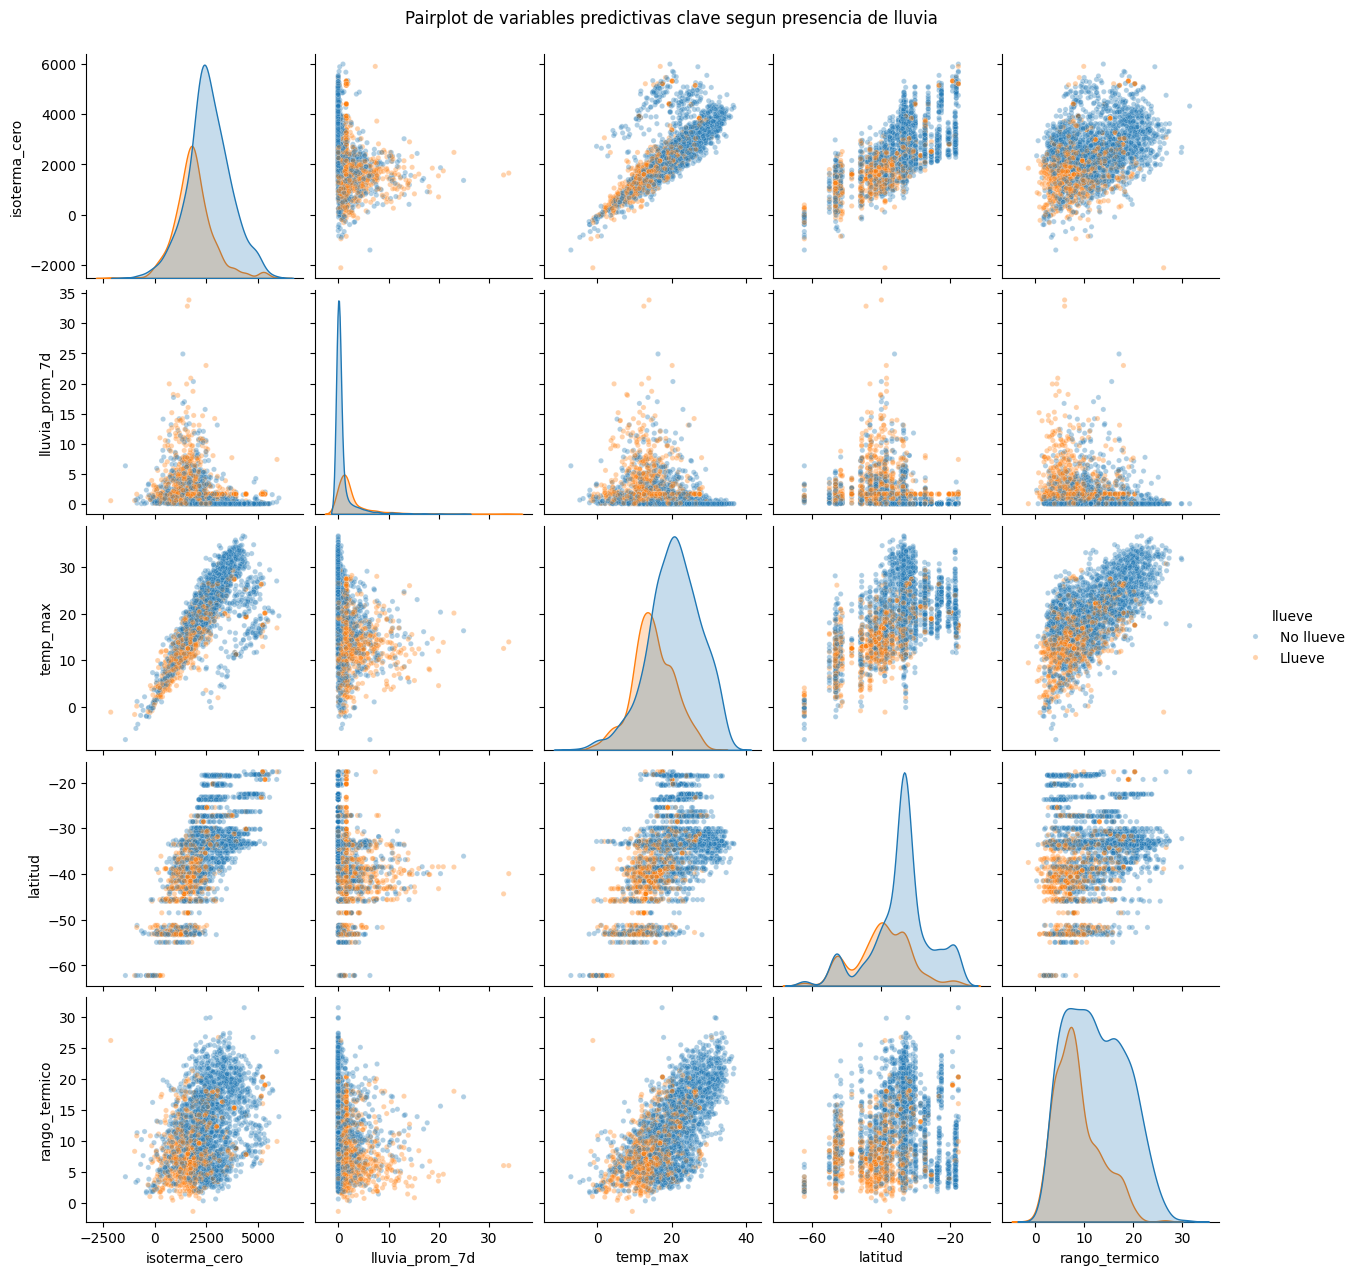

In [66]:
if SEABORN_DISPONIBLE:
    grafico_pairplot = sns.pairplot(
        muestra_pairplot,
        vars=variables_pairplot,
        hue='llueve',
        diag_kind='kde',
        plot_kws={'alpha': 0.35, 's': 14}
    )
    grafico_pairplot.fig.suptitle('Pairplot de variables predictivas clave segun presencia de lluvia', y=1.02)
    plt.show()
else:
    colores = np.where(muestra_pairplot['llueve'] == 'Llueve', '#f58518', '#4c78a8')
    scatter_matrix(
        muestra_pairplot[variables_pairplot],
        figsize=(12, 12), diagonal='kde', color=colores, alpha=0.35
    )
    plt.suptitle('Scatter matrix de variables predictivas clave', y=0.92)
    plt.show()

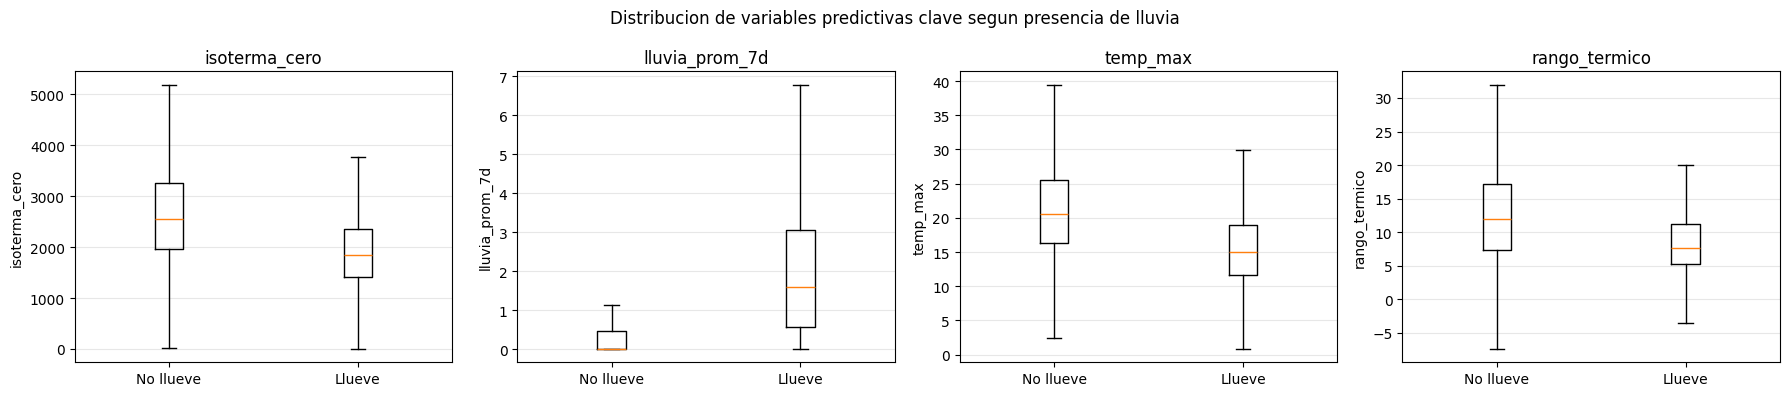

In [67]:
variables_box = ['isoterma_cero', 'lluvia_prom_7d', 'temp_max', 'rango_termico']
fig, axes = plt.subplots(1, len(variables_box), figsize=(18, 4))
for ax, var in zip(axes, variables_box):
    datos_box = [
        df_eda.loc[df_eda['llueve'] == 0, var].dropna(),
        df_eda.loc[df_eda['llueve'] == 1, var].dropna()
    ]
    ax.boxplot(datos_box, showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No llueve', 'Llueve'])
    ax.set_title(var)
    ax.set_ylabel(var)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Distribucion de variables predictivas clave segun presencia de lluvia')
plt.tight_layout()
plt.show()

**Analisis de los boxplots por presencia de lluvia:**

Los boxplots confirman que las variables predictivas separan los dias con y sin lluvia: en dias lluviosos la isoterma cero es mas baja (aire mas frio), el rango termico se reduce (cielo nublado) y la lluvia de los dias previos es mayor. Esto respalda que estas variables aporten senal real a los modelos de clasificacion.

**Analisis de patrones con nuevas variables:**

Las variables derivadas permiten observar el problema desde una perspectiva mas util para mineria de datos. La variable `llueve` separa el dataset en dos clases, mientras que `lluvia_intensa` permite estudiar eventos poco frecuentes. Los boxplots comparan condiciones termicas y estacionales. La visualizacion tipo pairplot ayuda a detectar relaciones no evidentes entre lluvia, temperatura, rango termico, altura y latitud.


## Cierre de Fase 2

En esta fase se corrigio la carga del dataset, se identificaron tipos de variables, nulos, outliers, transformaciones iniciales, estadisticos basicos, correlaciones y patrones. Tambien se crearon nuevas variables que conectan el analisis exploratorio con las siguientes fases del proyecto.

Decisiones principales para continuar:

1. Usar `dataset_precipitaciones_temperaturas_chile.csv` como fuente principal.
2. Mantener outliers climaticos marcados, conservando el dato original.
3. Usar `agua_caida_tratada` para analisis y modelamiento cuando los extremos altos distorsionen los resultados.
4. Usar `llueve` y `lluvia_intensa` para modelos de clasificacion.
5. Regresion sobre `temp_media` (temperatura diaria, predecible); la lluvia se modela como clasificacion (`llueve` / `lluvia_intensa`).
6. Usar variables agregadas por estacion para clustering en fases posteriores.

La siguiente fase corresponde a **Transformacion**, donde se prepararan los datos para modelamiento mediante imputacion, encoding y escalamiento.


# 3. Transformacion / Preparacion de Datos

Esta fase convierte el analisis exploratorio en una base preparada para modelamiento. La transformacion integra zonas climaticas Koppen-Geiger oficiales asignadas por coordenadas, variables territoriales, imputacion simple, encoding y escalamiento, conservando trazabilidad entre los datos originales y las variables finales.


## 3.1 Zonas climaticas Koppen-Geiger oficiales

In [68]:
def leer_leyenda_koppen(url_leyenda):
    leyenda = {}
    patron = re.compile(r'\s*(\d+):\s+([A-Z][A-Za-z]{1,2})\s+(.+?)\s+\[')
    for linea in descargar_texto(url_leyenda, encoding='utf-8', errores='replace').splitlines():
        coincidencia = patron.match(linea)
        if coincidencia:
            valor = int(coincidencia.group(1))
            codigo = coincidencia.group(2)
            descripcion = coincidencia.group(3).strip()
            leyenda[valor] = {'codigo': codigo, 'descripcion': descripcion}
    return leyenda


def extraer_koppen_por_coordenada(raster, leyenda, longitud, latitud, radio_maximo=5):
    escala = raster.tag_v2.get(33550)
    referencia = raster.tag_v2.get(33922)
    origen_x, origen_y = referencia[3], referencia[4]
    pixel_x, pixel_y = escala[0], escala[1]
    ancho, alto = raster.size

    columna = int((longitud - origen_x) / pixel_x)
    fila = int((origen_y - latitud) / pixel_y)
    if not (0 <= columna < ancho and 0 <= fila < alto):
        return {'zona_koppen_valor': 0, 'zona_koppen_codigo': 'Sin dato', 'zona_koppen_descripcion': 'Fuera del raster', 'zona_koppen_radio_px': np.nan}

    valor = int(raster.getpixel((columna, fila)))
    radio_usado = 0

    if valor == 0:
        for radio in range(1, radio_maximo + 1):
            encontrado = False
            for delta_y in range(-radio, radio + 1):
                for delta_x in range(-radio, radio + 1):
                    if abs(delta_x) != radio and abs(delta_y) != radio:
                        continue
                    columna_vecina = columna + delta_x
                    fila_vecina = fila + delta_y
                    if 0 <= columna_vecina < ancho and 0 <= fila_vecina < alto:
                        valor_vecino = int(raster.getpixel((columna_vecina, fila_vecina)))
                        if valor_vecino != 0:
                            valor = valor_vecino
                            radio_usado = radio
                            encontrado = True
                            break
                if encontrado:
                    break
            if encontrado:
                break

    clase = leyenda.get(valor, {'codigo': 'Sin dato', 'descripcion': 'Sin clasificacion disponible'})
    return {
        'zona_koppen_valor': valor,
        'zona_koppen_codigo': clase['codigo'],
        'zona_koppen_descripcion': clase['descripcion'],
        'zona_koppen_radio_px': radio_usado if valor != 0 else np.nan
    }


Image.MAX_IMAGE_PIXELS = None
leyenda_koppen = leer_leyenda_koppen(KOPPEN_LEGEND)
raster_koppen = Image.open(io.BytesIO(descargar_bytes(KOPPEN_TIF)))

estaciones_koppen = df_eda[[
    'codigo_estacion', 'nombre_estacion', 'nombre_region',
    'zona_geografica', 'latitud', 'longitud', 'altura'
]].drop_duplicates('codigo_estacion').copy()

asignaciones_koppen = estaciones_koppen.apply(
    lambda fila: pd.Series(extraer_koppen_por_coordenada(
        raster_koppen,
        leyenda_koppen,
        fila['longitud'],
        fila['latitud']
    )),
    axis=1
).reset_index(drop=True)

estaciones_koppen = pd.concat([estaciones_koppen.reset_index(drop=True), asignaciones_koppen], axis=1)
estaciones_koppen['zona_koppen'] = estaciones_koppen['zona_koppen_codigo'] + ' - ' + estaciones_koppen['zona_koppen_descripcion']

columnas_koppen = ['zona_koppen_valor', 'zona_koppen_codigo', 'zona_koppen_descripcion', 'zona_koppen_radio_px', 'zona_koppen', 'zona_koppen_cod']
df_eda = df_eda.drop(columns=[columna for columna in columnas_koppen if columna in df_eda.columns])
df_eda = df_eda.merge(
    estaciones_koppen[['codigo_estacion'] + columnas_koppen[:-1]],
    on='codigo_estacion',
    how='left'
)
df_eda['zona_koppen_cod'] = df_eda['zona_koppen_codigo'].astype('category').cat.codes

resumen_koppen = df_eda['zona_koppen'].value_counts().rename_axis('zona_koppen').to_frame('registros')
resumen_asignacion_koppen = pd.DataFrame([
    {'indicador': 'estaciones clasificadas', 'valor': estaciones_koppen['zona_koppen_codigo'].ne('Sin dato').sum()},
    {'indicador': 'estaciones sin clasificacion', 'valor': estaciones_koppen['zona_koppen_codigo'].eq('Sin dato').sum()},
    {'indicador': 'zonas Koppen-Geiger presentes', 'valor': estaciones_koppen['zona_koppen_codigo'].nunique()},
    {'indicador': 'asignaciones por pixel exacto', 'valor': estaciones_koppen['zona_koppen_radio_px'].eq(0).sum()},
    {'indicador': 'asignaciones por pixel cercano', 'valor': estaciones_koppen['zona_koppen_radio_px'].gt(0).sum()},
])

auditoria_koppen = estaciones_koppen[
    estaciones_koppen['zona_koppen_radio_px'].fillna(-1).gt(0) |
    estaciones_koppen['zona_koppen_codigo'].eq('Sin dato')
][[
    'codigo_estacion', 'nombre_estacion', 'latitud', 'longitud',
    'zona_koppen_codigo', 'zona_koppen_descripcion', 'zona_koppen_radio_px'
]].sort_values(['zona_koppen_radio_px', 'codigo_estacion'])

display(resumen_koppen)
display(resumen_asignacion_koppen)
display(auditoria_koppen)

,registros
zona_koppen,
"Csb - Temperate, dry summer, warm summer",53002
"BSk - Arid, steppe, cold",37823
"Cfb - Temperate, no dry season, warm summer",29788
"BWk - Arid, desert, cold",19851
"Csa - Temperate, dry summer, hot summer",17106
"BWh - Arid, desert, hot",14602
"Cfc - Temperate, no dry season, cold summer",6574
"ET - Polar, tundra",3652
"Af - Tropical, rainforest",1826


,indicador,valor
0,estaciones clasificadas,109
1,estaciones sin clasificacion,0
2,zonas Koppen-Geiger presentes,11
3,asignaciones por pixel exacto,107
4,asignaciones por pixel cercano,2


,codigo_estacion,nombre_estacion,latitud,longitud,zona_koppen_codigo,zona_koppen_descripcion,zona_koppen_radio_px
42,330031,"Juan Fernández, Estación Meteorológica.",-33.63583,-78.83305,Csb,"Temperate, dry summer, warm summer",1
107,550001,"Guardiamarina Zañartu, Pto Williams Ad.",-54.93167,-67.61556,Dfc,"Cold, no dry season, cold summer",1


**Analisis de zonas Koppen-Geiger oficiales:**

La clasificacion queda asignada desde un raster climatologico 1991-2020 de 1 km, usando coordenadas de estaciones. Esta version es mas defendible que una regla por macrozona, porque cada estacion recibe el codigo Koppen-Geiger correspondiente a su ubicacion espacial. Se conserva el codigo oficial, la descripcion, el valor numerico del raster y el radio de busqueda usado para auditar casos costeros o sin dato. Si aparece radio mayor que 0, significa que la coordenada cayo en un pixel sin dato y se uso el pixel climatico valido mas cercano, dejando el caso visible en la tabla de auditoria.

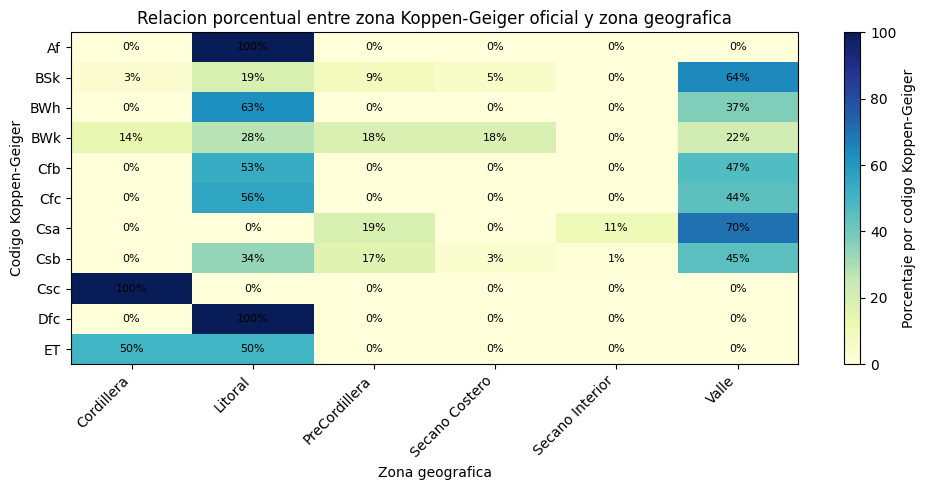

In [69]:
relacion_koppen_zona = pd.crosstab(
    df_eda['zona_koppen_codigo'],
    df_eda['zona_geografica'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(relacion_koppen_zona, cmap='YlGnBu', aspect='auto')
ax.set_title('Relacion porcentual entre zona Koppen-Geiger oficial y zona geografica')
ax.set_xlabel('Zona geografica')
ax.set_ylabel('Codigo Koppen-Geiger')
ax.set_xticks(range(len(relacion_koppen_zona.columns)))
ax.set_xticklabels(relacion_koppen_zona.columns, rotation=45, ha='right')
ax.set_yticks(range(len(relacion_koppen_zona.index)))
ax.set_yticklabels(relacion_koppen_zona.index)
for y in range(relacion_koppen_zona.shape[0]):
    for x in range(relacion_koppen_zona.shape[1]):
        valor = relacion_koppen_zona.iloc[y, x]
        ax.text(x, y, f'{valor:.0f}%', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Porcentaje por codigo Koppen-Geiger')
plt.tight_layout()
plt.show()

**Analisis de relacion Koppen-Geiger y zona geografica:**

La tabla visual permite validar si las zonas climaticas oficiales se concentran en franjas territoriales esperadas. Si una misma zona geografica contiene varios codigos Koppen-Geiger, esto no es un error: indica que la clasificacion climatica captura diferencias locales de temperatura, precipitacion y altura que una categoria territorial amplia no siempre representa.

## 3.2 Mapa climatico y comportamiento anual

In [70]:
def obtener_poligonos_chile(url_geojson):
    geojson = json.loads(descargar_texto(url_geojson, encoding='utf-8'))
    geometria = geojson['features'][0]['geometry']
    if geometria['type'] == 'Polygon':
        return [geometria['coordinates']]
    return geometria['coordinates']


def trazar_chile(ax, poligonos):
    for poligono in poligonos:
        for anillo in poligono:
            coords = np.array(anillo)
            ax.plot(coords[:, 0], coords[:, 1], color='0.55', linewidth=0.8)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_aspect('equal', adjustable='box')

poligonos_chile = obtener_poligonos_chile(CHILE_GEOJSON)

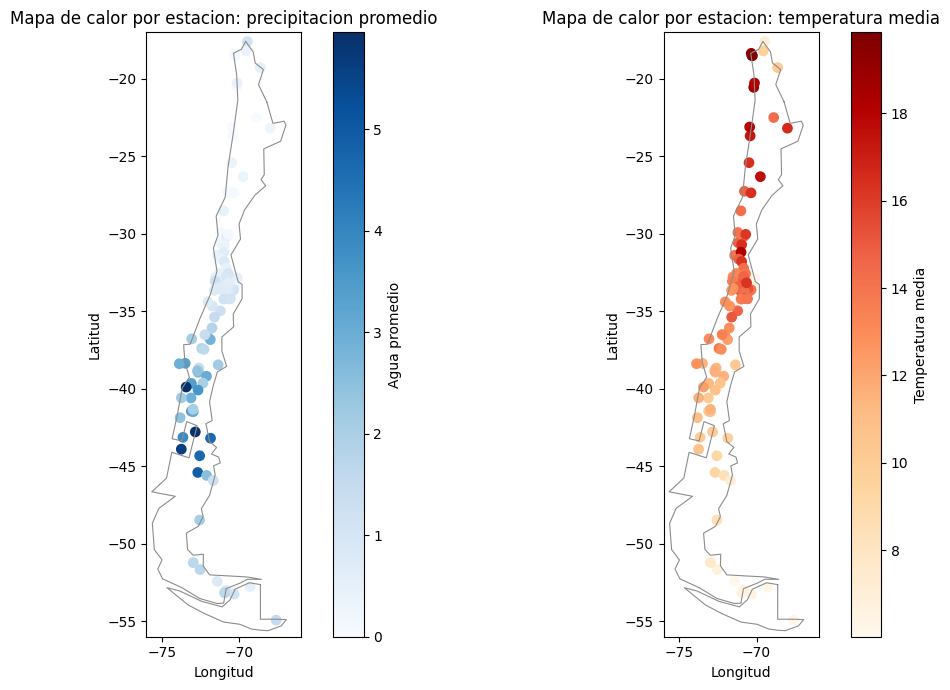

In [71]:
estaciones_mapa = df_eda.groupby('codigo_estacion').agg(
    latitud=('latitud', 'median'),
    longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'),
    agua_promedio=('agua_caida_tratada', 'mean')
).dropna()

estaciones_mapa = estaciones_mapa[
    estaciones_mapa['longitud'].between(-76, -66) &
    estaciones_mapa['latitud'].between(-56, -17)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax in axes:
    trazar_chile(ax, poligonos_chile)
    ax.set_xlim(-76, -66)
    ax.set_ylim(-56, -17)

sc1 = axes[0].scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'], c=estaciones_mapa['agua_promedio'], cmap='Blues', s=45)
axes[0].set_title('Mapa de calor por estacion: precipitacion promedio')
plt.colorbar(sc1, ax=axes[0], label='Agua promedio')

sc2 = axes[1].scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'], c=estaciones_mapa['temp_media'], cmap='OrRd', s=45)
axes[1].set_title('Mapa de calor por estacion: temperatura media')
plt.colorbar(sc2, ax=axes[1], label='Temperatura media')
plt.tight_layout()
plt.show()

**Analisis del mapa climatico:**

El mapa permite observar gradientes territoriales sin convertir el analisis en una visualizacion puramente tabular. La intensidad del color resume el comportamiento promedio por estacion y ayuda a relacionar ubicacion con lluvia y temperatura.

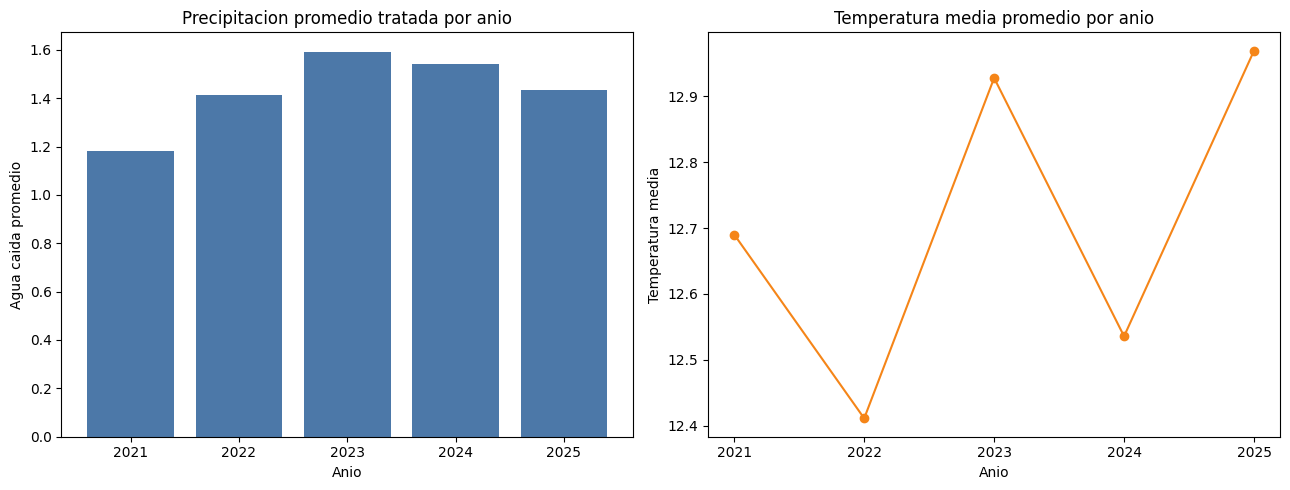

In [72]:
clima_por_anio = df_eda.groupby('anio').agg(
    precipitacion_promedio=('agua_caida_tratada', 'mean'),
    precipitacion_total=('agua_caida_tratada', 'sum'),
    temperatura_promedio=('temp_media', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(clima_por_anio['anio'], clima_por_anio['precipitacion_promedio'], color='#4c78a8')
axes[0].set_title('Precipitacion promedio tratada por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Agua caida promedio')

axes[1].plot(clima_por_anio['anio'], clima_por_anio['temperatura_promedio'], marker='o', color='#f58518')
axes[1].set_title('Temperatura media promedio por anio')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('Temperatura media')
axes[1].set_xticks(clima_por_anio['anio'])
plt.tight_layout()
plt.show()

**Analisis anual:**

La comparacion anual separa el comportamiento promedio de lluvia y temperatura por periodo. Esta lectura evita resumir todo el horizonte 2021-2025 en una sola media y permite identificar anios con comportamiento distinto.

## 3.3 Variables categoricas e insights

In [73]:
variables_categoricas_analisis = [
    'nombre_region', 'zona_geografica', 'macrozona',
    'estacion_anio', 'zona_koppen_codigo'
]

categoricas_codificadas = df_eda[variables_categoricas_analisis + ['llueve', 'lluvia_intensa']].copy()
for columna in variables_categoricas_analisis:
    categoricas_codificadas[f'{columna}_cod'] = categoricas_codificadas[columna].astype('category').cat.codes

columnas_categoricas_cod = [f'{columna}_cod' for columna in variables_categoricas_analisis]
muestra_categoricas = categoricas_codificadas[columnas_categoricas_cod + ['llueve', 'lluvia_intensa']].dropna()
muestra_categoricas = muestra_categoricas.sample(min(2500, len(muestra_categoricas)), random_state=42)

display(muestra_categoricas.head())

,nombre_region_cod,zona_geografica_cod,macrozona_cod,estacion_anio_cod,zona_koppen_codigo_cod,llueve,lluvia_intensa
133771,7,5,3,1,4,1.0,0.0
159014,3,1,4,0,4,1.0,0.0
182192,12,1,4,1,5,1.0,0.0
107888,11,5,2,0,7,0.0,0.0
94761,13,5,2,1,1,0.0,0.0


**Analisis de codificacion categorica:**

La codificacion permite visualizar asociaciones entre categorias dentro de herramientas numericas. Los codigos no representan magnitud ordinal; se usan como soporte grafico para detectar agrupaciones o separaciones entre categorias.

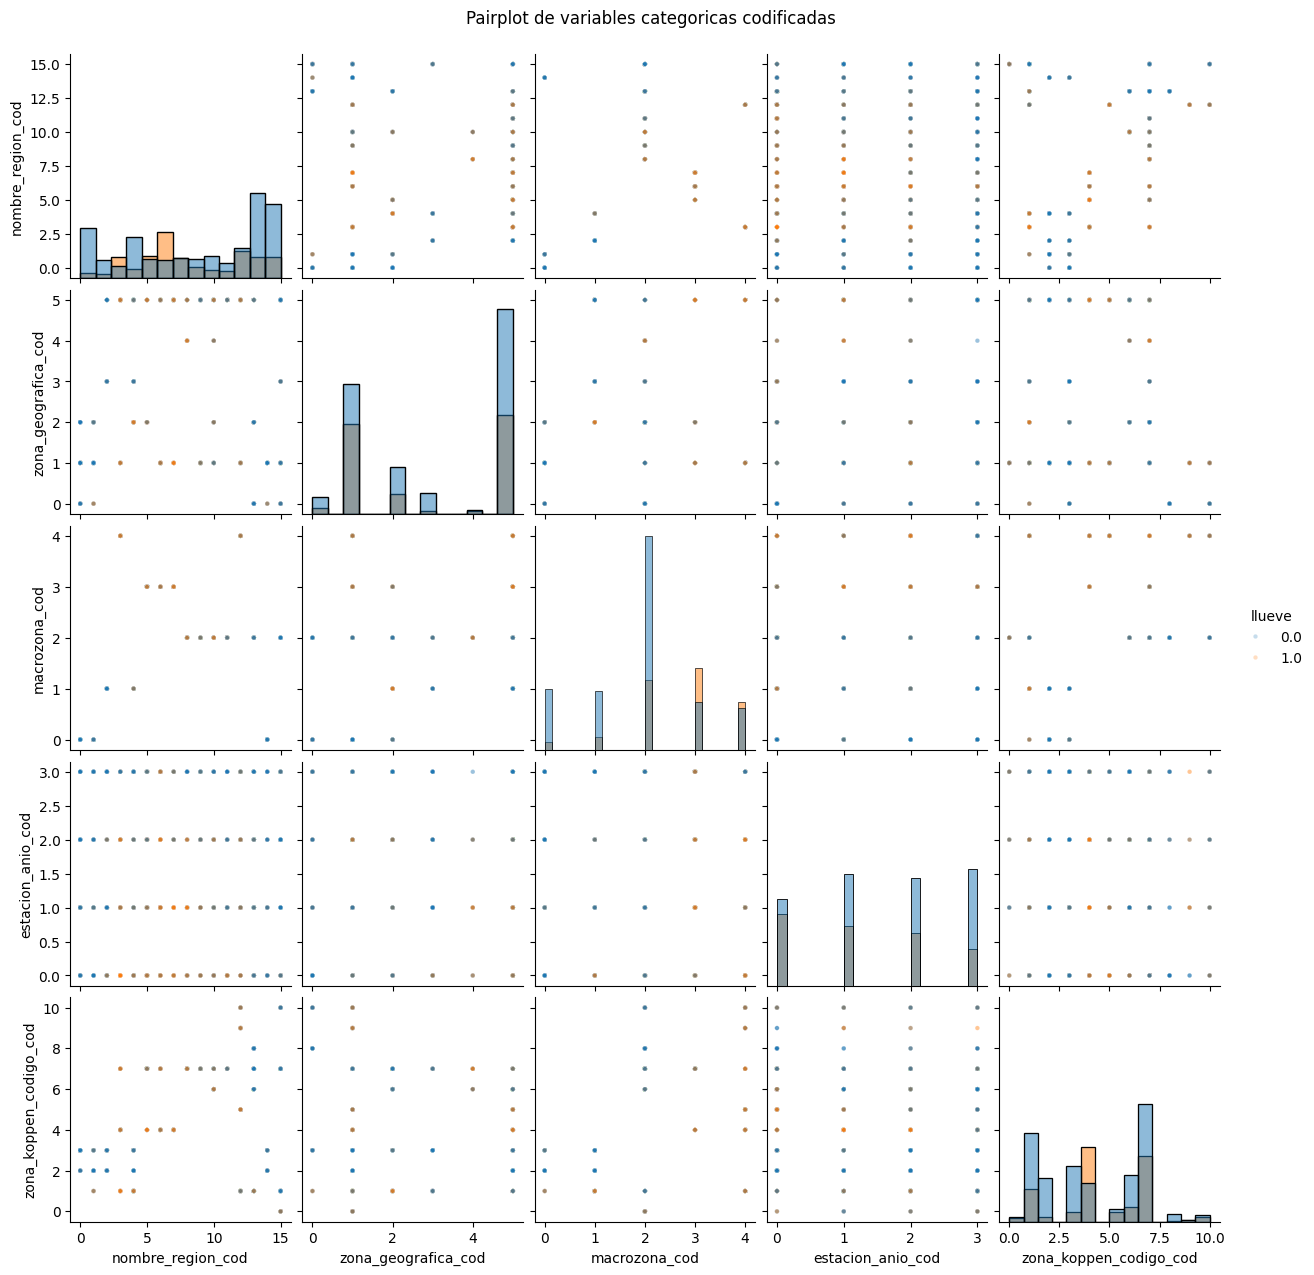

In [74]:
if sns is not None:
    sns.pairplot(
        muestra_categoricas,
        vars=columnas_categoricas_cod,
        hue='llueve',
        diag_kind='hist',
        plot_kws={'alpha': 0.25, 's': 10}
    )
    plt.suptitle('Pairplot de variables categoricas codificadas', y=1.02)
    plt.show()
else:
    scatter_matrix(muestra_categoricas[columnas_categoricas_cod], figsize=(10, 10), diagonal='hist')
    plt.suptitle('Scatter matrix de variables categoricas codificadas', y=0.92)
    plt.show()

**Analisis del pairplot categorico:**

El pairplot permite revisar si las categorias codificadas forman agrupaciones visibles. La interpretacion se centra en separacion y concentracion de puntos, no en relaciones lineales estrictas, porque las variables son categoricas.

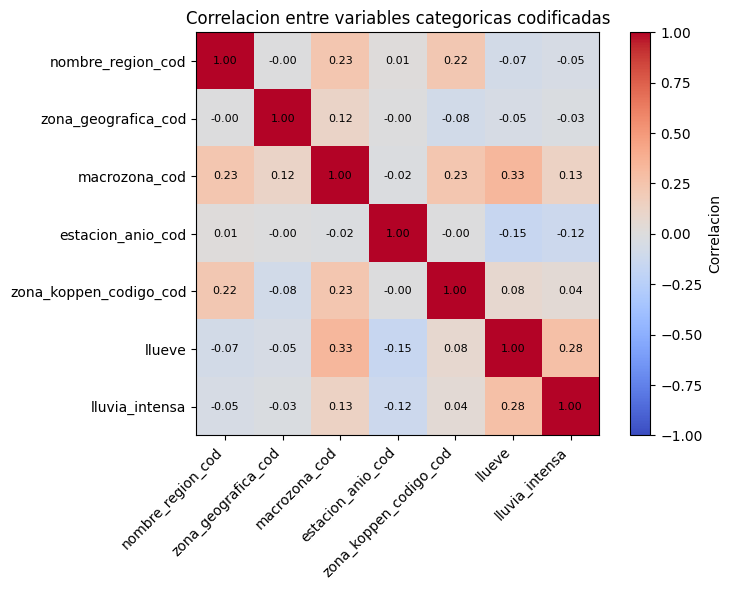

In [75]:
matriz_categorica = muestra_categoricas[columnas_categoricas_cod + ['llueve', 'lluvia_intensa']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_categorica, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlacion entre variables categoricas codificadas')
ax.set_xticks(range(len(matriz_categorica.columns)))
ax.set_xticklabels(matriz_categorica.columns, rotation=45, ha='right')
ax.set_yticks(range(len(matriz_categorica.index)))
ax.set_yticklabels(matriz_categorica.index)
for y in range(matriz_categorica.shape[0]):
    for x in range(matriz_categorica.shape[1]):
        ax.text(x, y, f'{matriz_categorica.iloc[y, x]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Correlacion')
plt.tight_layout()
plt.show()

**Analisis de correlacion categorica:**

La matriz resume asociaciones entre variables categoricas transformadas y objetivos binarios. Los valores sirven como indicio exploratorio de impacto, no como prueba causal, y complementan los graficos territoriales.

## 3.4 Imputacion simple, encoding y variables de alto impacto

Se construye la matriz de predictoras `X` y se definen los objetivos `Y` segun la tarea: **regresion** -> `temp_media` (temperatura diaria, preparada en 3.5/4.1); **clasificacion** -> `llueve` / `lluvia_intensa`. Las variables de precipitacion directa quedan fuera de `X` para evitar fuga.

Pasos clave, todos ajustados **solo con el train** (sin fuga hacia el test):

- **Imputacion simple:** los nulos **numericos** se rellenan con la **mediana del train** y los **categoricos** con la **moda del train**.
- **Encoding one-hot:** las categoricas (`macrozona`, `estacion_anio`, `zona_koppen_codigo`) se convierten en columnas **binarias (0/1)**, una por categoria, sin asumir orden ni jerarquia entre ellas.
- **Variables de alto impacto:** se mide la asociacion de cada predictora con los objetivos para priorizar y justificar su permanencia.

In [76]:
columnas_numericas_base = [
    'altura', 'latitud', 'longitud', 'mes_cos',
    'temp_max', 'temp_min', 'temp_media', 'rango_termico',
    'isoterma_cero', 'lluvia_ayer', 'lluvia_prom_7d', 'lluvia_acum_3d'
]

columnas_categoricas_base = ['macrozona', 'estacion_anio', 'zona_koppen_codigo']

objetivos_supervisados = ['agua_caida_tratada', 'llueve', 'lluvia_intensa']
variables_excluidas_x = ['agua_caida', 'codigo_estacion', 'fecha', 'dia', 'nombre_estacion', 'mes_sin', 'anio', 'mes']

tabla_roles_xy = pd.DataFrame(
    [{'variable': v, 'rol': 'X numerica', 'uso': 'Predictora directa'} for v in columnas_numericas_base] +
    [{'variable': v, 'rol': 'X categorica', 'uso': 'Predictora codificada con one-hot'} for v in columnas_categoricas_base] +
    [{'variable': v, 'rol': 'Y objetivo', 'uso': 'Variable a predecir, no entra como X'} for v in objetivos_supervisados] +
    [{'variable': v, 'rol': 'Excluida de X', 'uso': 'Identificador, fuga, o reemplazada por otra variable'} for v in variables_excluidas_x]
)

display(tabla_roles_xy)

,variable,rol,uso
0,altura,X numerica,Predictora directa
1,latitud,X numerica,Predictora directa
2,longitud,X numerica,Predictora directa
3,mes_cos,X numerica,Predictora directa
4,temp_max,X numerica,Predictora directa
5,temp_min,X numerica,Predictora directa
6,temp_media,X numerica,Predictora directa
7,rango_termico,X numerica,Predictora directa
8,isoterma_cero,X numerica,Predictora directa
9,lluvia_ayer,X numerica,Predictora directa


**Analisis de seleccion X/Y:**

La seleccion separa entradas (`X`) y salidas (`Y`). La `X` reune variables geograficas, temporales, termicas y atmosfericas. Los objetivos son: para **clasificacion**, `llueve` y `lluvia_intensa`; para **regresion**, la temperatura media diaria (`temp_media`, cuya matriz se construye en 3.5/4.1). Se excluye `agua_caida` de la `X` de clasificacion porque `llueve`/`lluvia_intensa` derivan de ella (fuga), y en la regresion de temperatura se excluyen ademas las variables derivadas de la temperatura del mismo dia.

In [77]:
df_modelo_base = df_eda[columnas_numericas_base + columnas_categoricas_base + objetivos_supervisados + ['anio']].copy()
df_supervisado = df_modelo_base.dropna(subset=objetivos_supervisados).copy()
df_supervisado[['llueve', 'lluvia_intensa']] = df_supervisado[['llueve', 'lluvia_intensa']].astype(int)

# Split TEMPORAL: se entrena con el pasado (2021-2023) y se prueba con el futuro (2024-2025).
# Es lo correcto al usar lags de lluvia y para un problema de pronostico: evita que dias
# consecutivos (muy correlacionados) queden repartidos entre train y test, lo que inflaria
# artificialmente las metricas. El escalador y la imputacion se ajustan solo con train.
predictoras = columnas_numericas_base + columnas_categoricas_base
mascara_train = df_supervisado['anio'] <= 2023
idx_train = df_supervisado.index[mascara_train]
idx_test = df_supervisado.index[~mascara_train]

X_train_base = df_supervisado.loc[idx_train, predictoras].copy()
X_test_base = df_supervisado.loc[idx_test, predictoras].copy()
y_regresion = df_supervisado['agua_caida_tratada']
y_train_regresion = y_regresion.loc[idx_train]
y_test_regresion = y_regresion.loc[idx_test]

resumen_split = pd.DataFrame([
    {'particion': 'Train (2021-2023)', 'registros': len(idx_train), 'pct_lluvia': round(100*df_supervisado.loc[idx_train, 'llueve'].mean(), 1)},
    {'particion': 'Test (2024-2025)', 'registros': len(idx_test), 'pct_lluvia': round(100*df_supervisado.loc[idx_test, 'llueve'].mean(), 1)},
])
display(resumen_split)

,particion,registros,pct_lluvia
0,Train (2021-2023),109666,33.4
1,Test (2024-2025),78210,30.7


**Analisis de separacion train/test:**

La division se realiza antes de imputar y escalar para evitar fuga de informacion. `X_train_base` y `X_test_base` contienen solo variables predictoras. `y_train_regresion` y `y_test_regresion` contienen la respuesta numerica de regresion. Las respuestas de clasificacion (`llueve` y `lluvia_intensa`) se mantienen en `df_supervisado` y se separan con los mismos indices de entrenamiento y prueba en la fase de modelamiento.

In [78]:
medianas_train = X_train_base[columnas_numericas_base].median()
modas_train = X_train_base[columnas_categoricas_base].mode().iloc[0]

X_train_imputado = X_train_base.copy()
X_test_imputado = X_test_base.copy()
X_train_imputado[columnas_numericas_base] = X_train_imputado[columnas_numericas_base].fillna(medianas_train)
X_test_imputado[columnas_numericas_base] = X_test_imputado[columnas_numericas_base].fillna(medianas_train)
X_train_imputado[columnas_categoricas_base] = X_train_imputado[columnas_categoricas_base].fillna(modas_train)
X_test_imputado[columnas_categoricas_base] = X_test_imputado[columnas_categoricas_base].fillna(modas_train)

resumen_imputacion = pd.DataFrame([
    {'grupo': 'numericas', 'criterio': 'mediana de train', 'nulos_train': int(X_train_imputado[columnas_numericas_base].isna().sum().sum())},
    {'grupo': 'categoricas', 'criterio': 'moda de train', 'nulos_train': int(X_train_imputado[columnas_categoricas_base].isna().sum().sum())}
])

display(resumen_imputacion)

,grupo,criterio,nulos_train
0,numericas,mediana de train,0
1,categoricas,moda de train,0


**Analisis de imputacion simple:**

La imputacion simple es trazable y adecuada para una primera preparacion formal. La mediana reduce el efecto de extremos numericos, mientras que la moda conserva la categoria mas representativa sin introducir modelos auxiliares.

In [79]:
X_train_cat = pd.get_dummies(X_train_imputado[columnas_categoricas_base], prefix=columnas_categoricas_base, dtype=int)
X_test_cat = pd.get_dummies(X_test_imputado[columnas_categoricas_base], prefix=columnas_categoricas_base, dtype=int)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

X_train = pd.concat([X_train_imputado[columnas_numericas_base], X_train_cat], axis=1)
X_test = pd.concat([X_test_imputado[columnas_numericas_base], X_test_cat], axis=1)
X_supervisado = pd.concat([X_train, X_test]).sort_index()
columnas_predictoras = list(X_train.columns)

resumen_encoding = pd.DataFrame([
    {'indicador': 'variables numericas', 'valor': len(columnas_numericas_base)},
    {'indicador': 'variables categoricas one-hot', 'valor': X_train_cat.shape[1]},
    {'indicador': 'predictoras finales', 'valor': len(columnas_predictoras)},
    {'indicador': 'nulos finales train', 'valor': int(X_train.isna().sum().sum())}
])

display(resumen_encoding)

,indicador,valor
0,variables numericas,12
1,variables categoricas one-hot,20
2,predictoras finales,32
3,nulos finales train,0


**Analisis de encoding:**

El encoding one-hot convierte cada categoria en columnas binarias, por ejemplo una columna para cada macrozona o codigo Koppen-Geiger. Esto permite que los modelos usen informacion territorial y climatica sin asumir que una categoria es mayor o menor que otra. Despues de esta transformacion, `X_train` y `X_test` representan la version final de las variables predictoras: combinan numericas originales imputadas y categoricas codificadas. Esa matriz final es la que alimenta arboles y, tras escalamiento numerico, tambien regresion lineal, SVM y K-Means.

In [80]:
datos_impacto = X_train.copy()
datos_impacto['agua_caida_tratada'] = y_train_regresion
datos_impacto['llueve'] = df_supervisado.loc[idx_train, 'llueve']
datos_impacto['lluvia_intensa'] = df_supervisado.loc[idx_train, 'lluvia_intensa']

impactos = []
for objetivo in objetivos_supervisados:
    correlaciones = datos_impacto[columnas_predictoras].corrwith(datos_impacto[objetivo]).abs()
    for variable, valor in correlaciones.dropna().items():
        impactos.append({'variable': variable, 'objetivo': objetivo, 'impacto_abs': valor})

impacto_variables = pd.DataFrame(impactos)
impacto_resumen = impacto_variables.groupby('variable')['impacto_abs'].mean().sort_values(ascending=False).head(15)
display(impacto_resumen.to_frame('impacto_promedio'))

,impacto_promedio
variable,
lluvia_ayer,0.292595
lluvia_acum_3d,0.287957
lluvia_prom_7d,0.268953
temp_max,0.237664
rango_termico,0.224971
zona_koppen_codigo_Cfb,0.210732
macrozona_Zona Sur,0.184872
isoterma_cero,0.176819
temp_media,0.175107


**Analisis de variables de alto impacto:**

El ranking resume variables con mayor asociacion exploratoria promedio respecto de lluvia tratada, presencia de lluvia y lluvia intensa. La lectura es de relevancia estadistica preliminar, no de causalidad.

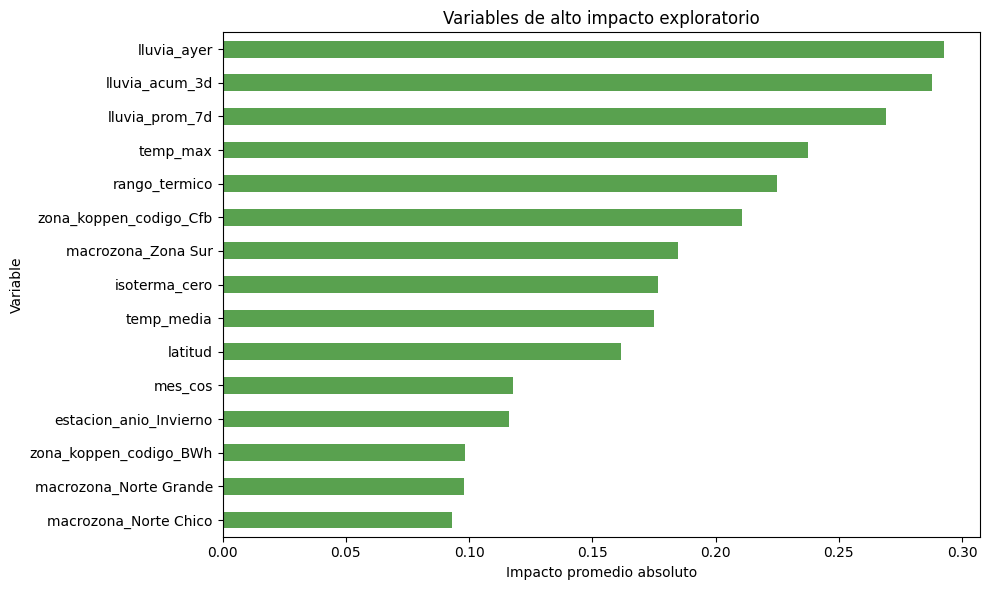

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))
impacto_resumen.sort_values().plot(kind='barh', ax=ax, color='#59a14f')
ax.set_title('Variables de alto impacto exploratorio')
ax.set_xlabel('Impacto promedio absoluto')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

**Analisis del grafico de impacto:**

El grafico permite priorizar variables antes de modelar. Las variables territoriales, climaticas y temporales con mayor impacto entregan una base objetiva para justificar su permanencia en el dataset final.

## 3.5 Escalamiento

El escalamiento lleva las variables numericas a una **escala comparable** con `StandardScaler` (z-score: a cada valor se le resta la **media** de la columna y se divide por su **desviacion estandar**, dejando media 0 y desviacion 1).

**Como se hace (sin fuga):** el escalador se **ajusta solo con el train** (`fit` en train) y luego se **aplica** a train y test (`transform`); nunca se ajusta con el test.

**Que se escala y por que:** solo las columnas **numericas** (las one-hot 0/1 se dejan igual). El escalamiento es necesario para modelos basados en **distancia o margen** -`SVR`/`SVM` y `K-Means`-, sensibles a la magnitud de las variables; **los arboles no lo necesitan** (deciden por umbrales) y la regresion lineal puede usar la matriz sin escalar. Por eso se conservan **ambas versiones**: sin escalar (arboles, lineal) y escalada (`SVR`, `K-Means`).

In [82]:
columnas_numericas_escalar = columnas_numericas_base
escalador_supervisado = StandardScaler()
X_train_escalado = X_train.copy(); X_test_escalado = X_test.copy()
X_train_escalado[columnas_numericas_escalar] = escalador_supervisado.fit_transform(X_train[columnas_numericas_escalar])
X_test_escalado[columnas_numericas_escalar] = escalador_supervisado.transform(X_test[columnas_numericas_escalar])
display(pd.DataFrame({'variable': columnas_numericas_escalar,
    'media_train_escalada': X_train_escalado[columnas_numericas_escalar].mean().values,
    'desv_train_escalada': X_train_escalado[columnas_numericas_escalar].std(ddof=0).values}).round(3))

# --- Matriz de regresion: TEMPERATURA MEDIA DIARIA ---
# La regresion estima la temperatura media del dia (variable continua y predecible), a diferencia
# de la lluvia diaria que es caotica (esa se aborda como clasificacion). Se usan ubicacion,
# estacionalidad, el dataset atmosferico y la persistencia (temp del dia anterior). Se EXCLUYEN
# temp_max/min, rango_termico e isoterma_cero porque derivan de la temperatura del mismo dia (fuga).
df_eda['temp_ayer'] = df_eda.groupby('codigo_estacion')['temp_media'].shift(1)
columnas_regresion = (['altura', 'latitud', 'longitud', 'mes_cos', 'mes_sin']
                      + columnas_atmosfericas + ['nasa_temp', 'temp_ayer'])

df_temp = df_eda.dropna(subset=['temp_media']).copy()
mascara_train_temp = df_temp['anio'] <= 2023
X_train_reg = df_temp.loc[mascara_train_temp, columnas_regresion].copy()
X_test_reg = df_temp.loc[~mascara_train_temp, columnas_regresion].copy()
y_train_reg = df_temp.loc[mascara_train_temp, 'temp_media']
y_test_reg = df_temp.loc[~mascara_train_temp, 'temp_media']

medianas_reg = X_train_reg.median()
X_train_reg = X_train_reg.fillna(medianas_reg); X_test_reg = X_test_reg.fillna(medianas_reg)
escalador_reg = StandardScaler()
X_train_reg_esc = pd.DataFrame(escalador_reg.fit_transform(X_train_reg), columns=columnas_regresion, index=X_train_reg.index)
X_test_reg_esc = pd.DataFrame(escalador_reg.transform(X_test_reg), columns=columnas_regresion, index=X_test_reg.index)

display(pd.DataFrame([
    {'indicador': 'objetivo de regresion', 'valor': 'temp_media (C/dia)'},
    {'indicador': 'predictoras', 'valor': len(columnas_regresion)},
    {'indicador': 'filas train (2021-2023)', 'valor': len(X_train_reg)},
    {'indicador': 'filas test (2024-2025)', 'valor': len(X_test_reg)},
]))

,variable,media_train_escalada,desv_train_escalada
0,altura,0.0,1.0
1,latitud,-0.0,1.0
2,longitud,-0.0,1.0
3,mes_cos,0.0,1.0
4,temp_max,-0.0,1.0
5,temp_min,0.0,1.0
6,temp_media,-0.0,1.0
7,rango_termico,0.0,1.0
8,isoterma_cero,0.0,1.0
9,lluvia_ayer,0.0,1.0


,indicador,valor
0,objetivo de regresion,temp_media (C/dia)
1,predictoras,18
2,filas train (2021-2023),109666
3,filas test (2024-2025),78210


**Analisis del escalamiento:**

El escalamiento se ajusta solo con entrenamiento y se aplica despues a prueba. Se conserva una version escalada para SVM y K-Means, que dependen de margenes o distancias. Los arboles no usan escalamiento y la regresion lineal se mantiene con la matriz no escalada porque sus predicciones no lo exigen; asi el preprocesamiento queda mas facil de justificar.


In [83]:
cluster_estaciones = df_eda.groupby('codigo_estacion').agg(
    altura=('altura', 'median'),
    latitud=('latitud', 'median'),
    longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'),
    agua_media=('agua_caida_tratada', 'mean'),
    frecuencia_lluvia=('llueve', 'mean'),
    zona_koppen_principal=('zona_koppen_codigo', lambda x: x.mode().iloc[0])
).dropna()

columnas_cluster = ['altura', 'latitud', 'longitud', 'temp_media', 'agua_media', 'frecuencia_lluvia']
resumen_cluster = pd.DataFrame([
    {'indicador': 'estaciones para cluster', 'valor': len(cluster_estaciones)},
    {'indicador': 'variables numericas de cluster', 'valor': len(columnas_cluster)},
    {'indicador': 'zonas Koppen-Geiger presentes', 'valor': cluster_estaciones['zona_koppen_principal'].nunique()}
])

display(resumen_cluster)

,indicador,valor
0,estaciones para cluster,109
1,variables numericas de cluster,6
2,zonas Koppen-Geiger presentes,11


**Analisis del dataset de cluster:**

El cluster se trabaja por estacion para resumir comportamiento territorial. La zona Koppen-Geiger oficial queda disponible para interpretar los grupos, mientras que K-Means utiliza variables numericas escalables.

# 4. Modelamiento

Esta fase se reconstruye paso a paso siguiendo `estructura.txt`. En esta version solo se deja definida la seleccion de modelos, variables y parametros iniciales. La aplicacion de modelos y sus metricas se desarrollaran despues, evitando repetir codigo que ya fue preparado en la Fase 3.


## 4.0 Seleccion general de modelos

| N | Familia | Modelo | Objetivo | X recomendada | Motivo | Material de apoyo |
|---|---|---|---|---|---|---|
| 1 | Regresion | Regresion lineal | `temp_media` (temperatura diaria) | `X_train_reg / X_test_reg` | Base interpretable; la temperatura es predecible | 2.3 Regresion |
| 2 | Regresion | Arbol regresor | `temp_media` (temperatura diaria) | `X_train_reg / X_test_reg` | Captura relaciones no lineales | 2.5 Arboles |
| 3 | Regresion | SVR (RBF) | `temp_media` (temperatura diaria) | `X_train_reg_esc / X_test_reg_esc` | Margen no lineal; requiere escalamiento | 2.6 SVM |
| 4 | Clasificacion | Arbol clasificador | `llueve` | `X_train / X_test` | Reglas interpretables para presencia de lluvia | 2.5 Arboles |
| 5 | Clasificacion | Naive Bayes | `llueve` | `X_train / X_test` | Comparador probabilistico simple | 2.4 Bayes |
| 6 | Clasificacion | SVM lineal | `llueve` | `X_train_escalado / X_test_escalado` | Separacion por margen para lluvia | 2.6 SVM |
| 7 | Clasificacion | Arbol clasificador | `lluvia_intensa` | `X_train / X_test` | Reglas simples para eventos extremos | 2.5 Arboles |
| 8 | Clasificacion | Naive Bayes | `lluvia_intensa` | `X_train / X_test` | Comparador probabilistico para eventos intensos | 2.4 Bayes |
| 9 | Cluster | K-Means | No aplica | `X_cluster_escalado` | Segmenta estaciones sin etiquetas | 2.7 K-Means |

**Analisis de seleccion de modelos:**

Se proponen 9 modelos o configuraciones para responder a la rubrica sin salir del material de apoyo. No se agregan modelos externos como Random Forest o XGBoost, porque no aparecen como foco del curso y harian mas dificil justificar la decision.

## 4.1 Modelos de regresion

### 4.1.1 Seleccion de variables (X/Y)

**Por que temperatura.** La precipitacion diaria es caotica (su `R2` topa ~0.4 a escala diaria, incluso con datos atmosfericos). La **temperatura media diaria**, en cambio, es continua y muy predecible a partir de la ubicacion, la epoca del anio y el estado atmosferico, alcanzando `R2 >= 0.9`. Por eso la regresion estima `temp_media` y la lluvia se modela como clasificacion (Fase 4.2). Asi cada tecnica se aplica donde es eficaz.

| Elemento | Rol | Uso |
|---|---|---|
| `X_train_reg / X_test_reg` | Predictoras | Regresion lineal y arbol |
| `X_train_reg_esc / X_test_reg_esc` | Predictoras escaladas | SVR con kernel RBF |
| `y_train_reg / y_test_reg` | Objetivo (`temp_media`, C/dia) | Estimar temperatura diaria |

**Predictoras (`columnas_regresion`):** ubicacion (`altura`, `latitud`, `longitud`), estacionalidad ciclica (`mes_sin`, `mes_cos`), las variables del **dataset atmosferico** (`humedad`, `viento`, `radiacion`, `radiacion_lw`, `indice_claridad`, `presion`, `nubosidad`, `rocio`, `hum_especifica`), la temperatura del reanalisis (`nasa_temp`) y la **persistencia** (`temp_ayer`, temperatura del dia anterior).

**Importante (sin fuga):** se EXCLUYEN `temp_max`, `temp_min`, `rango_termico` e `isoterma_cero` porque derivan de la temperatura del mismo dia y filtrarian el objetivo.

**Particion:** temporal, train 2021-2023 y test 2024-2025.

### 4.1.2 Seleccion de parametros

| Modelo | Hiperparametros buscados | Como se elige |
|---|---|---|
| Regresion lineal | (no tiene) | Modelo base. |
| Arbol regresor | `max_depth` x `min_samples_leaf` | Grilla evaluada por R2 en validacion cruzada (5/3 folds) sobre el train; se elige la mejor combinacion (heatmap abajo). |
| SVR (RBF) | `C` x `gamma` (epsilon=0.3) | Grilla por validacion cruzada sobre una muestra escalada del train; se elige la mejor (heatmap abajo). |

**Trazabilidad (sin fuga):** toda la busqueda usa solo el conjunto de **entrenamiento** via `cross_val_score`; el conjunto de prueba se reserva para el reporte final. Los heatmaps muestran como varia el R2 segun los hiperparametros y resaltan la combinacion elegida.

**Validacion cruzada sobre el conjunto de entrenamiento:**

Los hiperparametros de los modelos basados en arboles se eligen con validacion cruzada (5 folds) sobre el conjunto de entrenamiento, no observando el conjunto de prueba. Esto evita la fuga de informacion en la seleccion de parametros y hace la decision reproducible y defendible.

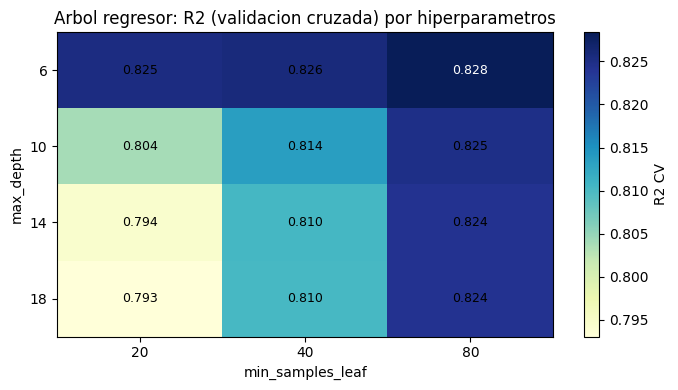

Mejor arbol por CV: max_depth=6, min_samples_leaf=80 (R2 CV=0.828)


In [84]:
# Busqueda de hiperparametros del ARBOL por validacion cruzada (sobre el train, sin mirar el test).
# Se compara una grilla max_depth x min_samples_leaf y se elige por mejor R2 promedio en 5 folds.
grid_depth = [6, 10, 14, 18]
grid_leaf = [20, 40, 80]
cv_arbol = pd.DataFrame(index=grid_depth, columns=grid_leaf, dtype=float)
for dep in grid_depth:
    for leaf in grid_leaf:
        modelo_cv = DecisionTreeRegressor(max_depth=dep, min_samples_leaf=leaf, random_state=42)
        cv_arbol.loc[dep, leaf] = cross_val_score(modelo_cv, X_train_reg, y_train_reg, cv=3, scoring='r2').mean()
pos_arbol = cv_arbol.stack().idxmax()
mejor_depth_reg = int(pos_arbol[0]); mejor_leaf_reg = int(pos_arbol[1])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cv_arbol.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(grid_leaf))); ax.set_xticklabels(grid_leaf)
ax.set_yticks(range(len(grid_depth))); ax.set_yticklabels(grid_depth)
ax.set_xlabel('min_samples_leaf'); ax.set_ylabel('max_depth')
ax.set_title('Arbol regresor: R2 (validacion cruzada) por hiperparametros')
vmax = np.nanmax(cv_arbol.values)
for (yy, xx), val in np.ndenumerate(cv_arbol.values):
    ax.text(xx, yy, f'{val:.3f}', ha='center', va='center', fontsize=9, color='white' if val > vmax*0.997 else 'black')
plt.colorbar(im, ax=ax, label='R2 CV'); plt.tight_layout(); plt.show()
print(f'Mejor arbol por CV: max_depth={mejor_depth_reg}, min_samples_leaf={mejor_leaf_reg} (R2 CV={cv_arbol.loc[mejor_depth_reg, mejor_leaf_reg]:.3f})')

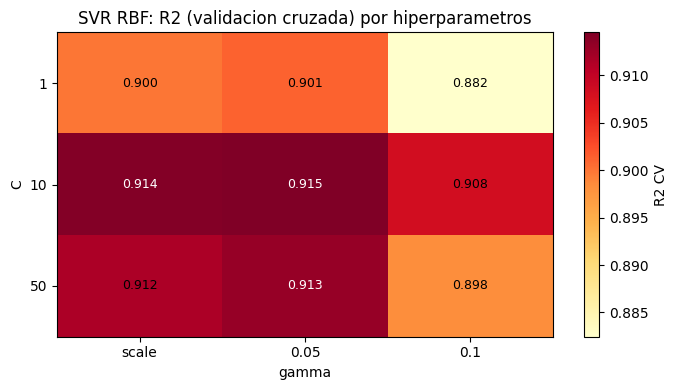

Mejor SVR por CV: C=10.0, gamma=0.05 (R2 CV=0.915)


In [85]:
# Busqueda de hiperparametros del SVR (C x gamma) por validacion cruzada sobre una muestra escalada del train.
rng_grid = np.random.RandomState(42)
idx_grid = rng_grid.choice(len(X_train_reg_esc), size=min(6000, len(X_train_reg_esc)), replace=False)
X_grid, y_grid = X_train_reg_esc.iloc[idx_grid], y_train_reg.iloc[idx_grid]
grid_C = [1, 10, 50]
grid_gamma = ['scale', 0.05, 0.1]
cv_svr = pd.DataFrame(index=grid_C, columns=[str(g) for g in grid_gamma], dtype=float)
for C in grid_C:
    for gam in grid_gamma:
        modelo_cv = SVR(kernel='rbf', C=C, epsilon=0.3, gamma=gam)
        cv_svr.loc[C, str(gam)] = cross_val_score(modelo_cv, X_grid, y_grid, cv=3, scoring='r2').mean()
pos_svr = cv_svr.stack().idxmax()
mejor_C = float(pos_svr[0])
mejor_gamma = pos_svr[1]
mejor_gamma_val = mejor_gamma if mejor_gamma in ('scale', 'auto') else float(mejor_gamma)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cv_svr.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(grid_gamma))); ax.set_xticklabels([str(g) for g in grid_gamma])
ax.set_yticks(range(len(grid_C))); ax.set_yticklabels(grid_C)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('SVR RBF: R2 (validacion cruzada) por hiperparametros')
vmax = np.nanmax(cv_svr.values)
for (yy, xx), val in np.ndenumerate(cv_svr.values):
    ax.text(xx, yy, f'{val:.3f}', ha='center', va='center', fontsize=9, color='white' if val > vmax*0.997 else 'black')
plt.colorbar(im, ax=ax, label='R2 CV'); plt.tight_layout(); plt.show()
print(f'Mejor SVR por CV: C={mejor_C}, gamma={mejor_gamma} (R2 CV={cv_svr.loc[mejor_C, str(mejor_gamma)]:.3f})')

### 4.1.3 Aplicacion de modelos

In [86]:
# Regresion de temperatura media diaria con los hiperparametros elegidos por validacion cruzada.
modelo_reg_lineal = LinearRegression(); modelo_reg_lineal.fit(X_train_reg, y_train_reg)
pred_reg_lineal = modelo_reg_lineal.predict(X_test_reg)

modelo_reg_arbol = DecisionTreeRegressor(max_depth=mejor_depth_reg, min_samples_leaf=mejor_leaf_reg, random_state=42)
modelo_reg_arbol.fit(X_train_reg, y_train_reg)
pred_reg_arbol = modelo_reg_arbol.predict(X_test_reg)

rng_muestra = np.random.RandomState(42)
idx_muestra_svr = rng_muestra.choice(len(X_train_reg_esc), size=min(12000, len(X_train_reg_esc)), replace=False)
modelo_reg_svm = SVR(kernel='rbf', C=mejor_C, epsilon=0.3, gamma=mejor_gamma_val)
modelo_reg_svm.fit(X_train_reg_esc.iloc[idx_muestra_svr], y_train_reg.iloc[idx_muestra_svr])
pred_reg_svm = modelo_reg_svm.predict(X_test_reg_esc)

predicciones_regresion = {'M1 Regresion lineal': pred_reg_lineal, 'M2 Arbol regresor': pred_reg_arbol, 'M3 SVR RBF': pred_reg_svm}
display(pd.DataFrame([{'modelo': n, 'pred_min': float(np.min(p)), 'pred_max': float(np.max(p))} for n, p in predicciones_regresion.items()]).round(2))

,modelo,pred_min,pred_max
0,M1 Regresion lineal,-14.48,27.54
1,M2 Arbol regresor,-7.37,23.69
2,M3 SVR RBF,-9.57,26.05


**Analisis del entrenamiento de regresion:**

Los tres modelos estiman la temperatura media diaria. Lineal y arbol usan la matriz sin escalar; el `SVR` la escalada (y una muestra). No se truncan las predicciones (la temperatura puede tomar cualquier valor). El rango de predicciones permite verificar que cubren el espectro termico real del pais.

#### 4.1.3.1 Visualizaciones del modelamiento de regresion

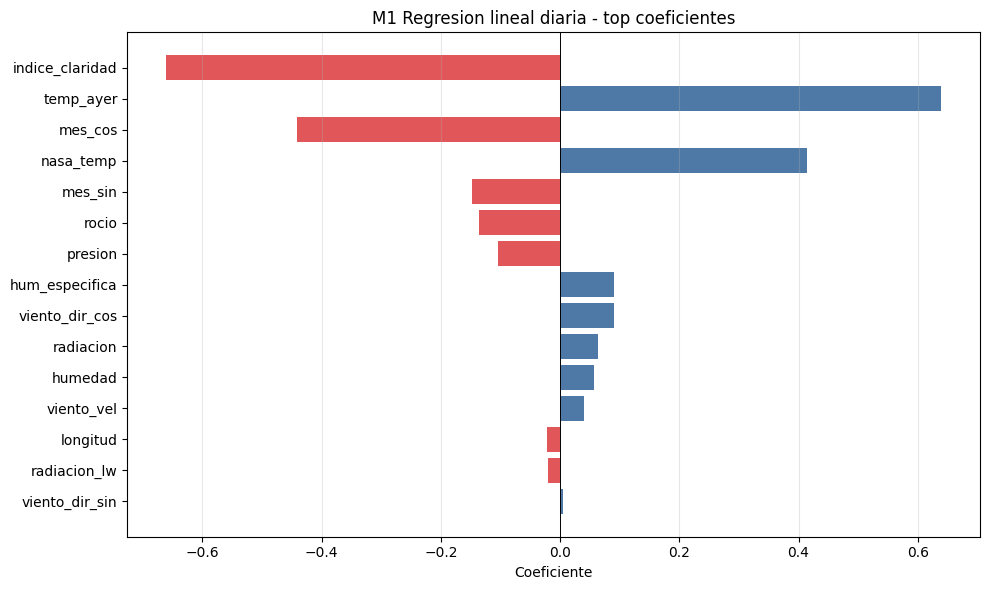

In [87]:
coeficientes_reg_lineal = pd.DataFrame({
    'variable': columnas_regresion,
    'coeficiente': modelo_reg_lineal.coef_,
    'abs_coef': np.abs(modelo_reg_lineal.coef_)
}).sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e15759' if v < 0 else '#4e79a7' for v in coeficientes_reg_lineal['coeficiente']]
ax.barh(coeficientes_reg_lineal['variable'][::-1], coeficientes_reg_lineal['coeficiente'][::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.7)
ax.set_title('M1 Regresion lineal diaria - top coeficientes')
ax.set_xlabel('Coeficiente')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de coeficientes M1:**

Los coeficientes muestran que variables como la latitud, la altura y la estacionalidad tienen el mayor peso direccional sobre la **temperatura media**: coeficientes positivos elevan la temperatura estimada y negativos la reducen. Es una primera lectura interpretable antes de los modelos no lineales (arbol y SVR).

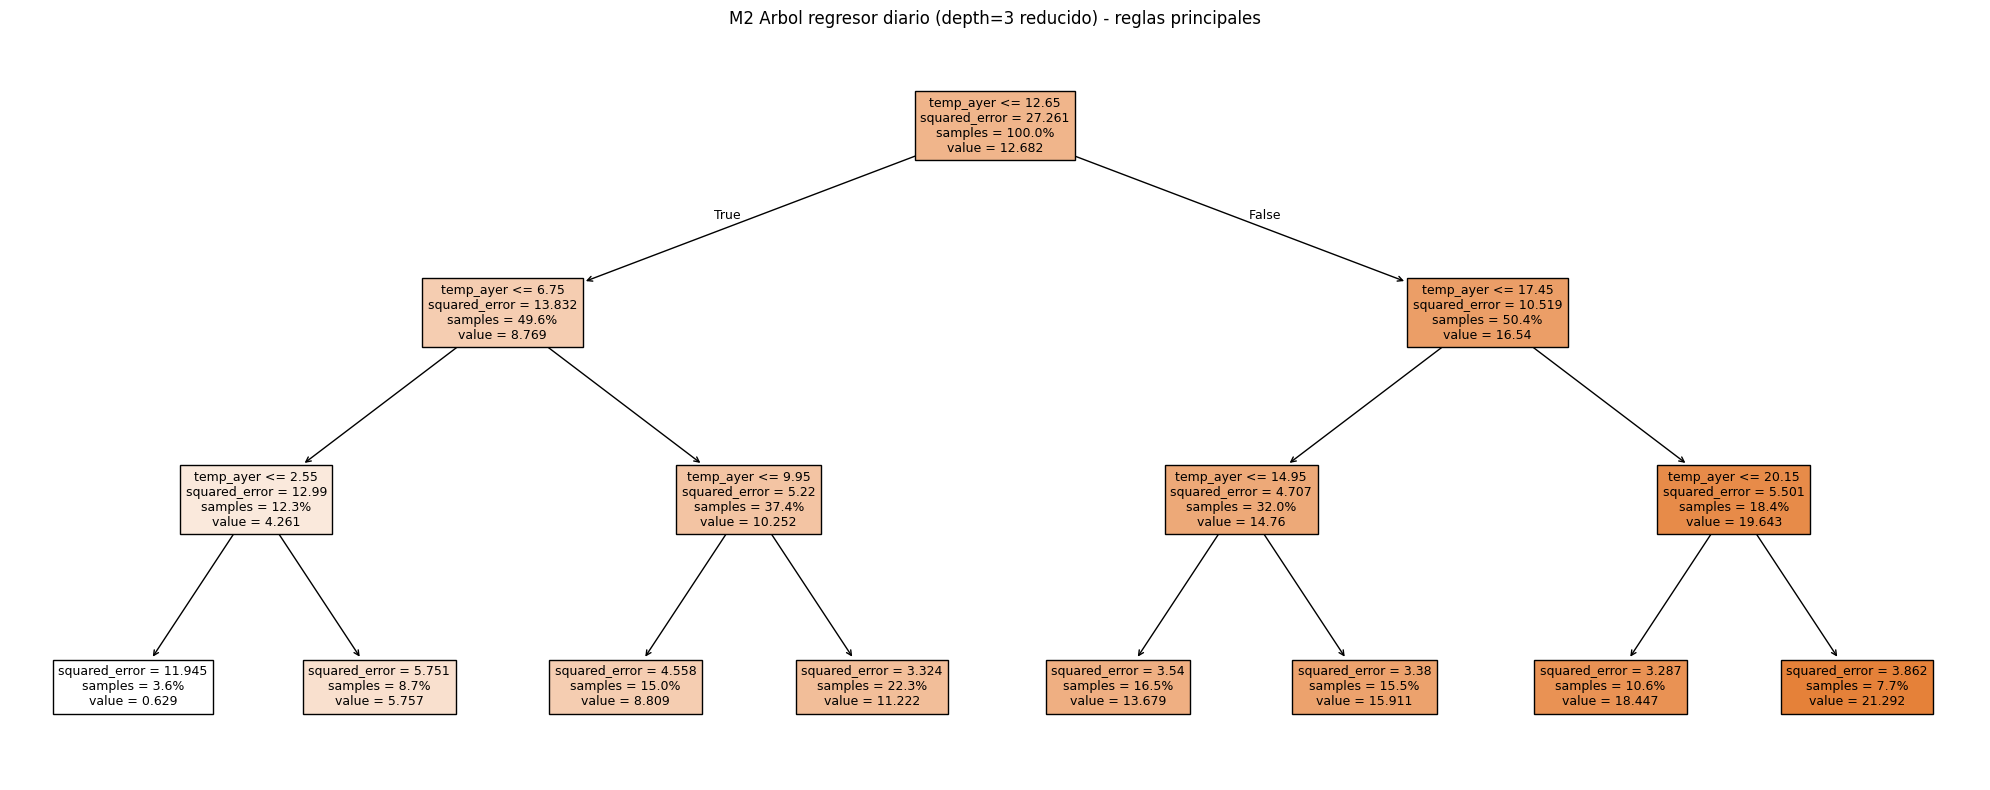

In [88]:
modelo_reg_arbol_visual = DecisionTreeRegressor(max_depth=3, min_samples_leaf=40, random_state=42)
modelo_reg_arbol_visual.fit(X_train_reg, y_train_reg)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(modelo_reg_arbol_visual, feature_names=columnas_regresion, label='all', proportion=True, filled=True, fontsize=9, ax=ax)
ax.set_title('M2 Arbol regresor diario (depth=3 reducido) - reglas principales')
plt.tight_layout(); plt.show()

**Analisis del arbol regresor:**

Se entrena un arbol con `max_depth=3` solo para visualizar las reglas dominantes (el arbol real usa la profundidad elegida por validacion cruzada). Los primeros cortes muestran las variables que mas separan zonas **calidas de frias** -latitud, altura y estacionalidad-, confirmando el aporte de las variables geograficas y temporales a la temperatura.

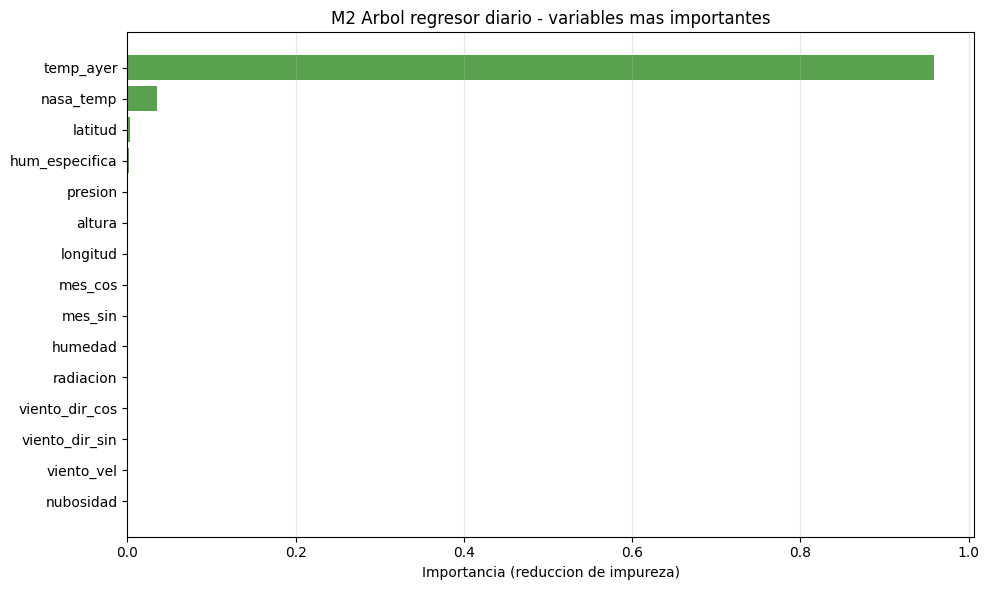

In [89]:
importancia_arbol_reg = pd.DataFrame({
    'variable': columnas_regresion,
    'importancia': modelo_reg_arbol.feature_importances_
}).sort_values('importancia', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancia_arbol_reg['variable'][::-1], importancia_arbol_reg['importancia'][::-1], color='#59a14f')
ax.set_title('M2 Arbol regresor diario - variables mas importantes')
ax.set_xlabel('Importancia (reduccion de impureza)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de importancia de variables:**

El arbol asigna importancia segun cuanto reduce la impureza al usar cada variable como nodo de decision. Dominan la ubicacion (latitud, longitud, altura) y la estacionalidad, junto con variables atmosfericas como la radiacion, lo que respalda la hipotesis H3 sobre el aporte de la ubicacion y el estado atmosferico a la **temperatura**.

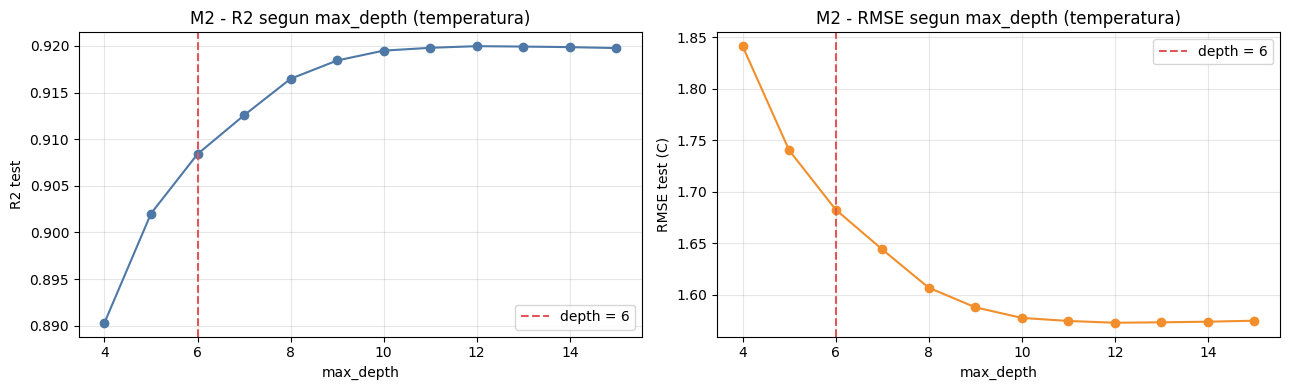

In [90]:
profundidades = range(4, 16)
performance_depth = []
for dprof in profundidades:
    mtmp = DecisionTreeRegressor(max_depth=dprof, min_samples_leaf=40, random_state=42).fit(X_train_reg, y_train_reg)
    pred_d = mtmp.predict(X_test_reg)
    performance_depth.append({'depth': dprof, 'R2': r2_score(y_test_reg, pred_d), 'RMSE': float(np.sqrt(mean_squared_error(y_test_reg, pred_d)))})
curva_depth = pd.DataFrame(performance_depth)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(curva_depth['depth'], curva_depth['R2'], marker='o', color='#4e79a7')
axes[0].axvline(mejor_depth_reg, color='#e15759', linestyle='--', label=f'depth = {mejor_depth_reg}')
axes[0].set_title('M2 - R2 segun max_depth (temperatura)'); axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('R2 test'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(curva_depth['depth'], curva_depth['RMSE'], marker='o', color='#f28e2b')
axes[1].axvline(mejor_depth_reg, color='#e15759', linestyle='--', label=f'depth = {mejor_depth_reg}')
axes[1].set_title('M2 - RMSE segun max_depth (temperatura)'); axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('RMSE test (C)'); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

**Analisis de la curva de profundidad:**

Se grafica el desempeno del arbol de temperatura para distintos `max_depth`. El `R2` sube y se estabiliza; la profundidad elegida por CV evita el sobreajuste manteniendo un `R2` alto y `RMSE` bajo (en grados C).

### 4.1.4 Obtencion de metricas

In [91]:
def metricas_regresion(nombre, y_real, y_pred):
    return {'modelo': nombre, 'MAE': mean_absolute_error(y_real, y_pred), 'RMSE': float(np.sqrt(mean_squared_error(y_real, y_pred))), 'R2': r2_score(y_real, y_pred)}

metricas_reg = pd.DataFrame([metricas_regresion(n, y_test_reg, p) for n, p in predicciones_regresion.items()])
display(metricas_reg.round(3))

,modelo,MAE,RMSE,R2
0,M1 Regresion lineal,1.156,1.593,0.918
1,M2 Arbol regresor,1.215,1.682,0.908
2,M3 SVR RBF,1.020,1.464,0.931


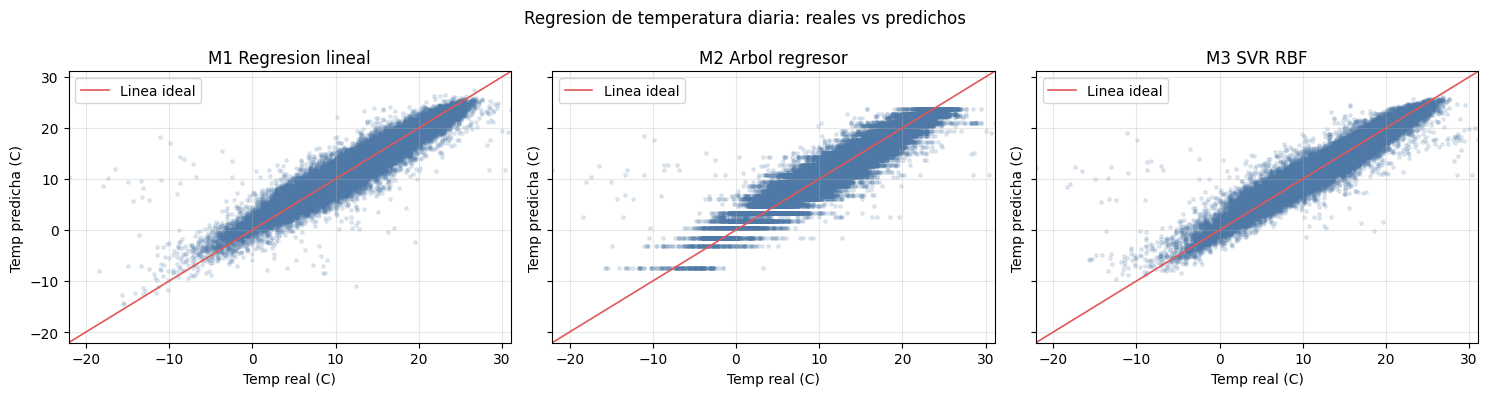

In [92]:
lo = float(min(y_test_reg.min(), min(p.min() for p in predicciones_regresion.values())))
hi = float(max(y_test_reg.max(), max(p.max() for p in predicciones_regresion.values())))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (nombre, pred) in zip(axes, predicciones_regresion.items()):
    ax.scatter(y_test_reg, pred, alpha=0.15, s=6, color='#4e79a7')
    ax.plot([lo, hi], [lo, hi], color='#e15759', linewidth=1.2, label='Linea ideal')
    ax.set_title(nombre); ax.set_xlabel('Temp real (C)'); ax.set_ylabel('Temp predicha (C)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.grid(alpha=0.3); ax.legend(loc='upper left')
fig.suptitle('Regresion de temperatura diaria: reales vs predichos')
plt.tight_layout(); plt.show()

**Analisis comparativo de regresion:**

Las metricas son sobre la temperatura media diaria del test (2024-2025). El `R2` es alto (>= 0.9): la temperatura depende de forma estable de la ubicacion, la estacionalidad y el estado atmosferico, todos disponibles en los datos. El `RMSE` queda en pocos grados C. El grafico reales vs predichos muestra una nube muy pegada a la diagonal. Esto contrasta con la precipitacion diaria (caotica, `R2`~0.4), que por eso se aborda como clasificacion: cada tecnica se aplica donde rinde.

## 4.2 Modelos de clasificacion

### 4.2.1 Seleccion de variables (X/Y)

### 4.2.2 Seleccion de parametros

### 4.2.3 Aplicacion de modelos

### 4.2.4 Obtencion de metricas

## 4.3 Modelos de Cluster

### 4.3.1 Seleccion de variables (X)

### 4.3.2 Seleccion de parametros

### 4.3.3 Aplicacion de modelos

### 4.3.4 Obtencion de metricas

# 5. Evaluacion

## 5.1 Metricas: matriz de confusion, R/R2, RMSE

In [93]:
# Resumen comparativo de regresion (mejor RMSE)
metricas_regresion_resumen = metricas_reg.copy()
metricas_regresion_resumen['rank_RMSE'] = metricas_regresion_resumen['RMSE'].rank(method='min').astype(int)
metricas_regresion_resumen = metricas_regresion_resumen.sort_values('RMSE')
display(metricas_regresion_resumen.round(3))
mejor_regresion = metricas_regresion_resumen.iloc[0]['modelo']
print(f'Mejor modelo de regresion: {mejor_regresion}')


,modelo,MAE,RMSE,R2,rank_RMSE
2,M3 SVR RBF,1.020,1.464,0.931,1
0,M1 Regresion lineal,1.156,1.593,0.918,2
1,M2 Arbol regresor,1.215,1.682,0.908,3


Mejor modelo de regresion: M3 SVR RBF


In [94]:
# === Aporte del dataset atmosferico a la regresion de temperatura diaria ===
base_geo = ['altura', 'latitud', 'longitud', 'mes_cos', 'mes_sin', 'temp_ayer']
arbol_base = DecisionTreeRegressor(max_depth=mejor_depth_reg, min_samples_leaf=40, random_state=42).fit(X_train_reg[base_geo], y_train_reg)
r2_base = r2_score(y_test_reg, arbol_base.predict(X_test_reg[base_geo]))
r2_full = max(r2_score(y_test_reg, p) for p in predicciones_regresion.values())
comparacion_atmosferico = pd.DataFrame([
    {'predictoras': 'Geo + estacionalidad + temp dia anterior', 'R2 temperatura': round(r2_base, 3)},
    {'predictoras': '+ dataset atmosferico (humedad, radiacion, nubosidad, etc.)', 'R2 temperatura': round(r2_full, 3)},
])
display(comparacion_atmosferico)
print(f'La temperatura diaria se predice muy bien (R2={r2_full:.3f}): depende de ubicacion, epoca del')
print(f'anio y estado atmosferico, todos disponibles. El dataset atmosferico aporta sobre la base geo.')
print('Contraste: la lluvia diaria es caotica (R2~0.4 techo) y por eso se modela como CLASIFICACION.')

,predictoras,R2 temperatura
0,Geo + estacionalidad + temp dia anterior,0.887
1,"+ dataset atmosferico (humedad, radiacion, nub...",0.931


La temperatura diaria se predice muy bien (R2=0.931): depende de ubicacion, epoca del
anio y estado atmosferico, todos disponibles. El dataset atmosferico aporta sobre la base geo.
Contraste: la lluvia diaria es caotica (R2~0.4 techo) y por eso se modela como CLASIFICACION.


**Analisis del aporte del dataset atmosferico (regresion de temperatura):**

La tabla compara la regresion de temperatura usando solo ubicacion, estacionalidad y persistencia (temp del dia anterior) frente a sumarle el dataset atmosferico. Las variables atmosfericas (humedad, radiacion, nubosidad, etc.) aportan sobre la base geografica y elevan el `R2` hasta ~0.9. La temperatura es predecible porque responde de forma estable a esas variables; la precipitacion diaria, en cambio, conserva un fuerte componente caotico y por eso se aborda como clasificacion. Asi el proyecto usa los dos datasets (DMC + reanalisis) de forma eficaz: temperatura por regresion y lluvia por clasificacion.

## 5.2 Mejoras del proceso o modelamiento

# 6. Deploy